# Análisis Lingüístico Computacional Forense
### Preprocesamiento, vectorización (TF-IDF y embeddings), similitud entre documentos, extracción de entidades y análisis de contenido por entidad

Este notebook está diseñado para ejecutarse en **Google Colab** y analiza un corpus de documentos
en **español** (PDF y Word) provenientes de un expediente judicial/penal, con fines **académicos** y
como insumo preliminar para un informe forense lingüístico.

**Objetivo del análisis (3 preguntas que responde este notebook):**
1. **¿Qué documentos se parecen entre sí y por qué?** (similitud TF-IDF vs. embeddings)
2. **¿Qué entidades (personas, organizaciones, lugares, fechas, radicados) aparecen en cada documento y con qué frecuencia?**
3. **¿Qué se dice de cada entidad en cada documento?** (contexto de cada mención, con una capa opcional
   y experimental de detección de posibles declaraciones)

**Flujo del análisis:**
1. Lectura de documentos (PDF y Word) y construcción del corpus.
2. Preprocesamiento lingüístico: normalización Unicode, segmentación en oraciones, tokenización y lematización.
3. Vectorización con **TF-IDF** — se mantiene únicamente como punto de comparación pedagógico y para
   extraer términos clave por documento (para eso es excelente: destaca palabras distintivas).
4. Vectorización con **embeddings semánticos** — se usa para todo el resto del análisis (similitud,
   identificación de "por qué" se parecen los documentos), porque capturan significado y no solo
   coincidencia léxica.
5. Matrices de similitud coseno documento-documento (TF-IDF y embeddings) + explicación del "por qué"
   de cada par cercano.
6. Extracción de entidades nombradas con spaCy (`es_core_news_lg`) + reglas complementarias para
   expresiones judiciales (radicados, despachos) + **consolidación de variantes** combinando
   coincidencia difusa (fuzzy matching) automática con un diccionario manual que siempre tiene prioridad.
7. Caracterización objetiva de cada documento (términos clave + entidades).
8. Tabla "qué se dice de cada persona" por documento (oración exacta y contexto).
9. Síntesis con LLM (Hugging Face, modelo *instruct*) de la caracterización de documentos
   y de la categorización semántica de personas en roles procesales. de contexto), con una capa opcional
   y explícitamente heurística de posibles declaraciones directas.
8. Exportación de **todo** a un único archivo Excel con varias hojas, listo como insumo del informe.

> **Nota metodológica sobre TF-IDF vs. embeddings:** TF-IDF mide coincidencia léxica exacta ponderada
> (dos documentos se parecen si comparten las mismas palabras). Es muy interpretable, pero ciego a la
> paráfrasis: una denuncia y una resolución de fiscalía que describen el mismo hecho con palabras
> distintas saldrán como "poco parecidas" aunque hablen de lo mismo. Los embeddings capturan significado:
> oraciones sin una sola palabra en común pueden tener un vector casi idéntico si dicen lo mismo. En un
> expediente judicial, donde el mismo hecho se repite en denuncia, testimonio, indagatoria y resolución
> con redacciones distintas, esto es justo lo que se necesita para identificar documentos "cercanos por
> contenido". El costo es que los embeddings pierden la interpretabilidad directa de TF-IDF ("se parecen
> por estos términos"): por eso, además del puntaje de similitud, este notebook calcula la similitud
> oración-por-oración entre cada par de documentos y muestra cuáles oraciones específicas explican el
> parecido — eso devuelve el "por qué" que TF-IDF da gratis pero los embeddings no.


## Paso 0 — Instalación de librerías

Instalamos únicamente lo necesario:
- `pdfplumber`: extracción de texto de PDF.
- `python-docx`: lectura de archivos `.docx`.
- `spacy` + modelo `es_core_news_lg` (el modelo **grande** en español, más preciso para NER que `md`):
  tokenización, lematización y reconocimiento de entidades.
- `sentence-transformers`: embeddings semánticos con un modelo liviano multilingüe.
- `rapidfuzz`: coincidencia difusa (fuzzy matching) para consolidar variantes de una misma entidad
  (ej. "Rio Frio" / "Río Frío", "Richard Kenedi" / "Richard Kenedi Mosquera").
- `scikit-learn`, `pandas`, `openpyxl`, `matplotlib`, `seaborn`: vectorización, Excel y visualización.
- `libreoffice` (vía apt): conversión de archivos `.doc` antiguos a `.docx`, solo si el corpus los incluye.

**Nota:** este notebook carga `es_core_news_lg` **una sola vez** (a diferencia de versiones anteriores
que cargaban el modelo tres veces con distintos tamaños). Todo el análisis de este notebook usa
consistentemente el modelo grande.


In [ ]:
# Instalación de librerías (puede tardar 1-2 minutos la primera vez)
!pip install -q pdfplumber python-docx sentence-transformers scikit-learn openpyxl seaborn spacy rapidfuzz pyLDAvis

# Modelo de spaCy en español, versión GRANDE (más preciso para NER que 'md')
!python -m spacy download es_core_news_lg -q

# LibreOffice, solo necesario si el corpus incluye archivos .doc antiguos (no .docx)
!apt-get install -y libreoffice --quiet > /dev/null 2>&1

# Reinstalación limpia de Pillow: evita un conflicto de versiones típico de Colab
# (error "cannot import name '_Ink' from 'PIL._typing'")
!pip install -q --force-reinstall --no-deps pillow

print("Instalación completa.")
print("AHORA: ve al menú 'Entorno de ejecución' > 'Reiniciar sesión', y luego continúa con la siguiente celda.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 625.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 23.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
I

In [ ]:
# --- Librerías estándar de Python ---
import os                      # manejo de rutas y archivos del sistema
import re                      # expresiones regulares (limpieza de texto y reglas judiciales)
import glob                    # listar archivos que cumplen un patrón (ej. *.pdf)
import zipfile                 # descomprimir el corpus si llega como .zip
import unicodedata             # normalización Unicode (acentos, formas NFC/NFKD)
import subprocess              # ejecutar LibreOffice desde Python (conversión .doc -> .docx)
from collections import Counter, defaultdict  # conteo de frecuencias y diccionarios con valor por defecto

# --- Librerías de análisis de datos y visualización ---
import numpy as np             # operaciones numéricas (vectores, matrices)
import pandas as pd            # tablas de datos (DataFrames): el formato central de este notebook
import matplotlib.pyplot as plt  # gráficos base
import seaborn as sns          # gráficos estadísticos (mapas de calor)

# --- Lectura de documentos ---
import pdfplumber              # extracción de texto de archivos PDF
import docx                    # python-docx: lectura de archivos .docx

# --- Procesamiento de lenguaje natural ---
import spacy                   # NLP en español: tokenización, lematización, NER
from rapidfuzz import fuzz     # coincidencia difusa para agrupar variantes de una misma entidad

# --- Vectorización y comparación ---
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # TF-IDF y conteo de n-gramas
from sklearn.metrics.pairwise import cosine_similarity  # similitud coseno entre vectores
from sklearn.decomposition import PCA  # reducción a 2D para graficar documentos
from sentence_transformers import SentenceTransformer  # modelo de embeddings semánticos

# Estilo visual de los gráficos (fondo blanco, limpio, apto para informes)
sns.set_theme(style="white")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 0.1 — Función auxiliar: tablas con estilo profesional

A partir de aquí, las tablas "para informe" se muestran con `mostrar_tabla(...)` en vez de
`display(df)` plano: encabezado oscuro, filas alternadas y barras de magnitud en las columnas
numéricas relevantes, para que se puedan capturar de pantalla directamente en un informe.

In [ ]:
# --- Estilo profesional para TODAS las gráficas del notebook a partir de aquí ---
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except (OSError, ValueError):
    plt.style.use("ggplot")  # respaldo si el nombre del estilo cambia entre versiones de matplotlib
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#cccccc",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.size": 10.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5, "legend.fontsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
})
PALETA_CATEGORICA = ["#2c3e50", "#2980b9", "#c0392b", "#27ae60", "#8e44ad", "#d35400", "#16a085", "#7f8c8d"]


def mostrar_tabla(df_tabla, titulo=None, columnas_barra=None, precision=2, ancho_max_col="320px"):
    """
    Muestra un DataFrame con formato profesional (encabezado oscuro, filas alternadas, barras de
    magnitud opcionales en columnas numéricas) en vez del display() plano por defecto de pandas.
    Se usa en todas las tablas "para informe" del notebook, para que el investigador pueda
    capturarlas de pantalla directamente.
    """
    if df_tabla is None or df_tabla.empty:
        print("(tabla vacía)")
        return None

    estilo = df_tabla.style
    if titulo:
        estilo = estilo.set_caption(titulo)

    estilo = estilo.set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "15px"), ("font-weight", "700"), ("text-align", "left"),
            ("padding", "8px 4px"), ("color", "#1b2631"),
        ]},
        {"selector": "th", "props": [
            ("background-color", "#1b2631"), ("color", "white"), ("text-align", "left"),
            ("padding", "7px 10px"), ("font-size", "12.5px"),
        ]},
        {"selector": "td", "props": [
            ("padding", "6px 10px"), ("font-size", "12.5px"), ("vertical-align", "top"),
            ("max-width", ancho_max_col), ("overflow-wrap", "break-word"),
        ]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f4f6f7")]},
        {"selector": "tr:hover", "props": [("background-color", "#eaf2f8")]},
    ]).set_properties(**{"border": "1px solid #e0e0e0"})

    columnas_numericas = df_tabla.select_dtypes(include="number").columns.tolist()
    if columnas_numericas:
        estilo = estilo.format(precision=precision, subset=columnas_numericas)

    if columnas_barra:
        columnas_barra_validas = [c for c in columnas_barra if c in df_tabla.columns]
        if columnas_barra_validas:
            estilo = estilo.bar(subset=columnas_barra_validas, color="#5dade2", vmin=0)

    try:
        estilo = estilo.hide(axis="index")
    except Exception:
        try:
            estilo = estilo.hide_index()
        except Exception:
            pass

    display(estilo)
    return estilo


## Paso 1 — Leer los documentos y construir el corpus (`df`)

Esta es la base de todo el notebook: un DataFrame `df` con una fila por documento y, como mínimo,
las columnas `archivo` (nombre del archivo) y `texto_crudo` (todo el texto extraído tal cual salió
del PDF o Word, sin limpiar todavía).

**Nota importante:** en la versión anterior de este notebook, esta celda de lectura no existía —
las celdas siguientes usaban `df` como si ya estuviera creado, pero nunca se generaba, así que el
notebook no podía ejecutarse de principio a fin. Esta versión corrige eso.

Ajusta `RUTA_ZIP` a la ruta real de tu archivo `.zip` subido a `/content`, o usa la celda de Google
Drive si prefieres montar tu unidad en vez de subir un zip.


In [ ]:
# --- Opción A: descomprimir un .zip subido directamente a /content (la que ya usabas) ---
RUTA_ZIP = "/content/Ejercicio1.zip"              # ruta del zip con los documentos del expediente
CARPETA_DOCUMENTOS = "/content/expediente_forense"  # carpeta destino donde quedará el corpus

with zipfile.ZipFile(RUTA_ZIP, "r") as zip_ref:   # abre el zip en modo lectura
    zip_ref.extractall(CARPETA_DOCUMENTOS)        # extrae todo su contenido a la carpeta destino

# Si el zip contiene una única subcarpeta interna (común al comprimir una carpeta desde el explorador
# de archivos), entramos en ella automáticamente para no tener que ajustar la ruta a mano
contenido = os.listdir(CARPETA_DOCUMENTOS)
if len(contenido) == 1 and os.path.isdir(os.path.join(CARPETA_DOCUMENTOS, contenido[0])):
    CARPETA_DOCUMENTOS = os.path.join(CARPETA_DOCUMENTOS, contenido[0])

archivos = glob.glob(os.path.join(CARPETA_DOCUMENTOS, "*"))  # lista de rutas de todos los archivos
print(f"Se encontraron {len(archivos)} archivos en la carpeta:")
for a in archivos:
    print(" -", os.path.basename(a))  # muestra solo el nombre, no la ruta completa


Se encontraron 13 archivos en la carpeta:
 - Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx
 - D. Anexo 4.  PROGRAMA METODOLOGICO.docx
 - Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx
 - I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de  infraestructura Rio Frio.pdf
 - M. Anexo 13. Estudio previo y de necesidad.pdf
 - Z21. Anexo 47. Respuesta celulares CLICK S.A .docx
 - Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx
 - Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf
 - F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf
 - Z41. Anexo 67. FPJ-34-ARRAIGO-Richard Kenedi Mosquera.doc
 - C. Anexo 3. Informe hallazgos Contraloria.pdf
 - A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf
 - B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx


In [ ]:
def convertir_doc_a_docx(ruta_doc, carpeta_salida, intentos=2, tiempo_limite=300):
    """
    Convierte un archivo .doc (formato antiguo de Word) a .docx usando LibreOffice en modo headless.
    Solo se necesita si el corpus incluye archivos .doc (no .docx). Se reintenta porque en Colab la
    primera ejecución de LibreOffice en la sesión suele tardar en inicializar su perfil de usuario.
    """
    nombre_base = os.path.splitext(os.path.basename(ruta_doc))[0]        # nombre sin extensión
    ruta_convertida = os.path.join(carpeta_salida, nombre_base + ".docx")  # ruta esperada de salida

    for intento in range(1, intentos + 1):                # hasta 'intentos' reintentos
        perfil_temporal = f"/tmp/lo_profile_{os.getpid()}_{intento}"  # perfil aislado por intento (evita locks)
        comando = [
            "soffice", "--headless", "--norestore",        # modo sin interfaz gráfica
            f"-env:UserInstallation=file://{perfil_temporal}",  # perfil de usuario propio
            "--convert-to", "docx", "--outdir", carpeta_salida, ruta_doc,
        ]
        try:
            resultado = subprocess.run(                     # ejecuta LibreOffice como proceso externo
                comando, capture_output=True, text=True, timeout=tiempo_limite
            )
            if os.path.exists(ruta_convertida):             # si el archivo de salida se generó, éxito
                return ruta_convertida
            print(f"  [AVISO] Intento {intento}: LibreOffice no generó el archivo esperado.")
            if resultado.stderr:
                print(f"    Detalle: {resultado.stderr.strip()[:300]}")
        except subprocess.TimeoutExpired:
            print(f"  [AVISO] Intento {intento}: se superó el tiempo límite ({tiempo_limite}s).")
        except Exception as e:
            print(f"  [AVISO] Intento {intento}: error inesperado: {e}")
    return None  # si ningún intento funcionó, se informa que la conversión falló


def leer_pdf(ruta_pdf):
    """Extrae todo el texto de un PDF, página por página, y lo une con saltos de línea."""
    texto_paginas = []                            # aquí acumulamos el texto de cada página
    with pdfplumber.open(ruta_pdf) as pdf:         # abre el PDF
        for pagina in pdf.pages:                   # recorre cada página
            texto = pagina.extract_text()          # intenta extraer el texto de la página
            texto_paginas.append(texto if texto else "")  # si no hay texto (ej. página escaneada), deja vacío
    return "\n".join(texto_paginas)                # une todas las páginas en un solo string


def leer_docx(ruta_docx):
    """Extrae todo el texto de un .docx, párrafo por párrafo (incluye texto de tablas)."""
    documento = docx.Document(ruta_docx)           # abre el documento Word
    partes = [p.text for p in documento.paragraphs]  # texto de cada párrafo normal
    for tabla in documento.tables:                 # además, recorre las tablas del documento
        for fila in tabla.rows:
            for celda in fila.cells:
                if celda.text.strip():
                    partes.append(celda.text)       # añade el texto de cada celda no vacía
    return "\n".join(partes)                        # une todo en un solo string


def leer_documento(ruta_archivo, carpeta_temporal):
    """
    Punto de entrada único: detecta la extensión del archivo y llama al lector correspondiente.
    Los .doc antiguos se convierten a .docx primero. Devuelve None si el formato no es soportado
    o si la lectura falla (para poder reportarlo sin detener todo el corpus).
    """
    extension = os.path.splitext(ruta_archivo)[1].lower()  # extensión en minúsculas, ej. '.pdf'
    try:
        if extension == ".pdf":
            return leer_pdf(ruta_archivo)
        elif extension == ".docx":
            return leer_docx(ruta_archivo)
        elif extension == ".doc":
            ruta_docx = convertir_doc_a_docx(ruta_archivo, carpeta_temporal)  # convierte primero
            return leer_docx(ruta_docx) if ruta_docx else None
        else:
            return None  # extensión no soportada (ej. .txt, .jpg): se ignora y se reporta después
    except Exception as e:
        print(f"  [ERROR] No se pudo leer {os.path.basename(ruta_archivo)}: {e}")
        return None

print("Funciones de lectura de documentos definidas: leer_pdf, leer_docx, leer_documento.")


def contar_paginas_pdf(ruta_pdf):
    """Cuenta las páginas de un PDF. Para .docx no existe el concepto de 'página' en el archivo
    (depende de cómo se renderice al imprimir), así que esa columna queda vacía (NaN) para Word."""
    try:
        with pdfplumber.open(ruta_pdf) as pdf:
            return len(pdf.pages)
    except Exception:
        return None


Funciones de lectura de documentos definidas: leer_pdf, leer_docx, leer_documento.


In [ ]:
# --- Construcción del corpus: se recorre cada archivo, se lee y se arma el DataFrame ---
filas_corpus = []                                  # lista temporal de diccionarios {archivo, texto_crudo}
archivos_no_leidos = []                            # para reportar al final qué archivos fallaron

for ruta in archivos:                              # 'archivos' viene de la celda anterior (glob)
    if os.path.isdir(ruta):                         # si es una subcarpeta, se ignora (no un documento)
        continue
    texto = leer_documento(ruta, CARPETA_DOCUMENTOS)
    if texto and texto.strip():                     # solo se agrega si se extrajo texto no vacío
        extension = os.path.splitext(ruta)[1].lower()
        n_paginas = contar_paginas_pdf(ruta) if extension == ".pdf" else None
        filas_corpus.append({
            "archivo": os.path.basename(ruta),
            "texto_crudo": texto,
            "n_paginas": n_paginas,  # None para .docx: el concepto de "página" no existe en el archivo
        })
    else:
        archivos_no_leidos.append(os.path.basename(ruta))

df = pd.DataFrame(filas_corpus)                     # DataFrame base: una fila por documento

print(f"Documentos leídos correctamente: {len(df)}")
if archivos_no_leidos:
    print(f"Archivos NO leídos o vacíos ({len(archivos_no_leidos)}) — revisar si son escaneados sin OCR "
          f"o de un formato no soportado:")
    for nombre in archivos_no_leidos:
        print("  -", nombre)

# --- Control de calidad básico: tamaño de cada documento, para detectar extracciones sospechosas ---
df["n_caracteres_crudo"] = df["texto_crudo"].apply(len)
df["n_palabras_crudo"] = df["texto_crudo"].apply(lambda t: len(t.split()))
print("\nControl de calidad de la extracción (documentos muy cortos pueden indicar un PDF escaneado sin OCR):")
display(df[["archivo", "n_paginas", "n_palabras_crudo", "n_caracteres_crudo"]].sort_values("n_caracteres_crudo"))


  [AVISO] Intento 1: error inesperado: [Errno 2] No such file or directory: 'soffice'
  [AVISO] Intento 2: error inesperado: [Errno 2] No such file or directory: 'soffice'
Documentos leídos correctamente: 12
Archivos NO leídos o vacíos (1) — revisar si son escaneados sin OCR o de un formato no soportado:
  - Z41. Anexo 67. FPJ-34-ARRAIGO-Richard Kenedi Mosquera.doc

Control de calidad de la extracción (documentos muy cortos pueden indicar un PDF escaneado sin OCR):


,archivo,n_paginas,n_palabras_crudo,n_caracteres_crudo
6,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,NaN,84,554
2,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...,NaN,84,568
0,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...,NaN,99,766
8,F. Anexo 6. Acta de posesion del secretario de...,1.0,235,1491
10,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,2.0,712,4115
7,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,6.0,846,5038
3,I. Anexo 9. Manual especifico de funciones y c...,2.0,839,5637
1,D. Anexo 4. PROGRAMA METODOLOGICO.docx,NaN,1223,8588
4,M. Anexo 13. Estudio previo y de necesidad.pdf,6.0,2227,14094
9,C. Anexo 3. Informe hallazgos Contraloria.pdf,9.0,2455,15858


### 1.1 — Estadísticas descriptivas del corpus

Estadísticas descriptivas de la longitud de los documentos (n_caracteres_crudo):


,n_caracteres_crudo
count,12.000000
mean,13109.583333
std,21605.942206
min,554.000000
25%,1309.750000
50%,5337.500000
75%,14535.000000
max,78008.000000


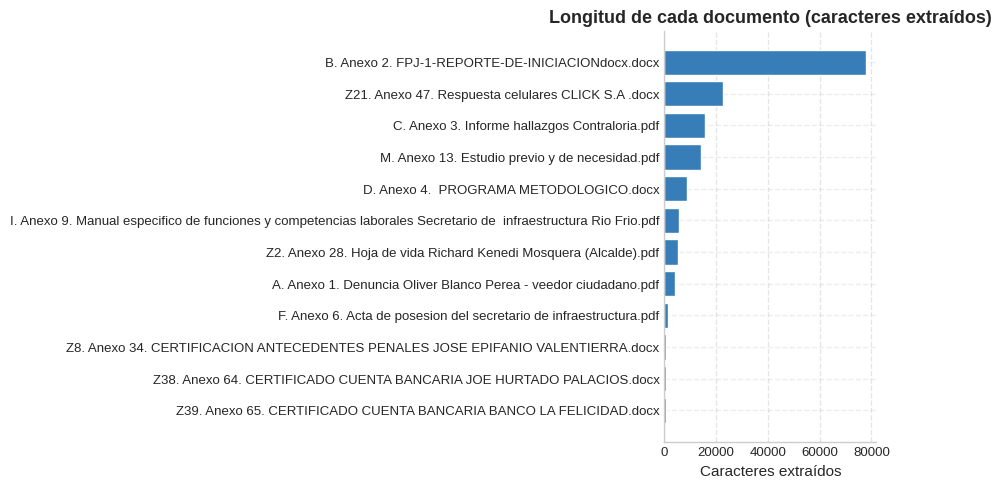

In [ ]:
print("Estadísticas descriptivas de la longitud de los documentos (n_caracteres_crudo):")
display(df["n_caracteres_crudo"].describe().to_frame("n_caracteres_crudo"))

fig, ax = plt.subplots(figsize=(9, 5))
orden = df.sort_values("n_caracteres_crudo")
ax.barh(orden["archivo"], orden["n_caracteres_crudo"], color="#377eb8")
ax.set_xlabel("Caracteres extraídos")
ax.set_title("Longitud de cada documento (caracteres extraídos)")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()


## Paso 2 — Preprocesamiento lingüístico

Procesamos el texto en etapas separadas y visibles, cada una en su propia celda, para poder
inspeccionar el resultado antes de pasar a la siguiente:

1. **Normalización Unicode** (forma NFC) + limpieza básica de artefactos de extracción.
2. **Segmentación en oraciones** (necesaria para extraer entidades y frases con contexto).
3. **Tokenización** (dividir cada oración en palabras, números, signos de puntuación).
4. **Lematización**, en dos versiones:
   - **con stopwords** (para embeddings, que se benefician del contexto completo de la oración)
   - **sin stopwords/puntuación** (para TF-IDF y conteo de frases frecuentes, donde solo interesan
     las palabras con carga semántica)

Usamos spaCy (`es_core_news_lg`) como motor lingüístico para los pasos 2 a 4.


In [ ]:
nlp = spacy.load("es_core_news_lg")   # se carga UNA sola vez en todo el notebook
print("Modelo de spaCy cargado: es_core_news_lg")


Modelo de spaCy cargado: es_core_news_lg


In [ ]:
def normalizar_unicode(texto):
    """Normaliza a forma NFC y limpia artefactos comunes de extracción de PDF/Word."""
    texto = unicodedata.normalize("NFC", texto)     # unifica caracteres acentuados a una sola representación
    texto = texto.replace("\r", "\n")               # unifica saltos de línea de Windows a estilo Unix
    texto = re.sub(r"-\n", "", texto)                # une palabras cortadas por guion al final de línea
    texto = re.sub(r"[ \t]+", " ", texto)            # colapsa espacios/tabs múltiples en uno solo
    texto = re.sub(r"\n{2,}", "\n", texto)           # colapsa saltos de línea repetidos en uno solo
    return texto.strip()                             # quita espacios/saltos al inicio y final


df["texto_normalizado"] = df["texto_crudo"].apply(normalizar_unicode)  # aplica a cada documento

print("Normalización completa. Ejemplo (documento 0), antes y después:\n")
print("--- ANTES (texto_crudo, primeros 300 caracteres) ---")
print(df["texto_crudo"].iloc[0][:300])
print("\n--- DESPUÉS (texto_normalizado, primeros 300 caracteres) ---")
print(df["texto_normalizado"].iloc[0][:300])


Normalización completa. Ejemplo (documento 0), antes y después:

--- ANTES (texto_crudo, primeros 300 caracteres) ---
CERTIFICACIÓN DE ANTECEDENTES PENALES
DOCUMENTO FICTICIO – USO ACADÉMICO
SIN VALIDEZ LEGAL
La POLICIA NACIONAL certifica que, revisados los registros penales, la persona identificada a continuación presenta la información que se relaciona para efectos de ejercicio académico:
Nombre: JOSE EPIFANIO VA

--- DESPUÉS (texto_normalizado, primeros 300 caracteres) ---
CERTIFICACIÓN DE ANTECEDENTES PENALES
DOCUMENTO FICTICIO – USO ACADÉMICO
SIN VALIDEZ LEGAL
La POLICIA NACIONAL certifica que, revisados los registros penales, la persona identificada a continuación presenta la información que se relaciona para efectos de ejercicio académico:
Nombre: JOSE EPIFANIO VA


In [ ]:
def segmentar_oraciones(texto, nlp_model):
    """Segmenta el texto en oraciones utilizando el segmentador de spaCy."""
    doc = nlp_model(texto)                                     # procesa el texto completo con spaCy
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]  # descarta oraciones vacías


df["oraciones"] = df["texto_normalizado"].apply(lambda t: segmentar_oraciones(t, nlp))  # lista de oraciones
df["n_oraciones"] = df["oraciones"].apply(len)                 # cuántas oraciones tiene cada documento

print("Segmentación en oraciones completa. Ejemplo (documento 0), primeras 3 oraciones:\n")
for oracion in df["oraciones"].iloc[0][:3]:
    print(" -", oracion)

print("\nConteo de oraciones por documento:")
display(df[["archivo", "n_oraciones"]])


Segmentación en oraciones completa. Ejemplo (documento 0), primeras 3 oraciones:

 - CERTIFICACIÓN DE ANTECEDENTES PENALES
DOCUMENTO
 - FICTICIO – USO ACADÉMICO
SIN VALIDEZ LEGAL
La POLICIA NACIONAL certifica que, revisados los registros penales, la persona identificada a continuación presenta la información que se relaciona para efectos de ejercicio académico:
Nombre: JOSE EPIFANIO VALENTIERRA ASPRILLA
Documento de identidad: Cédula de ciudadanía No.
 - 1.001.311.120 (dato ficticio)
Nacionalidad: colombiano
Resultado de la consulta (simulada)
NO REGISTRA ANTECEDENTES PENALES:
En los sistemas de consulta académica simulada, a la fecha de expedición de la presente certificación.

Conteo de oraciones por documento:


,archivo,n_oraciones
0,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...,5
1,D. Anexo 4. PROGRAMA METODOLOGICO.docx,36
2,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...,4
3,I. Anexo 9. Manual especifico de funciones y c...,39
4,M. Anexo 13. Estudio previo y de necesidad.pdf,72
5,Z21. Anexo 47. Respuesta celulares CLICK S.A ....,60
6,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,4
7,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,42
8,F. Anexo 6. Acta de posesion del secretario de...,10
9,C. Anexo 3. Informe hallazgos Contraloria.pdf,103


In [ ]:
def tokenizar(texto, nlp_model):
    """Tokeniza el texto completo con spaCy y devuelve la lista de tokens (excluyendo espacios puros)."""
    doc = nlp_model(texto)
    return [tok.text for tok in doc if not tok.is_space]  # se descartan tokens que son solo espacio


df["tokens"] = df["texto_normalizado"].apply(lambda t: tokenizar(t, nlp))
df["n_tokens"] = df["tokens"].apply(len)

print("Tokenización completa. Ejemplo (documento 0), primeros 25 tokens:\n")
print(df["tokens"].iloc[0][:25])


Tokenización completa. Ejemplo (documento 0), primeros 25 tokens:

['CERTIFICACIÓN', 'DE', 'ANTECEDENTES', 'PENALES', 'DOCUMENTO', 'FICTICIO', '–', 'USO', 'ACADÉMICO', 'SIN', 'VALIDEZ', 'LEGAL', 'La', 'POLICIA', 'NACIONAL', 'certifica', 'que', ',', 'revisados', 'los', 'registros', 'penales', ',', 'la', 'persona']


In [ ]:
def lematizar(texto, nlp_model):
    """
    Lematiza el texto con spaCy y devuelve dos versiones:
    - lemas_con_stopwords: todos los lemas en minúscula (para embeddings, que usan el contexto completo)
    - lemas_sin_stopwords: solo lemas de palabras alfabéticas, sin stopwords ni puntuación
      (para TF-IDF y conteo de frases frecuentes, donde solo interesan palabras con carga semántica)
    """
    doc = nlp_model(texto)
    lemas_con_stopwords = " ".join(
        tok.lemma_.lower() for tok in doc if not tok.is_space
    )
    lemas_sin_stopwords = " ".join(
        tok.lemma_.lower() for tok in doc
        if not tok.is_stop and not tok.is_punct and not tok.is_space and tok.is_alpha
    )
    return lemas_con_stopwords, lemas_sin_stopwords


resultados_lematizacion = df["texto_normalizado"].apply(lambda t: lematizar(t, nlp))  # tupla por documento
df["texto_lematizado_completo"] = resultados_lematizacion.apply(lambda x: x[0])       # para embeddings/contexto
df["texto_lematizado_sin_stopwords"] = resultados_lematizacion.apply(lambda x: x[1])  # para TF-IDF
df["n_lemas_sin_stopwords"] = df["texto_lematizado_sin_stopwords"].apply(lambda t: len(t.split()) if t else 0)

print("Lematización completa. Ejemplo (documento 0):\n")
print("--- Lemas con stopwords (primeras 15 palabras) ---")
print(df["texto_lematizado_completo"].iloc[0].split()[:15])
print("\n--- Lemas sin stopwords/puntuación (primeras 15 palabras) ---")
print(df["texto_lematizado_sin_stopwords"].iloc[0].split()[:15])

print("\nResumen del preprocesamiento por documento:")
display(df[["archivo", "n_oraciones", "n_tokens", "n_lemas_sin_stopwords"]])


Lematización completa. Ejemplo (documento 0):

--- Lemas con stopwords (primeras 15 palabras) ---
['certificación', 'de', 'antecedente', 'penal', 'documento', 'ficticio', '–', 'uso', 'académico', 'sin', 'validez', 'legal', 'el', 'policia', 'nacional']

--- Lemas sin stopwords/puntuación (primeras 15 palabras) ---
['certificación', 'antecedente', 'penal', 'documento', 'ficticio', 'académico', 'validez', 'legal', 'policia', 'nacional', 'certificar', 'revisar', 'registro', 'penal', 'persona']

Resumen del preprocesamiento por documento:


,archivo,n_oraciones,n_tokens,n_lemas_sin_stopwords
0,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...,5,118,66
1,D. Anexo 4. PROGRAMA METODOLOGICO.docx,36,1326,702
2,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...,4,93,43
3,I. Anexo 9. Manual especifico de funciones y c...,39,949,402
4,M. Anexo 13. Estudio previo y de necesidad.pdf,72,2451,1042
5,Z21. Anexo 47. Respuesta celulares CLICK S.A ....,60,2732,933
6,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,4,94,40
7,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,42,940,460
8,F. Anexo 6. Acta de posesion del secretario de...,10,256,114
9,C. Anexo 3. Informe hallazgos Contraloria.pdf,103,2773,1300


### 2.1 — Estadísticas del preprocesamiento

Estadísticas descriptivas del preprocesamiento:


,n_oraciones,n_tokens,n_lemas_sin_stopwords
count,12.000000,12.000000,12.000000
mean,59.666667,2185.166667,961.250000
std,89.397309,3769.881065,1682.766452
min,4.000000,93.000000,40.000000
25%,8.750000,221.500000,102.000000
50%,37.500000,944.500000,431.000000
75%,63.000000,2521.250000,960.250000
max,326.000000,13720.000000,6133.000000


/tmp/ipykernel_1793/593876052.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


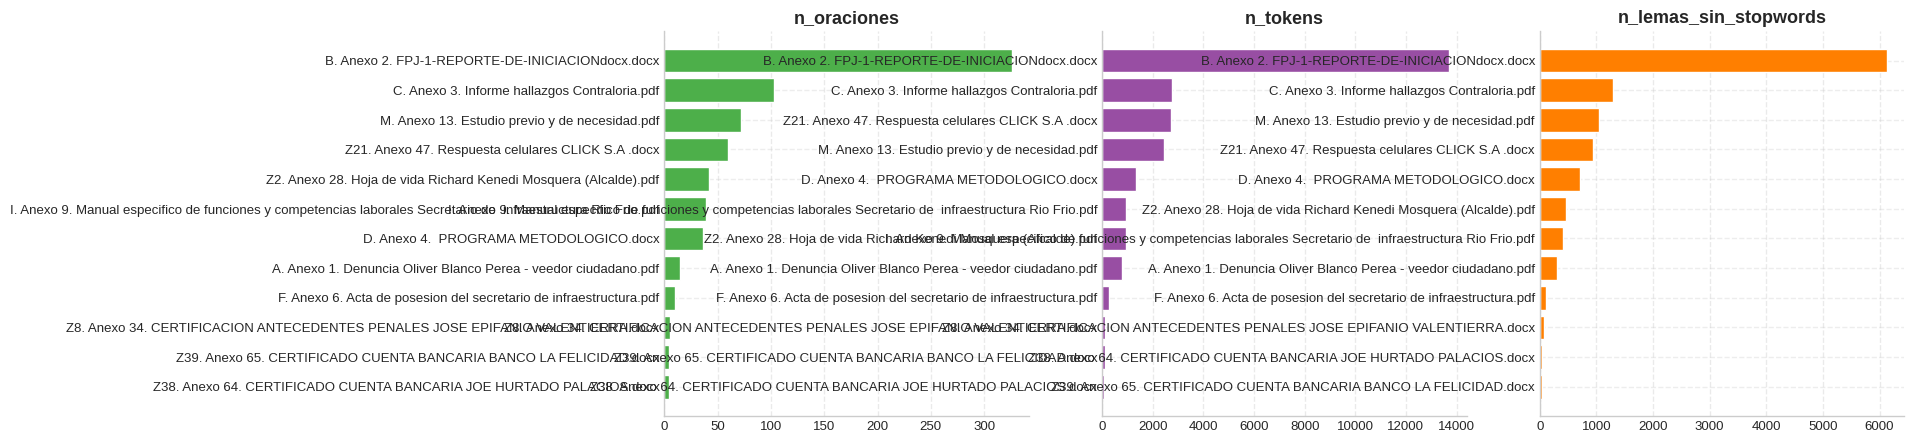

In [ ]:
columnas_stats = ["n_oraciones", "n_tokens", "n_lemas_sin_stopwords"]
print("Estadísticas descriptivas del preprocesamiento:")
display(df[columnas_stats].describe())

fig, ejes = plt.subplots(1, 3, figsize=(16, 5))
for eje, col, color in zip(ejes, columnas_stats, ["#4daf4a", "#984ea3", "#ff7f00"]):
    orden = df.sort_values(col)
    eje.barh(orden["archivo"], orden[col], color=color)
    eje.set_title(col)
    eje.grid(True, axis="x", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


## Paso 3 — TF-IDF (se mantiene como comparación y para extraer términos clave por documento)

Como se explicó en la introducción, TF-IDF se conserva aquí con dos propósitos concretos:
1. Servir de **punto de comparación** frente a los embeddings (Paso 5), para mostrar en el informe
   qué gana y qué pierde cada método.
2. Extraer los **términos más distintivos de cada documento** (Paso 7): para eso TF-IDF es
   apropiado, porque su definición matemática es justamente premiar palabras frecuentes en un
   documento pero raras en el resto del corpus — ideal para "qué hace único a este documento".

A partir de aquí, TF-IDF **no** se vuelve a usar para medir similitud entre documentos ni para
extracción de entidades: esas tareas se hacen con embeddings (Paso 5 en adelante).


In [ ]:
# max_features limita el vocabulario a los términos más relevantes (evita una matriz demasiado dispersa)
vectorizador_tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 1))
matriz_tfidf = vectorizador_tfidf.fit_transform(df["texto_lematizado_sin_stopwords"])  # usa lemas sin stopwords
terminos_tfidf = vectorizador_tfidf.get_feature_names_out()  # vocabulario final (nombres de columnas)

print(f"Matriz TF-IDF: {matriz_tfidf.shape[0]} documentos x {matriz_tfidf.shape[1]} términos")

df_tfidf_denso = pd.DataFrame(matriz_tfidf.todense(), columns=terminos_tfidf, index=df["archivo"])
print("\nVista previa de la matriz TF-IDF (documentos x términos):")
display(df_tfidf_denso.head())


Matriz TF-IDF: 12 documentos x 300 términos

Vista previa de la matriz TF-IDF (documentos x términos):


,acta,actividad,actual,adjudicar,administración,adulto,aifit,alcalde,alcaldía,alimentación,...,veedor,venir,verificar,vida,vigencia,voto,vínculo,área,él,étnico
archivo,,,,,,,,,,,,,,,,,,,,,
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.157425,0.000000,0.0
D. Anexo 4. PROGRAMA METODOLOGICO.docx,0.043111,0.047543,0.017656,0.000000,0.028740,0.0,0.035312,0.108349,0.079239,0.0,...,0.017656,0.0,0.000000,0.028740,0.000000,0.017656,0.0,0.026242,0.014370,0.0
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,0.175344,0.077349,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.390218,0.000000,0.000000,0.000000,0.0,0.064040,0.035069,0.0
M. Anexo 13. Estudio previo y de necesidad.pdf,0.042440,0.031203,0.000000,0.019677,0.014147,0.0,0.000000,0.011852,0.015601,0.0,...,0.000000,0.0,0.000000,0.028293,0.137737,0.000000,0.0,0.000000,0.070733,0.0


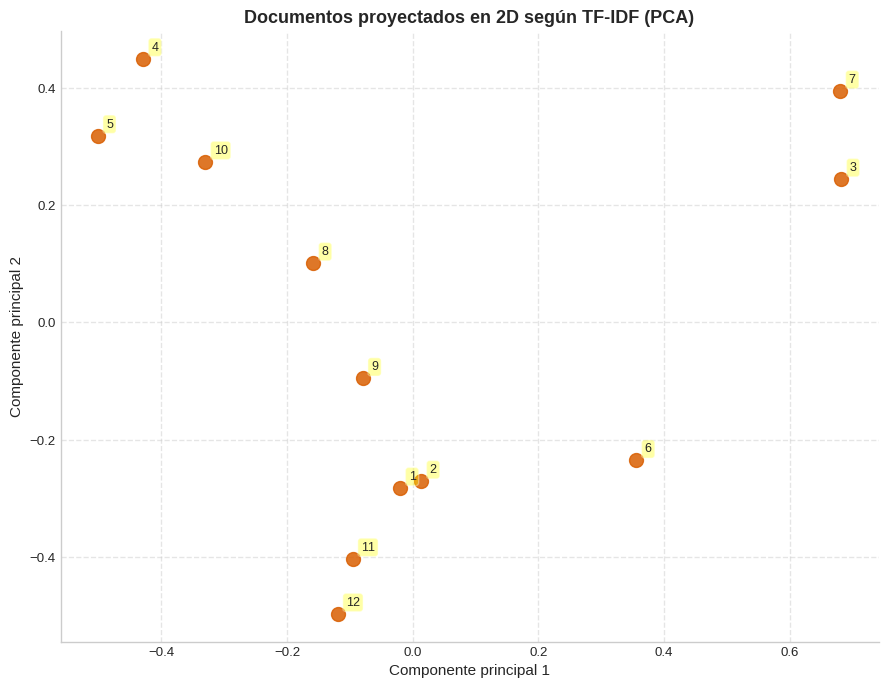


Tabla de identificación de documentos:


,Número en el gráfico,Documento
0,1,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...
1,2,D. Anexo 4. PROGRAMA METODOLOGICO.docx
2,3,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...
3,4,I. Anexo 9. Manual especifico de funciones y c...
4,5,M. Anexo 13. Estudio previo y de necesidad.pdf
5,6,Z21. Anexo 47. Respuesta celulares CLICK S.A ....
6,7,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...
7,8,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...
8,9,F. Anexo 6. Acta de posesion del secretario de...
9,10,C. Anexo 3. Informe hallazgos Contraloria.pdf


In [ ]:
# --- Proyección 2D de los documentos según TF-IDF, solo para visualizar la dispersión léxica ---
pca_tfidf = PCA(n_components=2, random_state=42)
coords_tfidf_2d = pca_tfidf.fit_transform(matriz_tfidf.toarray())

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_tfidf_2d[:, 0], coords_tfidf_2d[:, 1], s=100, color="#d95f02", alpha=0.85)
for i in range(len(df)):
    ax.annotate(str(i + 1), (coords_tfidf_2d[i, 0], coords_tfidf_2d[i, 1]),
                fontsize=9, xytext=(6, 6), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.25", fc="yellow", alpha=0.35))
ax.set_title("Documentos proyectados en 2D según TF-IDF (PCA)", fontsize=13)
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

tabla_id_documentos = pd.DataFrame({"Número en el gráfico": range(1, len(df) + 1), "Documento": df["archivo"]})
print("\nTabla de identificación de documentos:")
display(tabla_id_documentos)


### 3.1 — Términos más distintivos por documento (TF-IDF)

Estos términos son la base objetiva (no generada por LLM) que se usará más adelante en el
Paso 7 para caracterizar de qué habla cada documento.

In [ ]:
def top_terminos_tfidf(fila_tfidf, terminos, top_n=8):
    """Devuelve los top_n términos con mayor peso TF-IDF para una fila (documento)."""
    serie = pd.Series(fila_tfidf, index=terminos)
    return serie.sort_values(ascending=False).head(top_n)


filas_top_terminos = []
for i, archivo in enumerate(df["archivo"]):
    top = top_terminos_tfidf(matriz_tfidf.toarray()[i], terminos_tfidf, top_n=8)
    filas_top_terminos.append({
        "Documento": archivo,
        "Términos clave (TF-IDF)": ", ".join(f"{t} ({v:.2f})" for t, v in top.items() if v > 0),
    })

df_top_terminos = pd.DataFrame(filas_top_terminos)
print("Términos más distintivos de cada documento según TF-IDF:")
mostrar_tabla(df_top_terminos, titulo="Términos clave por documento (TF-IDF)")


Términos más distintivos de cada documento según TF-IDF:


Documento,Términos clave (TF-IDF)
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,"certificación (0.42), sistema (0.34), fecha (0.31), documento (0.27), identidad (0.24), jose (0.21), funcionario (0.21), policia (0.19)"
D. Anexo 4. PROGRAMA METODOLOGICO.docx,"delgado (0.35), cabezas (0.30), rosendo (0.30), lucumí (0.26), cabo (0.23), mena (0.23), rosa (0.23), mora (0.23)"
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,"número (0.55), nit (0.30), república (0.30), empresa (0.30), palacios (0.27), joe (0.27), colombia (0.25), hurtado (0.25)"
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,"verificar (0.39), contrato (0.35), ejecución (0.34), servicio (0.27), cumplimiento (0.27), profesional (0.22), bien (0.22), obra (0.21)"
M. Anexo 13. Estudio previo y de necesidad.pdf,"contrato (0.38), obra (0.37), municipio (0.24), valor (0.23), técnico (0.23), ciento (0.21), cuantificación (0.18), contado (0.18)"
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,"llamado (0.55), propiedad (0.46), celular (0.38), señor (0.28), saliente (0.27), entrante (0.22), peinado (0.13), cabello (0.13)"
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,"número (0.57), consorcio (0.35), nit (0.32), pedro (0.29), murillo (0.26), mes (0.26), choco (0.24), certificado (0.24)"
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,"año (0.32), fecha (0.32), país (0.30), mes (0.29), contrato (0.25), experiencia (0.23), rio (0.21), frio (0.21)"
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,"secretario (0.28), infraestructura (0.28), alcalde (0.28), ley (0.23), cargo (0.23), acta (0.23), río (0.21), presentar (0.21)"
C. Anexo 3. Informe hallazgos Contraloria.pdf,"obra (0.34), hallazgo (0.25), auditoría (0.24), cgr (0.24), general (0.20), acta (0.18), fundamentos (0.17), valor (0.17)"


Documento,Términos clave (TF-IDF)
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,"certificación (0.42), sistema (0.34), fecha (0.31), documento (0.27), identidad (0.24), jose (0.21), funcionario (0.21), policia (0.19)"
D. Anexo 4. PROGRAMA METODOLOGICO.docx,"delgado (0.35), cabezas (0.30), rosendo (0.30), lucumí (0.26), cabo (0.23), mena (0.23), rosa (0.23), mora (0.23)"
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,"número (0.55), nit (0.30), república (0.30), empresa (0.30), palacios (0.27), joe (0.27), colombia (0.25), hurtado (0.25)"
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,"verificar (0.39), contrato (0.35), ejecución (0.34), servicio (0.27), cumplimiento (0.27), profesional (0.22), bien (0.22), obra (0.21)"
M. Anexo 13. Estudio previo y de necesidad.pdf,"contrato (0.38), obra (0.37), municipio (0.24), valor (0.23), técnico (0.23), ciento (0.21), cuantificación (0.18), contado (0.18)"
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,"llamado (0.55), propiedad (0.46), celular (0.38), señor (0.28), saliente (0.27), entrante (0.22), peinado (0.13), cabello (0.13)"
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,"número (0.57), consorcio (0.35), nit (0.32), pedro (0.29), murillo (0.26), mes (0.26), choco (0.24), certificado (0.24)"
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,"año (0.32), fecha (0.32), país (0.30), mes (0.29), contrato (0.25), experiencia (0.23), rio (0.21), frio (0.21)"
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,"secretario (0.28), infraestructura (0.28), alcalde (0.28), ley (0.23), cargo (0.23), acta (0.23), río (0.21), presentar (0.21)"
C. Anexo 3. Informe hallazgos Contraloria.pdf,"obra (0.34), hallazgo (0.25), auditoría (0.24), cgr (0.24), general (0.20), acta (0.18), fundamentos (0.17), valor (0.17)"


### 3.2 — Modelado de tópicos (LDA): categorías semánticas del corpus

Además de los términos clave por documento (TF-IDF, arriba), se agrupa el vocabulario del corpus
en un número pequeño de "tópicos" con **LDA (Latent Dirichlet Allocation)**, para tener una segunda
mirada, complementaria, de qué categorías semánticas atraviesan varios documentos a la vez.

Nota metodológica: LDA típicamente necesita corpus de cientos o miles de documentos para converger de forma estable. Con 12 documento(s), los 4 tópicos que siguen son ORIENTATIVOS (una forma de agrupar vocabulario compartido), no una verdad categórica.

Palabras más representativas de cada tópico:


Tópico 1,Tópico 2,Tópico 3,Tópico 4
contrato,señor,certificado,municipio
obra,celular,número,hurtado
municipio,llamado,mil,contrato
fecha,propiedad,nit,corrupción
acta,saliente,judicial,frío
valor,entrante,sistema,río
entidad,pedro,consorcio,joe
ejecución,valentierra,certificación,ciudadano



Tópico dominante por documento:


Documento,Tópico dominante,Peso del tópico dominante
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,Tópico 1,0.53
D. Anexo 4. PROGRAMA METODOLOGICO.docx,Tópico 2,0.49
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,Tópico 1,0.63
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,Tópico 1,0.98
M. Anexo 13. Estudio previo y de necesidad.pdf,Tópico 1,1.00
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,Tópico 2,1.00
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,Tópico 1,0.67
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,Tópico 1,1.00
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,Tópico 1,0.86
C. Anexo 3. Informe hallazgos Contraloria.pdf,Tópico 1,1.00


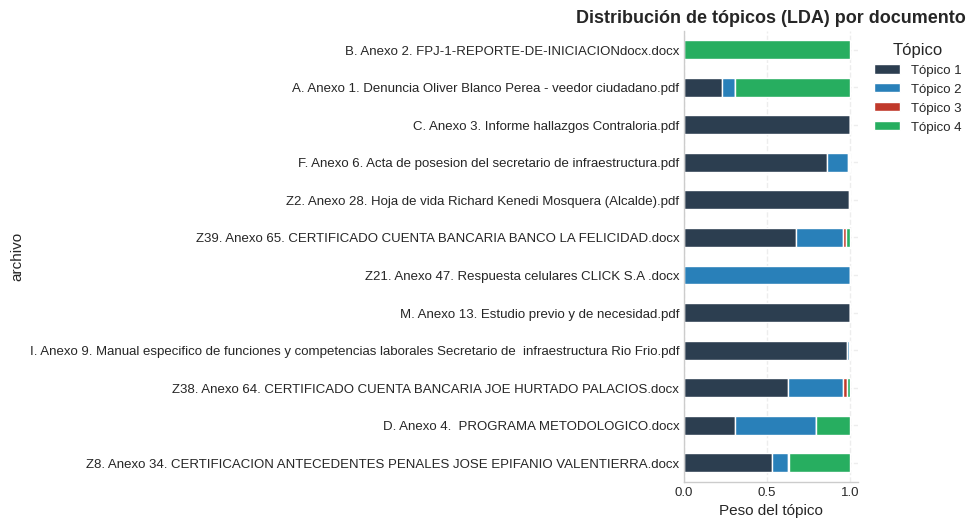

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICOS = min(5, max(2, len(df) // 3))  # pocos tópicos, ajustados al tamaño del corpus

print(
    f"Nota metodológica: LDA típicamente necesita corpus de cientos o miles de documentos para "
    f"converger de forma estable. Con {len(df)} documento(s), los {N_TOPICOS} tópicos que siguen "
    f"son ORIENTATIVOS (una forma de agrupar vocabulario compartido), no una verdad categórica."
)

vectorizador_lda = CountVectorizer(max_features=300, min_df=1)
matriz_conteo_lda = vectorizador_lda.fit_transform(df["texto_lematizado_sin_stopwords"])
terminos_lda = vectorizador_lda.get_feature_names_out()

modelo_lda = LatentDirichletAllocation(n_components=N_TOPICOS, random_state=42, max_iter=25, learning_method="batch")
distribucion_topicos = modelo_lda.fit_transform(matriz_conteo_lda)  # documentos x tópicos

def _top_palabras_topico(componente, top_n=8):
    indices = componente.argsort()[::-1][:top_n]
    return [terminos_lda[i] for i in indices]

df_topicos_palabras = pd.DataFrame({
    f"Tópico {i + 1}": _top_palabras_topico(comp) for i, comp in enumerate(modelo_lda.components_)
})
print("\nPalabras más representativas de cada tópico:")
mostrar_tabla(df_topicos_palabras, titulo=f"Tópicos (LDA, {N_TOPICOS} tópicos) — palabras más representativas")

df_distribucion_topicos = pd.DataFrame(
    distribucion_topicos, columns=[f"Tópico {i + 1}" for i in range(N_TOPICOS)], index=df["archivo"]
)
df_topico_dominante = pd.DataFrame({
    "Documento": df["archivo"].values,
    "Tópico dominante": [f"Tópico {i + 1}" for i in distribucion_topicos.argmax(axis=1)],
    "Peso del tópico dominante": distribucion_topicos.max(axis=1).round(2),
})
print("\nTópico dominante por documento:")
mostrar_tabla(df_topico_dominante, titulo="Tópico dominante por documento", columnas_barra=["Peso del tópico dominante"])

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(df))))
df_distribucion_topicos.plot(kind="barh", stacked=True, ax=ax, color=PALETA_CATEGORICA[:N_TOPICOS])
ax.set_title("Distribución de tópicos (LDA) por documento")
ax.set_xlabel("Peso del tópico")
ax.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


## Paso 4 — Embeddings semánticos

Usamos un modelo multilingüe liviano (`paraphrase-multilingual-MiniLM-L12-v2`) que funciona bien en
español. El embedding de cada documento se calcula como el **promedio de los embeddings de sus
oraciones** — esto captura mejor el significado global del documento que un solo vector para todo
el texto de una vez (que diluiría oraciones largas frente a cortas).


In [ ]:
modelo_embeddings = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def embeddings_oraciones(oraciones, modelo):
    """Calcula el embedding de cada oración de un documento (matriz oraciones x dimensiones)."""
    if not oraciones:
        return np.zeros((0, modelo.get_sentence_embedding_dimension()))
    return modelo.encode(oraciones, show_progress_bar=False)

# Se guardan los embeddings POR ORACIÓN de cada documento (se reutilizan en el Paso 5 para explicar el "por qué")
embeddings_por_documento = [embeddings_oraciones(oraciones, modelo_embeddings) for oraciones in df["oraciones"]]

# El embedding del documento completo es el promedio de los embeddings de sus oraciones
embeddings_documentos = np.vstack([
    vectores.mean(axis=0) if len(vectores) > 0 else np.zeros(modelo_embeddings.get_sentence_embedding_dimension())
    for vectores in embeddings_por_documento
])

print(f"Matriz de embeddings de documentos: {embeddings_documentos.shape[0]} documentos x "
      f"{embeddings_documentos.shape[1]} dimensiones")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Matriz de embeddings de documentos: 12 documentos x 384 dimensiones


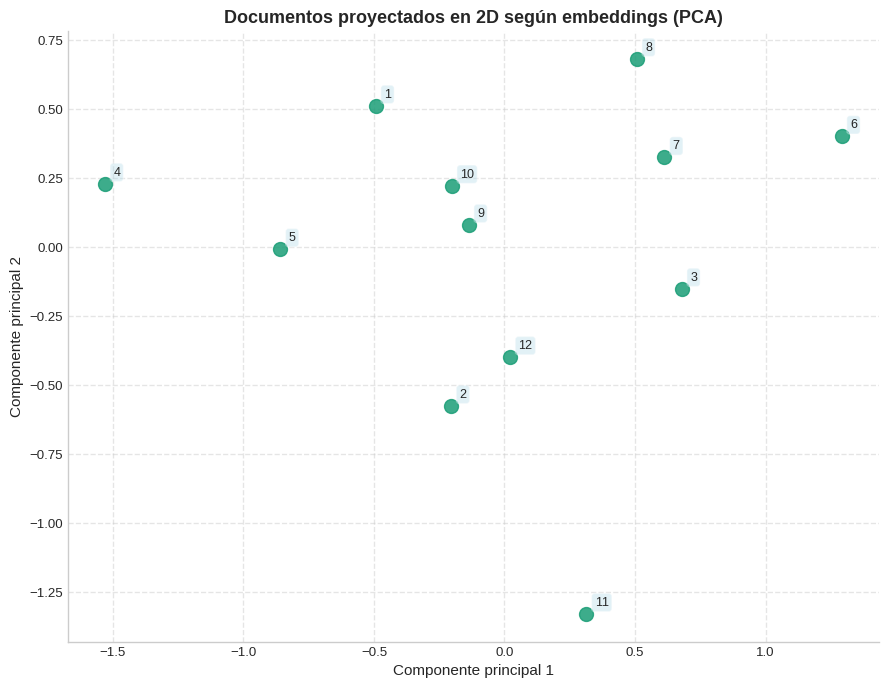


Tabla de identificación de documentos (misma numeración que en el gráfico de TF-IDF):


,Número en el gráfico,Documento
0,1,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...
1,2,D. Anexo 4. PROGRAMA METODOLOGICO.docx
2,3,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...
3,4,I. Anexo 9. Manual especifico de funciones y c...
4,5,M. Anexo 13. Estudio previo y de necesidad.pdf
5,6,Z21. Anexo 47. Respuesta celulares CLICK S.A ....
6,7,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...
7,8,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...
8,9,F. Anexo 6. Acta de posesion del secretario de...
9,10,C. Anexo 3. Informe hallazgos Contraloria.pdf


In [ ]:
pca_embeddings = PCA(n_components=2, random_state=42)
coords_embeddings_2d = pca_embeddings.fit_transform(embeddings_documentos)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_embeddings_2d[:, 0], coords_embeddings_2d[:, 1], s=100, color="#1b9e77", alpha=0.85)
for i in range(len(df)):
    ax.annotate(str(i + 1), (coords_embeddings_2d[i, 0], coords_embeddings_2d[i, 1]),
                fontsize=9, xytext=(6, 6), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.25", fc="lightblue", alpha=0.35))
ax.set_title("Documentos proyectados en 2D según embeddings (PCA)", fontsize=13)
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

print("\nTabla de identificación de documentos (misma numeración que en el gráfico de TF-IDF):")
display(tabla_id_documentos)


## Paso 5 — Similitud entre documentos: comparación TF-IDF vs. embeddings, y el "por qué"

Calculamos la similitud coseno documento-documento con ambos métodos y las comparamos lado a lado.
Después, para el par de documentos más cercano según embeddings, mostramos **cuáles oraciones
específicas** explican ese parecido — respondiendo directamente a "por qué son cercanos", que es
la pregunta que TF-IDF responde solo, mediante los términos compartidos.


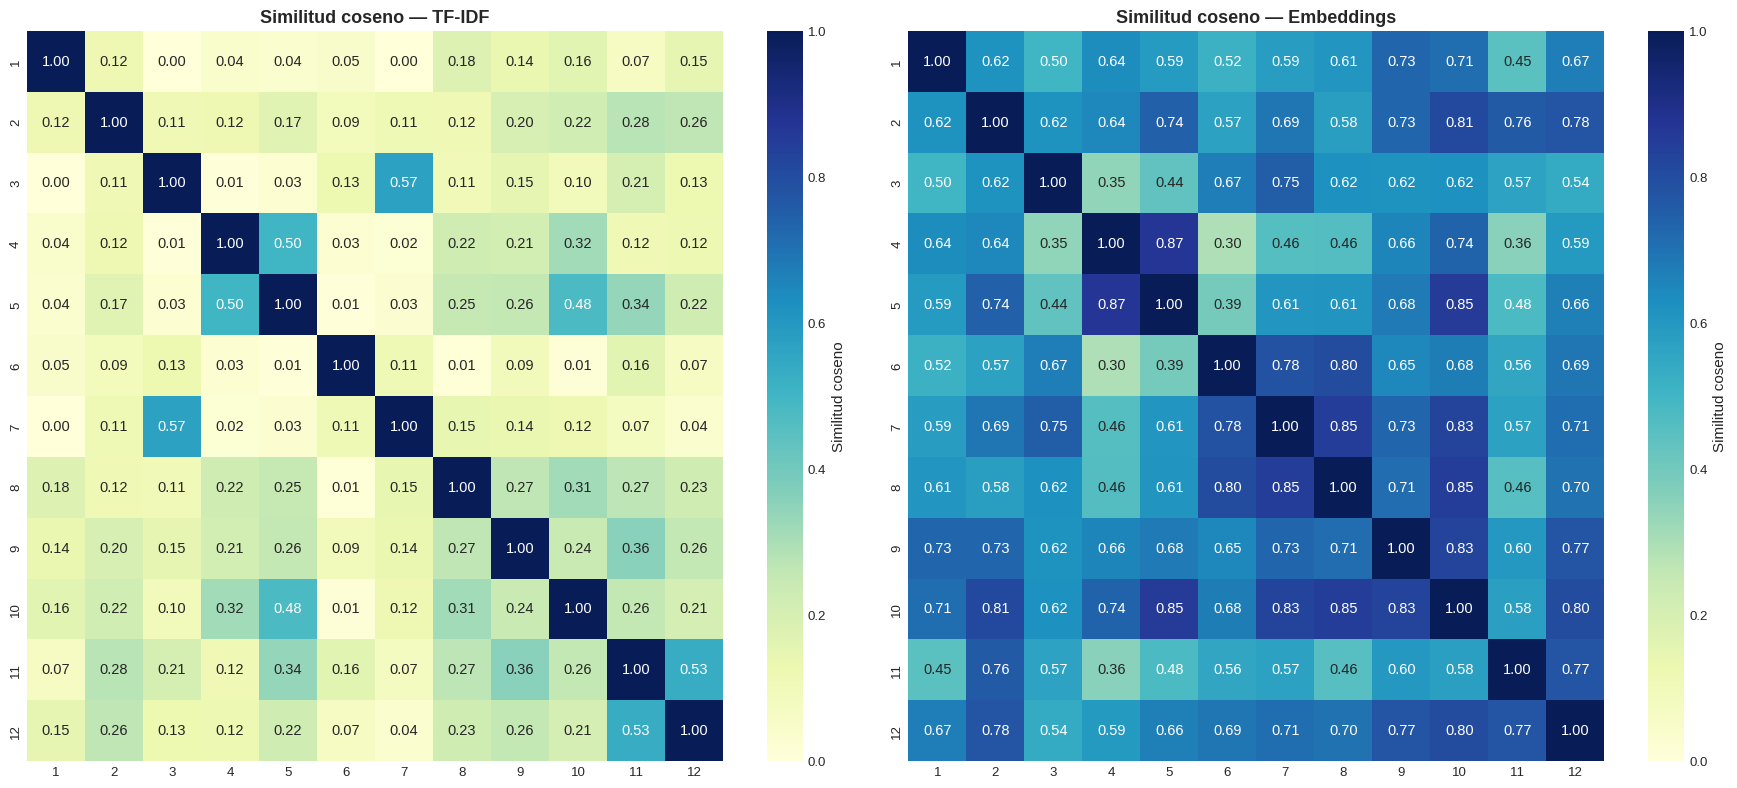


Tabla de identificación de documentos para los mapas de calor:


,Número,Documento
0,1,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...
1,2,D. Anexo 4. PROGRAMA METODOLOGICO.docx
2,3,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...
3,4,I. Anexo 9. Manual especifico de funciones y c...
4,5,M. Anexo 13. Estudio previo y de necesidad.pdf
5,6,Z21. Anexo 47. Respuesta celulares CLICK S.A ....
6,7,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...
7,8,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...
8,9,F. Anexo 6. Acta de posesion del secretario de...
9,10,C. Anexo 3. Informe hallazgos Contraloria.pdf


In [ ]:
sim_tfidf = cosine_similarity(matriz_tfidf)          # matriz de similitud coseno, basada en TF-IDF
sim_embeddings = cosine_similarity(embeddings_documentos)  # matriz de similitud coseno, basada en embeddings

num_labels = list(range(1, len(df) + 1))              # se usan números en los ejes para no saturar el gráfico
nombre_archivo_mapeo = pd.DataFrame({"Número": num_labels, "Documento": df["archivo"]})

df_sim_tfidf = pd.DataFrame(sim_tfidf, index=num_labels, columns=num_labels)
df_sim_embeddings = pd.DataFrame(sim_embeddings, index=num_labels, columns=num_labels)

fig, ejes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(df_sim_tfidf, cmap="YlGnBu", vmin=0, vmax=1, annot=True, fmt=".2f",
            ax=ejes[0], cbar_kws={"label": "Similitud coseno"})
ejes[0].set_title("Similitud coseno — TF-IDF")

sns.heatmap(df_sim_embeddings, cmap="YlGnBu", vmin=0, vmax=1, annot=True, fmt=".2f",
            ax=ejes[1], cbar_kws={"label": "Similitud coseno"})
ejes[1].set_title("Similitud coseno — Embeddings")

plt.tight_layout()
plt.show()

print("\nTabla de identificación de documentos para los mapas de calor:")
display(nombre_archivo_mapeo)


In [ ]:
def top_pares_similares(matriz_similitud, nombres, top_n=10):
    """Devuelve los N pares de documentos DISTINTOS más similares, ordenados de mayor a menor."""
    pares = []
    n = matriz_similitud.shape[0]
    for i in range(n):
        for j in range(i + 1, n):                      # solo el triángulo superior: evita duplicar (i,j)=(j,i)
            pares.append((nombres[i], nombres[j], matriz_similitud[i, j]))
    pares.sort(key=lambda x: x[2], reverse=True)        # de mayor a menor similitud
    return pares[:top_n]


nombres_docs = df["archivo"].tolist()

print("--- Pares de documentos más cercanos según TF-IDF (coincidencia léxica) ---")
tabla_pares_tfidf = pd.DataFrame(top_pares_similares(sim_tfidf, nombres_docs),
                                  columns=["Documento A", "Documento B", "Similitud (TF-IDF)"])
display(tabla_pares_tfidf)

print("\n--- Pares de documentos más cercanos según embeddings (significado) ---")
tabla_pares_embeddings = pd.DataFrame(top_pares_similares(sim_embeddings, nombres_docs),
                                       columns=["Documento A", "Documento B", "Similitud (embeddings)"])
display(tabla_pares_embeddings)

print("\nCompara ambas tablas: si un par aparece arriba en embeddings pero no en TF-IDF, es evidencia "
      "de que esos dos documentos hablan de lo mismo con palabras distintas (paráfrasis) — exactamente "
      "el caso que TF-IDF no puede detectar.")


--- Pares de documentos más cercanos según TF-IDF (coincidencia léxica) ---


,Documento A,Documento B,Similitud (TF-IDF)
0,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE...,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,0.572167
1,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,0.532789
2,I. Anexo 9. Manual especifico de funciones y c...,M. Anexo 13. Estudio previo y de necesidad.pdf,0.502061
3,M. Anexo 13. Estudio previo y de necesidad.pdf,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.478455
4,F. Anexo 6. Acta de posesion del secretario de...,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,0.359173
5,M. Anexo 13. Estudio previo y de necesidad.pdf,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,0.337775
6,I. Anexo 9. Manual especifico de funciones y c...,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.315989
7,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.314145
8,D. Anexo 4. PROGRAMA METODOLOGICO.docx,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,0.276513
9,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,0.266678



--- Pares de documentos más cercanos según embeddings (significado) ---


,Documento A,Documento B,Similitud (embeddings)
0,I. Anexo 9. Manual especifico de funciones y c...,M. Anexo 13. Estudio previo y de necesidad.pdf,0.869422
1,M. Anexo 13. Estudio previo y de necesidad.pdf,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.852255
2,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.846487
3,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,0.845149
4,F. Anexo 6. Acta de posesion del secretario de...,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.831875
5,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.826387
6,D. Anexo 4. PROGRAMA METODOLOGICO.docx,C. Anexo 3. Informe hallazgos Contraloria.pdf,0.811167
7,C. Anexo 3. Informe hallazgos Contraloria.pdf,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,0.803174
8,Z21. Anexo 47. Respuesta celulares CLICK S.A ....,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosq...,0.802673
9,Z21. Anexo 47. Respuesta celulares CLICK S.A ....,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BAN...,0.782252



Compara ambas tablas: si un par aparece arriba en embeddings pero no en TF-IDF, es evidencia de que esos dos documentos hablan de lo mismo con palabras distintas (paráfrasis) — exactamente el caso que TF-IDF no puede detectar.


In [ ]:
def explicar_similitud_por_oraciones(idx_doc_a, idx_doc_b, top_n=5):
    """
    Para un par de documentos (por su posición en 'df'), calcula la similitud coseno entre CADA
    oración del documento A y CADA oración del documento B usando sus embeddings ya calculados,
    y devuelve los 'top_n' pares de oraciones más parecidas. Esto es lo que permite explicar,
    con evidencia textual concreta, POR QUÉ dos documentos salieron cercanos según embeddings.
    """
    oraciones_a = df["oraciones"].iloc[idx_doc_a]
    oraciones_b = df["oraciones"].iloc[idx_doc_b]
    vectores_a = embeddings_por_documento[idx_doc_a]
    vectores_b = embeddings_por_documento[idx_doc_b]

    if len(oraciones_a) == 0 or len(oraciones_b) == 0:
        return []

    sim_oraciones = cosine_similarity(vectores_a, vectores_b)  # matriz oraciones_A x oraciones_B

    pares_oraciones = []
    for i in range(sim_oraciones.shape[0]):
        for j in range(sim_oraciones.shape[1]):
            pares_oraciones.append((oraciones_a[i], oraciones_b[j], sim_oraciones[i, j]))
    pares_oraciones.sort(key=lambda x: x[2], reverse=True)
    return pares_oraciones[:top_n]


# Se aplica automáticamente al par de documentos MÁS cercano según embeddings (el primero de la tabla anterior)
if len(tabla_pares_embeddings) > 0:
    doc_a_nombre = tabla_pares_embeddings.iloc[0]["Documento A"]
    doc_b_nombre = tabla_pares_embeddings.iloc[0]["Documento B"]
    idx_a = df.index[df["archivo"] == doc_a_nombre][0]
    idx_b = df.index[df["archivo"] == doc_b_nombre][0]

    print(f"¿Por qué '{doc_a_nombre}' y '{doc_b_nombre}' son el par más cercano según embeddings?")
    print(f"Similitud global: {sim_embeddings[idx_a, idx_b]:.3f}\n")
    print("Las oraciones que más contribuyen a ese parecido (comparadas oración por oración):\n")

    filas_explicacion = []
    for oracion_a, oracion_b, score in explicar_similitud_por_oraciones(idx_a, idx_b):
        print(f"  [{score:.3f}]")
        print(f"    A: {oracion_a}")
        print(f"    B: {oracion_b}\n")
        filas_explicacion.append({
            "Documento A": doc_a_nombre, "Oración A": oracion_a,
            "Documento B": doc_b_nombre, "Oración B": oracion_b,
            "Similitud": round(float(score), 4),
        })
    df_explicacion_similitud = pd.DataFrame(filas_explicacion)
else:
    df_explicacion_similitud = pd.DataFrame(columns=["Documento A", "Oración A", "Documento B", "Oración B", "Similitud"])
    print("No hay suficientes documentos para comparar pares.")


¿Por qué 'I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de  infraestructura Rio Frio.pdf' y 'M. Anexo 13. Estudio previo y de necesidad.pdf' son el par más cercano según embeddings?
Similitud global: 0.869

Las oraciones que más contribuyen a ese parecido (comparadas oración por oración):

  [0.776]
    A: • Elaborar y
suscribir las actas correspondientes que resulten durante la ejecución del contrato.
    B: ▪ Responsabilidad civil extracontractual, derivada de la ejecución del
contrato a través de un amparo autónomo, contenido en una póliza
anexa y en una cuantía del cinco por ciento (5%) del valor de este y
con una vigencia igual a la duración del contrato, contados a partir de
su perfeccionamiento.

  [0.736]
    A: Cuando se trate de contratos de obra pública, deberá revisar y aprobar que el
presupuesto inicial de ésta esté de acuerdo con las especificaciones, los planos y
los diseños.
    B: Se seleccionará esta alternativa por
tratarse de la ejec

### 5.1 — Distribución de las similitudes (TF-IDF vs. embeddings)

,Método,Similitud media,Similitud mínima,Similitud máxima
0,TF-IDF,0.167873,0.000000,0.572167
1,Embeddings,0.641702,0.295928,0.869422


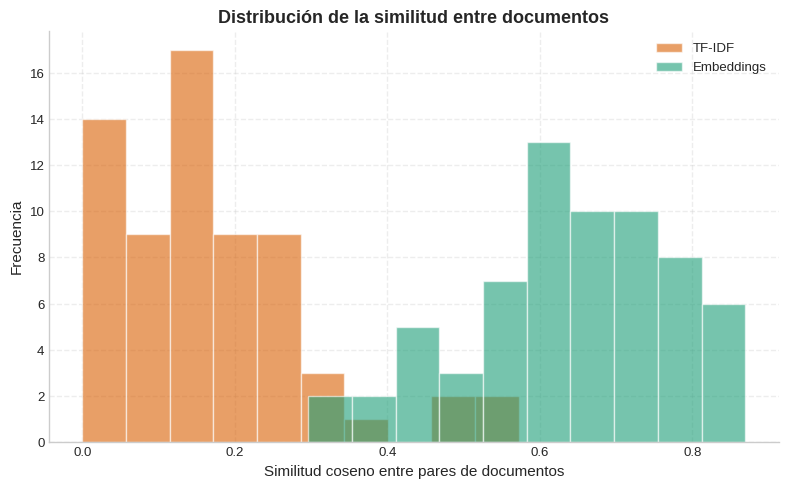

Si la distribución de embeddings está más concentrada en valores altos que la de TF-IDF, es evidencia de que los documentos comparten significado aunque usen palabras distintas (paráfrasis) — justamente lo que TF-IDF no puede capturar.


In [ ]:
def valores_triangulo_superior(matriz):
    n = matriz.shape[0]
    return [matriz[i, j] for i in range(n) for j in range(i + 1, n)]


vals_tfidf = valores_triangulo_superior(sim_tfidf)
vals_emb = valores_triangulo_superior(sim_embeddings)

df_stats_similitud = pd.DataFrame({
    "Método": ["TF-IDF", "Embeddings"],
    "Similitud media": [np.mean(vals_tfidf), np.mean(vals_emb)],
    "Similitud mínima": [np.min(vals_tfidf), np.min(vals_emb)],
    "Similitud máxima": [np.max(vals_tfidf), np.max(vals_emb)],
})
display(df_stats_similitud)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals_tfidf, bins=10, alpha=0.6, label="TF-IDF", color="#d95f02")
ax.hist(vals_emb, bins=10, alpha=0.6, label="Embeddings", color="#1b9e77")
ax.set_xlabel("Similitud coseno entre pares de documentos")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la similitud entre documentos")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Si la distribución de embeddings está más concentrada en valores altos que la de TF-IDF, "
    "es evidencia de que los documentos comparten significado aunque usen palabras distintas "
    "(paráfrasis) — justamente lo que TF-IDF no puede capturar."
)


## Paso 6 — Extracción de entidades nombradas (NER)

Usamos el modelo `es_core_news_lg` (más preciso que `md`) para detectar personas (PER),
organizaciones (ORG), lugares (LOC) y fechas (DATE). Además, sumamos **reglas complementarias por
expresiones regulares** para dos tipos de entidad muy comunes en expedientes judiciales colombianos
que el NER genérico de spaCy normalmente no reconoce bien:
- **RADICADO**: números de radicado / expediente (ej. "Radicado No. 2023-00123").
- **DESPACHO**: despachos judiciales (ej. "Juzgado 3 Penal del Circuito de Quibdó",
  "Fiscalía 15 Seccional").

Cada entidad detectada se guarda junto con la **oración completa donde aparece** (columna
`oracion_contexto`), que es la base del Paso 8 ("qué se dice de cada entidad").


## Paso 6 — NER forense mejorado: separar detección de entidades de interpretación

**Cambio clave:** el notebook no debe confiar en que todo lo que spaCy etiqueta como `LOC` sea realmente un lugar. Se conservan solo los tipos útiles para el objetivo forense y se aplican reglas de calidad.

Además, la normalización se hace en una columna auxiliar **en minúsculas y sin tildes**, pero se conserva el texto original para evidencia. Así, `Río Frío Chocó`, `Riofrio FRIO CHOCO` y variantes similares pueden compararse sin destruir la forma documental original.

Para personas se usa una resolución de entidades más estricta: inversión de apellidos/nombre, eliminación de identificadores, tolerancia a errores OCR como `Kennedi/Kenedi`, y coincidencia por tokens. No se fusionan personas solo porque compartan un apellido.


### 6.0 — Motor de NER: modelo transformer local (mejora la precisión, sin costo)

Antes de extraer entidades, se carga un modelo NER **transformer en español**
(`PlanTL-GOB-ES/roberta-base-bne-capitel-ner`), entrenado en corpus reales, que suele distinguir
mejor un nombre de persona real de un fragmento de tabla/encabezado que el NER estadístico de
spaCy. Corre **localmente en esta sesión de Colab** (usa GPU si está disponible, si no, CPU) — no
llama a ninguna API externa, así que no consume créditos ni requiere token. Si por algún motivo no
se puede cargar, el notebook sigue funcionando igual, usando solo el NER de spaCy.

In [ ]:
try:
    import torch
    from transformers import pipeline as _hf_pipeline
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "torch", "accelerate"], check=False)
    import torch
    from transformers import pipeline as _hf_pipeline

USAR_NER_TRANSFORMER = True
MODELO_NER_TRANSFORMER = "PlanTL-GOB-ES/roberta-base-bne-capitel-ner"

ner_transformer = None
if USAR_NER_TRANSFORMER:
    try:
        _dispositivo = 0 if torch.cuda.is_available() else -1
        ner_transformer = _hf_pipeline(
            "token-classification", model=MODELO_NER_TRANSFORMER,
            aggregation_strategy="simple", device=_dispositivo,
        )
        print(
            f"NER local cargado: {MODELO_NER_TRANSFORMER} "
            f"(device={'GPU' if _dispositivo == 0 else 'CPU'}). Corre en tu propia sesión de Colab, "
            f"sin llamadas a ninguna API — no consume créditos ni requiere token."
        )
    except Exception as e:
        print(f"No se pudo cargar el NER transformer local ({e}).")
        print("Se usará únicamente el NER estadístico de spaCy (más limitado, pero disponible siempre).")
        ner_transformer = None
else:
    print("USAR_NER_TRANSFORMER = False → se usa únicamente el NER de spaCy.")


No se pudo cargar el NER transformer local (PlanTL-GOB-ES/roberta-base-bne-capitel-ner is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`).
Se usará únicamente el NER estadístico de spaCy (más limitado, pero disponible siempre).


In [ ]:
import unicodedata
from rapidfuzz import fuzz

TIPOS_PERSONA = {"PER", "PERSON"}
TIPOS_ORG = {"ORG"}
TIPOS_LOC = {"LOC", "GPE", "FAC"}

def sin_tildes(texto):
    texto = str(texto)
    return "".join(c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c))

def normalizar_comparacion(texto):
    """Forma auxiliar para comparar entidades: minúsculas, sin tildes, sin identificadores ni puntuación."""
    x = sin_tildes(texto).lower()
    x = re.sub(r"\b(?:cc|c\.c\.?|cedula|identificacion|id|nit)\b", " ", x)
    x = re.sub(r"\b\d[\d\.\-\/]{3,}\b", " ", x)
    x = re.sub(r"[^a-z0-9ñ ]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def tokens_norm(texto):
    return [t for t in normalizar_comparacion(texto).split() if len(t) > 1]

def nombre_persona_normalizado(texto):
    """Normaliza nombres para comparar formas como 'Lucumi, Richard Kennedi Mosquera' y 'Richard Kenedi Mosquera Lucumi'."""
    toks = tokens_norm(texto)
    # No ordenar todo: conservamos tokens y usamos conjunto para tolerar inversión de nombre/apellidos.
    return toks

def similitud_personas(a, b):
    ta, tb = nombre_persona_normalizado(a), nombre_persona_normalizado(b)
    if not ta or not tb:
        return 0
    sa, sb = set(ta), set(tb)
    inter = len(sa & sb)
    cobertura = inter / max(1, min(len(sa), len(sb)))
    token_score = fuzz.token_set_ratio(" ".join(ta), " ".join(tb))
    return max(token_score, cobertura * 100)

# Lista de falsos positivos observados en expedientes. Se amplía sin tocar la evidencia original.
PALABRAS_NO_LUGAR = {
    "retiro", "ciudad", "colombia", "tecnologica", "tecnologica", "ley", "cuenta",
    "identificacion", "identificacion", "numero", "no", "tl", "wwe", "web", "5o"
}

def parece_lugar_valido(texto):
    n = normalizar_comparacion(texto)
    if not n or n in PALABRAS_NO_LUGAR:
        return False
    toks = n.split()
    if len(toks) == 1 and (len(toks[0]) <= 2 or toks[0].isdigit()):
        return False
    # Si spaCy produjo una sola palabra genérica, la descartamos.
    if n in {"ciudad", "pais", "municipio", "departamento", "barrio", "zona", "region"}:
        return False
    return True


# ------------------------------------------------------------------
# NUEVO: filtro de calidad para candidatos a "PERSONA" (PER).
#
# Problema real observado en el expediente: al extraer texto de formularios/tablas de Word
# (ej. "Nombres y apellidos / Entidad / Función / Rosa Mena Mora / FGN CTI / ..."), spaCy a
# veces devuelve un span de entidad que CRUZA un salto de línea y mezcla dos nombres distintos
# en un solo texto (ej. "José Epifanio Valentierra C.C. 1.001.311.120\nPedro Murillo Renteria
# C.C."). Si eso se deja pasar, el paso de resolución de identidades (6b) puede terminar
# fusionando dos personas reales en una sola "identidad", porque la entidad larga contiene los
# tokens de ambas.
#
# La regla es simple y auditable: se cuenta cuántas "líneas tipo nombre" (2 a 5 palabras, cada
# una con mayúscula inicial, sin palabras de rol/organización conocidas) hay dentro del texto de
# la entidad.
#   - Exactamente 1  -> se acepta como persona.
#   - 0               -> no parece un nombre real (ruido, lugar, encabezado de tabla) -> se descarta.
#   - 2 o más         -> son varias personas mezcladas en una sola entidad -> se descarta ANTES de
#                        que llegue a la resolución de identidades (Paso 6b), en vez de dejar que
#                        el algoritmo de agrupación las fusione por error.
#
# Nota honesta: esta es una heurística, no un clasificador perfecto. Puede que algún caso raro
# se cuele o se descarte de más; para esos casos puntuales, agrega el texto EXACTO de la columna
# "texto" a PERSONAS_EXCLUIDAS_MANUAL más abajo.
# ------------------------------------------------------------------

PALABRAS_ROL_ORG = {
    "fgn", "cti", "fiscal", "fiscalia", "seccional", "subintendente", "intendente", "area",
    "investigativa", "firma", "despacho", "juzgado", "alcaldia", "secretaria", "direccion",
    "policia", "nacional", "municipio", "gobernacion", "contraloria", "delegada", "veedor",
    "veedora", "ciudadano", "ciudadana", "contratista", "entidad", "funcion",
}

def _es_linea_tipo_nombre(linea):
    palabras = [p for p in linea.strip().split() if p.isalpha()]
    if not (2 <= len(palabras) <= 5):
        return False
    if not all(p[0].isupper() for p in palabras):
        return False
    if any(sin_tildes(p).lower() in PALABRAS_ROL_ORG for p in palabras):
        return False
    return True

def contar_lineas_tipo_nombre(texto):
    return sum(1 for linea in str(texto).split("\n") if _es_linea_tipo_nombre(linea))

# Aquí puedes agregar a mano textos exactos (tal como aparecen en la columna "texto") que el
# filtro automático no logre descartar, sin tocar el resto del código.
PERSONAS_EXCLUIDAS_MANUAL = set()

# ------------------------------------------------------------------
# NUEVO: mismo problema, pero para ORGANIZACIONES y LUGARES.
#
# Ejemplos reales observados: "SIN" y "NACIONAL" capturados como ORG (son parte de las frases
# "SIN VALIDEZ LEGAL" y "POLICIA NACIONAL", no organizaciones en sí mismas); "METODOLOGICO"
# capturado como LOC; entidades que pegan varias líneas de una tabla en un solo texto
# ("Consulta de Antecedentes\nÁrea de Capacitación Judicial\nFirma").
#
# Mismo principio que para personas: se descartan ANTES de la resolución de identidades, para
# que no contaminen ni el conteo de menciones ni la agrupación de variantes.
# ------------------------------------------------------------------

PALABRAS_GENERICAS_ORG_LOC = {
    "sin", "no", "nacional", "metodologico", "articulo", "capitulo", "titulo", "seccion",
    "anexo", "documento", "fecha", "hora", "codigo", "unico", "investigacion", "despacho",
    "unidad", "integrantes", "equipo", "reuniones", "medios", "cognoscitivos", "hipotesis",
    "delictiva", "actividades", "desarrollar", "ordenes", "objetivo", "asistentes", "revision",
    "resultado", "consulta", "identidad", "ciudadania", "registros", "informacion", "presenta",
    # Ampliación tras revisar falsos positivos reales en ORG/LOC:
    "hechos", "por", "cargo", "depto", "sem", "media", "consejo", "asesor", "contratista",
    "evaluacion", "secretario", "secretaria", "municipal", "publica", "publico", "entidad",
    "funcion", "cumplimiento", "municipio", "anos", "meses", "dias", "responsable", "cuantia",
    "calidad", "descripcion", "plazo", "garantias", "presupuestal", "acta", "registro",
    "obra", "servicio", "profesional", "bien", "verificar", "contrato", "ejecucion",
    "requisitos", "competencias", "laborales", "vinculacion", "interventor", "interno",
    "seguridad", "salud", "trabajo", "cuerpo", "tarjeta", "direccion", "forma",
}

# Preposiciones/artículos: si el primer o último token de la entidad es uno de estos, casi
# siempre indica que el span de spaCy se cortó mal (ej. "MUNICIPIO DE", "CUMPLIMIENTO DE").
PREPOSICIONES_ARTICULOS = {
    "de", "del", "la", "el", "los", "las", "en", "por", "para", "con", "sin", "al", "y", "u", "o", "a",
}

# Lista BLANCA de siglas institucionales conocidas (reemplaza la regla anterior de "cualquier
# palabra corta en mayúsculas", que dejaba pasar palabras comunes como HECHOS, POR, SEM, MEDIA).
ACRONIMOS_INSTITUCIONALES_VALIDOS = {
    "fgn", "cti", "dian", "sijin", "das", "icbf", "inpec", "esap", "dnp", "car", "ani", "idu",
    "dps", "dijin", "sena", "dane", "ins", "invima", "aifit", "emp", "cgr",
}

# Textos exactos (columna "texto") a excluir a mano para ORG y LOC, respectivamente.
ORGANIZACIONES_EXCLUIDAS_MANUAL = set()
LUGARES_EXCLUIDOS_MANUAL = set()

def es_entidad_persona_valida(texto):
    """True si el texto de la entidad parece corresponder a UNA sola persona real."""
    texto = str(texto)
    if texto.strip() in PERSONAS_EXCLUIDAS_MANUAL:
        return False
    palabras_norm = normalizar_comparacion(texto).split()
    if not palabras_norm:
        return False
    if len(palabras_norm) > 12:
        return False  # demasiado largo para ser un nombre real (probable ruido de tabla)
    return contar_lineas_tipo_nombre(texto) == 1


def es_entidad_org_valida(texto):
    """
    True si el texto de la entidad parece un nombre de organización real.
    Reglas (más estrictas que la versión anterior, tras revisar falsos positivos reales):
      - Una sola línea (no fragmentos de tabla pegados).
      - NINGUNA de sus palabras puede ser una palabra genérica/de encabezado de tabla
        (aplica también a entidades de varias palabras, no solo a las de una sola palabra).
      - No puede terminar en una preposición/artículo suelto (indica que el span se cortó mal,
        ej. "MUNICIPIO DE", "CUMPLIMIENTO DE", "FECHA DE").
      - Una sola palabra en mayúsculas SOLO se acepta si está en la lista blanca de siglas
        institucionales conocidas (ya no "cualquier palabra de 2 a 6 mayúsculas", que dejaba
        pasar palabras comunes como "HECHOS", "POR", "SEM", "MEDIA").
    """
    lineas = [l.strip() for l in str(texto).split("\n") if l.strip()]
    if not lineas:
        return False
    if len(lineas) > 1:
        return False

    texto_limpio = lineas[0]
    if texto_limpio.strip() in ORGANIZACIONES_EXCLUIDAS_MANUAL:
        return False

    palabras = [p for p in texto_limpio.split() if p.isalpha()]
    if not palabras:
        return False

    palabras_norm = [sin_tildes(p).lower() for p in palabras]

    # Ninguna palabra puede ser genérica/de encabezado, sin importar cuántas palabras tenga la entidad.
    if any(p in PALABRAS_GENERICAS_ORG_LOC for p in palabras_norm):
        return False

    # No puede terminar en preposición/artículo suelto: indica un span cortado.
    if palabras_norm[-1] in PREPOSICIONES_ARTICULOS:
        return False
    if palabras_norm[0] in PREPOSICIONES_ARTICULOS:
        return False

    if len(palabras) == 1:
        palabra = palabras[0]
        if palabra.isupper():
            # Solo se acepta como sigla si está en la lista blanca conocida (ya no "cualquier
            # palabra corta en mayúsculas": eso dejaba pasar palabras comunes como HECHOS/POR/SEM).
            return palabras_norm[0] in ACRONIMOS_INSTITUCIONALES_VALIDOS
        if len(palabra) < 6:
            return False  # palabra suelta corta: muy poco probable que sea el nombre completo de una org
        return palabra[0].isupper()

    return True  # 2+ palabras en una sola línea, ninguna genérica, sin preposición colgante


def es_entidad_loc_valida(texto):
    """Extiende parece_lugar_valido con las mismas reglas estrictas que ORG (una sola línea,
    sin palabras genéricas, sin preposición colgante)."""
    lineas = [l.strip() for l in str(texto).split("\n") if l.strip()]
    if len(lineas) != 1:
        return False
    texto_limpio = lineas[0]
    if texto_limpio.strip() in LUGARES_EXCLUIDOS_MANUAL:
        return False
    if not parece_lugar_valido(texto_limpio):
        return False
    palabras = [p for p in texto_limpio.split() if p.isalpha()]
    if not palabras:
        return False
    palabras_norm = [sin_tildes(p).lower() for p in palabras]
    if any(p in PALABRAS_GENERICAS_ORG_LOC for p in palabras_norm):
        return False
    if palabras_norm[-1] in PREPOSICIONES_ARTICULOS or palabras_norm[0] in PREPOSICIONES_ARTICULOS:
        return False
    return True


# ------------------------------------------------------------------
# NUEVO: extracción de FECHAS por expresiones regulares (spaCy es_core_news_lg no trae un tipo
# DATE nativo confiable). Se reconocen los formatos típicos de expedientes judiciales en español:
# "28 de junio de 2023", "28/06/2023", "01-02-2022", "marzo de 2022".
# Cada fecha se guarda con su oración de contexto, para poder construir después una cronología
# de "qué se dice que pasó" en cada fecha (Paso 6c).
# ------------------------------------------------------------------

MESES_ES = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12,
}
_PATRON_FECHA_TEXTUAL = re.compile(
    r"\b\d{1,2}\s+de\s+(?:enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)"
    r"(?:\s+de)?\s+\d{4}\b", re.IGNORECASE,
)
_PATRON_FECHA_NUMERICA = re.compile(r"\b\d{1,2}[/\-]\d{1,2}[/\-]\d{4}\b")
_PATRON_MES_ANIO = re.compile(
    r"\b(?:enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|octubre|noviembre|diciembre)"
    r"(?:\s+de)?\s+\d{4}\b", re.IGNORECASE,
)

def extraer_fechas_de_oracion(oracion):
    encontradas = []
    cubiertos = set()
    for patron in (_PATRON_FECHA_TEXTUAL, _PATRON_FECHA_NUMERICA):
        for m in patron.finditer(oracion):
            if m.group(0) not in cubiertos:
                encontradas.append(m.group(0))
                cubiertos.add(m.group(0))
    for m in _PATRON_MES_ANIO.finditer(oracion):
        texto_m = m.group(0)
        if not any(texto_m.lower() in f.lower() for f in encontradas):
            encontradas.append(texto_m)
    return encontradas

def normalizar_fecha_a_iso(texto_fecha):
    """Convierte una fecha en texto a 'AAAA-MM-DD' (o 'AAAA-MM-01' si solo hay mes/año) para
    poder ordenar la cronología. Devuelve None si no logra interpretarla."""
    t = sin_tildes(texto_fecha).lower().strip()
    m = re.match(r"(\d{1,2})\s+de\s+(\w+)(?:\s+de)?\s+(\d{4})", t)
    if m:
        dia, mes_txt, anio = m.groups()
        mes = MESES_ES.get(mes_txt)
        if mes:
            return f"{int(anio):04d}-{mes:02d}-{int(dia):02d}"
    m = re.match(r"(\d{1,2})[/\-](\d{1,2})[/\-](\d{4})", t)
    if m:
        d1, d2, anio = m.groups()
        return f"{int(anio):04d}-{int(d2):02d}-{int(d1):02d}"  # dd/mm/aaaa (convención colombiana)
    m = re.match(r"(\w+)(?:\s+de)?\s+(\d{4})", t)
    if m:
        mes_txt, anio = m.groups()
        mes = MESES_ES.get(mes_txt)
        if mes:
            return f"{int(anio):04d}-{mes:02d}-01"
    return None


def extraer_entidades_regex(oracion): # Added placeholder function
    """Placeholder for custom regex-based entity extraction rules."""
    return []


# ------------------------------------------------------------------
# Fuente de detección de entidades: usa el NER transformer local (Paso 5.2) si está disponible
# y cargado correctamente; si no, cae de vuelta al NER estadístico de spaCy. En ambos casos, las
# entidades detectadas pasan por los MISMOS filtros de calidad definidos arriba (es_entidad_...),
# así que el endurecimiento del filtro no depende de cuál de los dos motores las produjo.
# ------------------------------------------------------------------

_ETIQUETAS_CAPITEL_VALIDAS = {"PER", "LOC", "ORG"}  # el tagset CAPITEL también trae "OTH", se ignora

def _entidades_via_transformer(oracion):
    resultados = ner_transformer(oracion)
    salida = []
    for r in resultados:
        etiqueta = str(r.get("entity_group", "")).upper()
        palabra = str(r.get("word", "")).strip()
        if etiqueta in _ETIQUETAS_CAPITEL_VALIDAS and palabra:
            salida.append((palabra, etiqueta, "transformer"))
    return salida

def _entidades_via_spacy(oracion, nlp_model):
    doc = nlp_model(oracion)
    return [(ent.text, ent.label_, "spacy") for ent in doc.ents]

def detectar_entidades_oracion(oracion, nlp_model):
    """Devuelve una lista de (texto, etiqueta, motor) usando el mejor motor de NER disponible.
    El tercer valor ('transformer' o 'spacy') queda registrado en cada entidad para trazabilidad:
    poder responder siempre "¿qué modelo detectó este dato?"."""
    if globals().get("ner_transformer") is not None:
        try:
            return _entidades_via_transformer(oracion)
        except Exception:
            pass  # si el transformer falla en una oración puntual, no se detiene todo el proceso
    return _entidades_via_spacy(oracion, nlp_model)


def extraer_entidades_mejorado(oraciones, nlp_model):
    filas = []
    descartadas_calidad = 0
    for num_oracion, oracion in enumerate(oraciones, start=1):
        for texto_entidad, tipo, motor in detectar_entidades_oracion(oracion, nlp_model):
            if tipo in TIPOS_PERSONA:
                if not es_entidad_persona_valida(texto_entidad):
                    descartadas_calidad += 1
                    continue
                tipo_salida = "PER"
            elif tipo in TIPOS_ORG:
                if not es_entidad_org_valida(texto_entidad):
                    descartadas_calidad += 1
                    continue
                tipo_salida = "ORG"
            elif tipo in TIPOS_LOC:
                if not es_entidad_loc_valida(texto_entidad):
                    descartadas_calidad += 1
                    continue
                tipo_salida = "LOC"
            else:
                continue
            filas.append({
                "texto": texto_entidad.strip(),
                "tipo": tipo_salida,
                "oracion_contexto": oracion,
                "n_oracion": num_oracion,
                "texto_comparacion": normalizar_comparacion(texto_entidad),
                "motor_ner": motor,  # trazabilidad: qué modelo detectó esta entidad
            })
        # Reglas judiciales existentes
        for e in extraer_entidades_regex(oracion):
            filas.append({**e, "n_oracion": num_oracion, "texto_comparacion": normalizar_comparacion(e["texto"]),
                          "motor_ner": "regex-judicial"})
        # NUEVO: fechas por regex (independiente del NER de spaCy)
        for texto_fecha in extraer_fechas_de_oracion(oracion):
            filas.append({
                "texto": texto_fecha, "tipo": "FECHA", "oracion_contexto": oracion,
                "motor_ner": "regex-fecha",
                "n_oracion": num_oracion, "texto_comparacion": normalizar_fecha_a_iso(texto_fecha) or texto_fecha.lower(),
            })
    extraer_entidades_mejorado.descartadas_calidad = (
        getattr(extraer_entidades_mejorado, "descartadas_calidad", 0) + descartadas_calidad
    )
    return filas

filas_entidades = []
for _, fila in df.iterrows():
    for e in extraer_entidades_mejorado(fila["oraciones"], nlp):
        filas_entidades.append({"archivo": fila["archivo"], **e})
df_entidades = pd.DataFrame(filas_entidades)
print(f"Entidades candidatas después del filtro de calidad: {len(df_entidades)}")
print(f"Candidatos a PERSONA descartados por el filtro de calidad (ruido / varias personas mezcladas): "
      f"{getattr(extraer_entidades_mejorado, 'descartadas_calidad', 0)}")
display(df_entidades["tipo"].value_counts())


Entidades candidatas después del filtro de calidad: 596
Candidatos a PERSONA descartados por el filtro de calidad (ruido / varias personas mezcladas): 608


,count
tipo,
PER,256
LOC,198
ORG,83
FECHA,59


### 6.1 — Estadísticas de entidades detectadas

Entidades por tipo:


Tipo,Cantidad
PER,256
LOC,198
ORG,83
FECHA,59



Trazabilidad: qué motor detectó cada entidad (para poder auditar el origen del dato):


Tipo,Motor de detección,Cantidad
FECHA,regex-fecha,59
LOC,spacy,198
ORG,spacy,83
PER,spacy,256



Entidades por documento y tipo:


Documento,FECHA,LOC,ORG,PER
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,2,7,1,7
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,27,91,56,162
C. Anexo 3. Informe hallazgos Contraloria.pdf,13,37,16,5
D. Anexo 4. PROGRAMA METODOLOGICO.docx,11,11,2,42
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,1,2,0,4
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,0,4,0,1
M. Anexo 13. Estudio previo y de necesidad.pdf,3,24,7,2
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,0,1,0,3
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,2,16,1,27
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,0,3,0,1


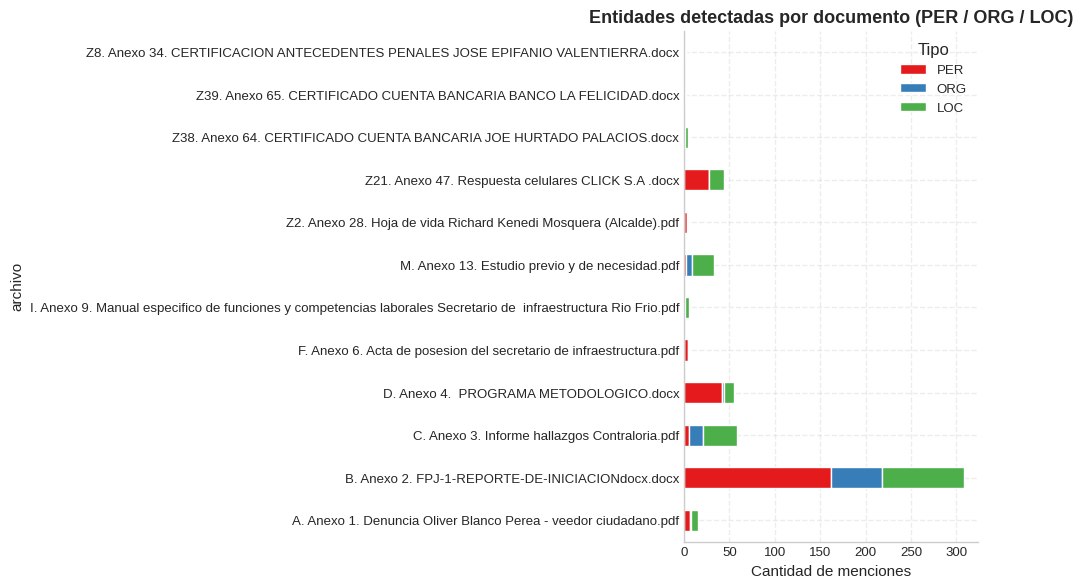

In [ ]:
if not df_entidades.empty:
    print("Entidades por tipo:")
    mostrar_tabla(df_entidades["tipo"].value_counts().to_frame("Cantidad").reset_index().rename(
        columns={"index": "Tipo", "tipo": "Tipo", "count": "Cantidad"}), titulo="Entidades por tipo")

    if "motor_ner" in df_entidades.columns:
        print("\nTrazabilidad: qué motor detectó cada entidad (para poder auditar el origen del dato):")
        mostrar_tabla(
            df_entidades.groupby(["tipo", "motor_ner"]).size().reset_index(name="Cantidad")
            .rename(columns={"tipo": "Tipo", "motor_ner": "Motor de detección"}),
            titulo="Entidades por tipo y motor de detección", columnas_barra=["Cantidad"],
        )

    tabla_entidades_doc = df_entidades.groupby(["archivo", "tipo"]).size().unstack(fill_value=0)
    print("\nEntidades por documento y tipo:")
    mostrar_tabla(tabla_entidades_doc.reset_index().rename(columns={"archivo": "Documento"}),
                  titulo="Entidades por documento y tipo")

    colores_tipo = {"PER": "#e41a1c", "ORG": "#377eb8", "LOC": "#4daf4a"}
    columnas_presentes = [c for c in ["PER", "ORG", "LOC"] if c in tabla_entidades_doc.columns]

    fig, ax = plt.subplots(figsize=(10, 6))
    tabla_entidades_doc[columnas_presentes].plot(
        kind="barh", stacked=True, ax=ax,
        color=[colores_tipo[c] for c in columnas_presentes],
    )
    ax.set_title("Entidades detectadas por documento (PER / ORG / LOC)")
    ax.set_xlabel("Cantidad de menciones")
    ax.legend(title="Tipo")
    fig.tight_layout()
    plt.show()
else:
    print("No se detectaron entidades.")
    tabla_entidades_doc = pd.DataFrame()


## Paso 6b — Resolución de entidades: una persona = una identidad documental

Aquí se corrige el problema de `Richard Kenedi Mosquera` frente a `Lucumi, Richard Kennedi Mosquera Lucumi`. La comparación se hace sobre una representación auxiliar normalizada; **la evidencia siempre conserva la mención original**.

La regla no es simplemente “fuzzy > 90”. Primero se exige compatibilidad de tipo; para personas se busca cobertura de tokens y similitud, permitiendo pequeñas diferencias ortográficas/OCR. Para lugares se compara la forma normalizada y sus tokens, pero se evita crear entidades a partir de palabras genéricas.


In [ ]:
def resolver_personas(textos_unicos, umbral=82):
    """Agrupa variantes de personas con criterios conservadores y trazables."""
    reps = []
    mapping = {}
    for texto in sorted(textos_unicos, key=lambda x: len(tokens_norm(x)), reverse=True):
        mejor, mejor_score = None, 0
        for rep in reps:
            score = similitud_personas(texto, rep)
            ta, tb = set(tokens_norm(texto)), set(tokens_norm(rep))
            # Una variante corta solo puede entrar si todos sus tokens aparecen en la forma larga.
            cobertura = len(ta & tb) / max(1, len(ta))
            if cobertura >= 1.0 and len(ta) >= 2:
                score = max(score, 95)
            if score > mejor_score:
                mejor_score, mejor = score, rep
        if mejor is not None and mejor_score >= umbral:
            mapping[texto] = mejor
        else:
            reps.append(texto)
            mapping[texto] = texto
    return mapping

def resolver_generico(textos_unicos, umbral=88):
    reps, mapping = [], {}
    for texto in sorted(textos_unicos, key=len, reverse=True):
        n = normalizar_comparacion(texto)
        mejor, score_mejor = None, 0
        for rep in reps:
            r = normalizar_comparacion(rep)
            score = fuzz.token_set_ratio(n, r)
            if score > score_mejor:
                score_mejor, mejor = score, rep
        if mejor is not None and score_mejor >= umbral:
            mapping[texto] = mejor
        else:
            reps.append(texto); mapping[texto] = texto
    return mapping

MAPEO_PERSONAS = resolver_personas(df_entidades.loc[df_entidades.tipo == "PER", "texto"].unique().tolist()) if not df_entidades.empty else {}
MAPEO_LOC = resolver_generico(df_entidades.loc[df_entidades.tipo == "LOC", "texto"].unique().tolist()) if not df_entidades.empty else {}
MAPEO_ORG = resolver_generico(df_entidades.loc[df_entidades.tipo == "ORG", "texto"].unique().tolist()) if not df_entidades.empty else {}

# Diccionario experto: siempre prevalece. Las claves se comparan normalizadas.
MAPEO_MANUAL_NORMALIZADO = {
    normalizar_comparacion("Río Frío Chocó"): "Río Frío",
    normalizar_comparacion("Rio Frio Choco"): "Río Frío",
    normalizar_comparacion("Riofrio FRIO CHOCO"): "Río Frío",
    normalizar_comparacion("Richard Kenedi Mosquera Lucumi"): "Richard Kenedi Mosquera",
    normalizar_comparacion("Lucumi, Richard Kennedi Mosquera Lucumi"): "Richard Kenedi Mosquera",
    normalizar_comparacion("Richard Kenedi"): "Richard Kenedi Mosquera",
}

def canonicalizar(texto, tipo):
    clave = normalizar_comparacion(texto)
    if clave in MAPEO_MANUAL_NORMALIZADO:
        return MAPEO_MANUAL_NORMALIZADO[clave], "manual"
    if tipo == "FECHA":
        # Agrupa fechas escritas distinto (ej. "28 de junio de 2023" vs "28/06/2023") bajo
        # su forma ISO "AAAA-MM-DD", para poder ordenarlas y contarlas correctamente.
        iso = normalizar_fecha_a_iso(texto)
        return (iso, "fecha-normalizada") if iso else (texto, "sin agrupar")
    if tipo == "PER":
        return MAPEO_PERSONAS.get(texto, texto), "automático-persona" if MAPEO_PERSONAS.get(texto, texto) != texto else "sin agrupar"
    if tipo == "LOC":
        return MAPEO_LOC.get(texto, texto), "automático-lugar" if MAPEO_LOC.get(texto, texto) != texto else "sin agrupar"
    if tipo == "ORG":
        return MAPEO_ORG.get(texto, texto), "automático-organización" if MAPEO_ORG.get(texto, texto) != texto else "sin agrupar"
    return texto, "sin agrupar"

if not df_entidades.empty:
    can = df_entidades.apply(lambda r: canonicalizar(r.texto, r.tipo), axis=1)
    df_entidades["entidad_canonica"] = can.apply(lambda x: x[0])
    df_entidades["metodo_agrupacion"] = can.apply(lambda x: x[1])

print("Ejemplos de normalización de personas:")
for x in ["Richard Kenedi Mosquera", "Richard Kenedi Mosquera Lucumi", "Lucumi, Richard Kennedi Mosquera Lucumi"]:
    print(f"  {x} -> {normalizar_comparacion(x)} -> {canonicalizar(x, 'PER')[0]}")


Ejemplos de normalización de personas:
  Richard Kenedi Mosquera -> richard kenedi mosquera -> Richard Kenedi Mosquera
  Richard Kenedi Mosquera Lucumi -> richard kenedi mosquera lucumi -> Richard Kenedi Mosquera
  Lucumi, Richard Kennedi Mosquera Lucumi -> lucumi richard kennedi mosquera lucumi -> Richard Kenedi Mosquera


### 6b.1 — Efecto de la resolución de identidades (antes vs. después)

Efecto de la consolidación de variantes:


,Variantes_originales,Identidades_consolidadas
tipo,,
FECHA,26,21
LOC,50,37
ORG,26,23
PER,39,18


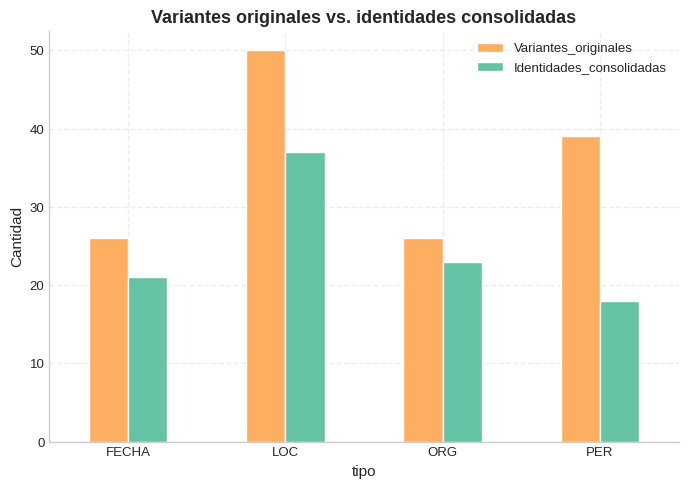

In [ ]:
if not df_entidades.empty:
    resumen_resolucion = (
        df_entidades.groupby("tipo")
        .agg(
            Variantes_originales=("texto", "nunique"),
            Identidades_consolidadas=("entidad_canonica", "nunique"),
        )
    )
    print("Efecto de la consolidación de variantes:")
    display(resumen_resolucion)

    fig, ax = plt.subplots(figsize=(7, 5))
    resumen_resolucion.plot(kind="bar", ax=ax, color=["#fdae61", "#66c2a5"])
    ax.set_title("Variantes originales vs. identidades consolidadas")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    plt.show()
else:
    print("No hay entidades para consolidar.")


## Paso 6c — Cronología de hechos

Se asocian las fechas detectadas (Paso 6) con la oración exacta ("hecho") en la que aparecen, y se
ordenan cronológicamente. Esto responde directamente a "qué se dice que pasó, y cuándo" — una
cronología, no solo una lista de fechas sueltas.

Hechos con fecha identificada: 33


Documento,Fecha (ISO),Fecha (texto),Hecho
M. Anexo 13. Estudio previo y de necesidad.pdf,2015-05-01,mayo de 2015,"REPÚBLICA DE COLOMBIA DEPARTAMENTO DE CHOCO MUNICIPIO DE RIO FRIO ESTUDIO PREVIO Y DE NECESIDAD PARA DETERMINAR LA CONVENIENCIA Y OPORTUNIDAD DE LA CONTRATACION DE LAS OBRAS PARA LA CONSTRUCCIÓN DE LA E.S.E. HOSPITAL DE PRIMER NIVEL SAN LAZARO DEL MUNICIPIO DE RÍO FRÍO CHOCO. 18 de noviembre de 2021 De conformidad con lo dispuesto en el Decreto 1082 de mayo de 2015, en desarrollo de los numerales 8 y 12 del artículo 25 de la ley 80 de 1993, se analiza la conveniencia del objeto a contratar y el análisis de los documentos y estudios previos, así: 1.Descripcion de la necesidad que se pretende satisfacer: El municipio de Río Frío carece de un hospital de primer nivel que satisfaga las demandas en materia de prestación de los servicios esenciales de salud que requieren los habitantes del municipio, lo que obliga a que la población deba realizar desplazamientos de más de 24 horas hasta la ciudad de Quibdó en donde se encuentra localizado el hospital más cercano a Río Frío para poder acceder a una atención médica cuando es requerida."
C. Anexo 3. Informe hallazgos Contraloria.pdf,2020-01-01,1 de enero de 2020,"5-36 Barrio La Cruz, Río Frío – Chocó Dirección Forma de Vinculación Elección Popular 31 de Período en el Cargo: Desde 1 de enero de 2020 Hasta diciembre de 2023 Explique las razones por la cuales considera que esta persona ha participado en los hechos: PRINCIPIOS, FUNDAMENTOS Y ASPECTOS GENERALES PARA LAS AUDITORÍAS EN LA CGR Fungía como Alcalde Municipal desde el 1 de enero de 2020 al 31 diciembre de 2023, en esta calidad, suscribió como contratante el contrato de obra, Nro."
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,2020-01-13,13 de enero de 2020,0026 del 13 de enero de 2020.
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,2021-11-01,1 de noviembre de 2021,"AIFIT Río Frío - Chocó CLICK S.A. Soluciones en Comunicaciones En atención a la solicitud presentada por usted, a continuación, me permito enviar la información que reposa en nuestro sistema en cuanto a abonados celulares registrados a nombre los ciudadanos relacionados más adelante y el extracto de llamadas entrantes y salientes en el periodo comprendido entre el 1 de noviembre de 2021 y el 30 de julio de 2023, de cada una de estas líneas celulares, así: Se anexa en archivo digital en formato excel las sábanas de llamadas entrantes y salientes, al igual que los datos biográficos de los abonados antes mencionados."
M. Anexo 13. Estudio previo y de necesidad.pdf,2021-11-15,15 de noviembre de 2021,049 del 15 de noviembre de 2021. 11.
M. Anexo 13. Estudio previo y de necesidad.pdf,2021-11-18,18 de noviembre de 2021,"REPÚBLICA DE COLOMBIA DEPARTAMENTO DE CHOCO MUNICIPIO DE RIO FRIO ESTUDIO PREVIO Y DE NECESIDAD PARA DETERMINAR LA CONVENIENCIA Y OPORTUNIDAD DE LA CONTRATACION DE LAS OBRAS PARA LA CONSTRUCCIÓN DE LA E.S.E. HOSPITAL DE PRIMER NIVEL SAN LAZARO DEL MUNICIPIO DE RÍO FRÍO CHOCO. 18 de noviembre de 2021 De conformidad con lo dispuesto en el Decreto 1082 de mayo de 2015, en desarrollo de los numerales 8 y 12 del artículo 25 de la ley 80 de 1993, se analiza la conveniencia del objeto a contratar y el análisis de los documentos y estudios previos, así: 1.Descripcion de la necesidad que se pretende satisfacer: El municipio de Río Frío carece de un hospital de primer nivel que satisfaga las demandas en materia de prestación de los servicios esenciales de salud que requieren los habitantes del municipio, lo que obliga a que la población deba realizar desplazamientos de más de 24 horas hasta la ciudad de Quibdó en donde se encuentra localizado el hospital más cercano a Río Frío para poder acceder a una atención médica cuando es requerida."
C. Anexo 3. Informe hallazgos Contraloria.pdf,2022-01-29,29 de enero de 2022,"RF-LP-1SUB/2022 Junio 30 de Período en el Cargo: Desde Febrero 1 de 2022 Hasta 2023 Explique las razones por la cuales 

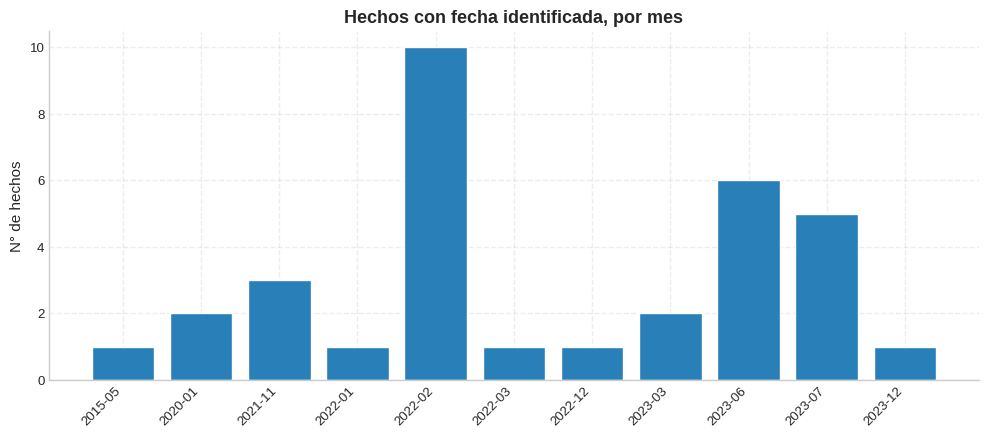

In [ ]:
if not df_entidades.empty and (df_entidades["tipo"] == "FECHA").any():
    df_fechas = df_entidades[df_entidades["tipo"] == "FECHA"].copy()
    df_fechas = df_fechas.rename(columns={"archivo": "Documento", "texto": "Fecha (texto)", "oracion_contexto": "Hecho"})
    df_fechas["Fecha (ISO)"] = df_fechas["entidad_canonica"]  # ya normalizada en el Paso 6b

    df_cronologia = (
        df_fechas[["Documento", "Fecha (ISO)", "Fecha (texto)", "Hecho"]]
        .drop_duplicates(subset=["Documento", "Fecha (ISO)", "Hecho"])
        .sort_values("Fecha (ISO)", na_position="last")
        .reset_index(drop=True)
    )

    print(f"Hechos con fecha identificada: {len(df_cronologia)}")
    mostrar_tabla(df_cronologia, titulo="Cronología de hechos (ordenada por fecha)")

    df_cronologia_validas = df_cronologia[df_cronologia["Fecha (ISO)"].notna()].copy()
    if not df_cronologia_validas.empty:
        df_cronologia_validas["Año-mes"] = df_cronologia_validas["Fecha (ISO)"].str.slice(0, 7)
        conteo_mes = df_cronologia_validas.groupby("Año-mes").size().sort_index()
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.bar(conteo_mes.index, conteo_mes.values, color="#2980b9")
        ax.set_title("Hechos con fecha identificada, por mes")
        ax.set_ylabel("N° de hechos")
        plt.xticks(rotation=45, ha="right")
        fig.tight_layout()
        plt.show()

    n_sin_iso = df_cronologia["Fecha (ISO)"].isna().sum()
    if n_sin_iso:
        print(f"Nota: {n_sin_iso} fecha(s) se detectaron en el texto pero no se lograron interpretar "
              f"a un formato ordenable (aparecen al final de la tabla).")
else:
    print("No se identificaron fechas explícitas en los documentos.")
    df_cronologia = pd.DataFrame(columns=["Documento", "Fecha (ISO)", "Fecha (texto)", "Hecho"])


# PARTE I — Caracterización lingüística de cada documento

Esta sección responde primero: **¿de qué habla cada documento?** (dimensiones, perfil gramatical,
términos clave, quién/qué se menciona y cuántas veces). La Parte II (más abajo) responde **¿qué se
dice de cada persona?**, apoyándose en lo que se construye aquí.

## Paso 7.0 — Perfil gramatical de cada documento (categorías lingüísticas)

Composición gramatical de cada documento: qué proporción de sus palabras son sustantivos, verbos,
adjetivos, etc. Esto es parte de la caracterización *lingüística* propiamente dicha (no solo
temática), y ayuda a distinguir, por ejemplo, un documento enumerativo/formulario (más sustantivos)
de uno narrativo (más verbos).

Perfil gramatical de cada documento (% de palabras por categoría):


Documento,Total palabras analizadas,Sustantivos,Nombres propios,Verbos,Verbos auxiliares,Adjetivos,Adverbios,Pronombres
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,97,21.60,24.70,5.20,0.00,18.60,2.10,2.10
D. Anexo 4. PROGRAMA METODOLOGICO.docx,1134,21.30,29.50,6.30,1.20,7.40,0.90,2.10
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,77,22.10,23.40,3.90,1.30,6.50,1.30,1.30
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,785,28.00,7.80,8.40,1.00,7.60,0.90,3.90
M. Anexo 13. Estudio previo y de necesidad.pdf,2121,27.20,8.40,4.90,1.70,9.10,1.40,3.40
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,1206,13.30,38.70,1.90,0.00,22.30,2.10,0.40
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,76,25.00,18.40,5.30,1.30,5.30,1.30,1.30
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,670,20.00,40.00,1.60,1.00,9.60,1.30,1.00
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,227,21.10,16.30,8.40,0.90,5.30,1.30,5.30
C. Anexo 3. Informe hallazgos Contraloria.pdf,2275,24.00,21.60,4.40,1.00,8.40,1.00,2.60


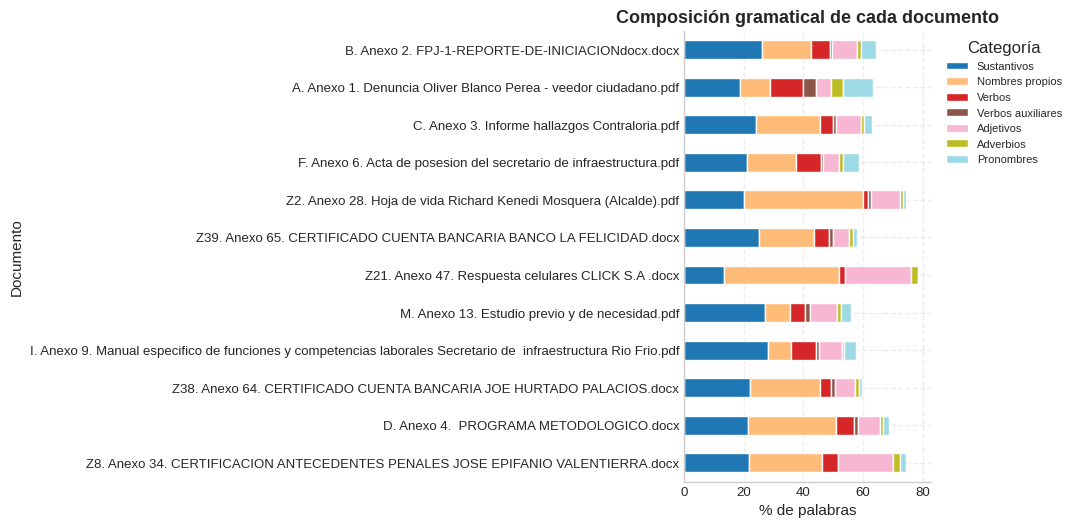

Lectura orientativa: una proporción alta de sustantivos/nombres propios suele indicar texto descriptivo o enumerativo (formularios, certificaciones, listados); una proporción más alta de verbos suele indicar texto narrativo (relatos de hechos, declaraciones).


In [ ]:
ETIQUETAS_POS_LEGIBLES = {
    "NOUN": "Sustantivos", "PROPN": "Nombres propios", "VERB": "Verbos", "AUX": "Verbos auxiliares",
    "ADJ": "Adjetivos", "ADV": "Adverbios", "PRON": "Pronombres", "DET": "Determinantes",
    "ADP": "Preposiciones", "CCONJ": "Conjunciones coord.", "SCONJ": "Conjunciones subord.",
    "NUM": "Números",
}
CATEGORIAS_POS_PRINCIPALES = ["NOUN", "PROPN", "VERB", "AUX", "ADJ", "ADV", "PRON"]

# Se reprocesa el texto con NER y parser desactivados: es más rápido y aquí solo interesa la
# categoría gramatical (POS) de cada palabra, no las entidades ni la sintaxis.
docs_pos = list(nlp.pipe(df["texto_normalizado"], disable=["ner", "parser", "lemmatizer"]))

filas_pos = []
for archivo, doc_spacy in zip(df["archivo"], docs_pos):
    conteo = Counter(tok.pos_ for tok in doc_spacy if tok.is_alpha)
    total_palabras = sum(conteo.values())
    fila = {"Documento": archivo, "Total palabras analizadas": total_palabras}
    for categoria in CATEGORIAS_POS_PRINCIPALES:
        etiqueta = ETIQUETAS_POS_LEGIBLES[categoria]
        n = conteo.get(categoria, 0)
        fila[etiqueta] = round(100 * n / total_palabras, 1) if total_palabras else 0.0
    filas_pos.append(fila)

df_perfil_gramatical = pd.DataFrame(filas_pos)

print("Perfil gramatical de cada documento (% de palabras por categoría):")
mostrar_tabla(
    df_perfil_gramatical, titulo="Perfil gramatical por documento (%)",
    columnas_barra=[ETIQUETAS_POS_LEGIBLES[c] for c in CATEGORIAS_POS_PRINCIPALES],
)

columnas_grafico = [ETIQUETAS_POS_LEGIBLES[c] for c in CATEGORIAS_POS_PRINCIPALES]
fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(df_perfil_gramatical))))
df_perfil_gramatical.set_index("Documento")[columnas_grafico].plot(
    kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("% de palabras")
ax.set_title("Composición gramatical de cada documento")
ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

print(
    "Lectura orientativa: una proporción alta de sustantivos/nombres propios suele indicar texto "
    "descriptivo o enumerativo (formularios, certificaciones, listados); una proporción más alta "
    "de verbos suele indicar texto narrativo (relatos de hechos, declaraciones)."
)


## Paso 7.1 — Dimensiones, contenido y entidades de cada documento

Ficha objetiva de cada documento combinando datos ya calculados en pasos anteriores: páginas,
palabras, oraciones, términos clave (TF-IDF, Paso 3.1) y entidades detectadas y filtradas por
calidad (Paso 6). Esta ficha es la que después se le entrega al LLM como contexto verificable
(Paso 11), en vez de pedirle que "adivine" a partir del texto completo. También se muestra, para
todo el expediente, quién y qué se menciona y cuántas veces.

Ficha objetiva de cada documento (páginas, palabras, términos clave y entidades ya filtradas):


Documento,N° páginas,N° palabras,N° oraciones,N° tokens
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,nan,99,5,118
D. Anexo 4. PROGRAMA METODOLOGICO.docx,nan,1223,36,1326
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,nan,84,4,93
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,2.00,839,39,949
M. Anexo 13. Estudio previo y de necesidad.pdf,6.00,2227,72,2451
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,nan,2674,60,2732
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,nan,84,4,94
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,6.00,846,42,940
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,1.00,235,10,256
C. Anexo 3. Informe hallazgos Contraloria.pdf,9.00,2455,103,2773


Documento,Términos clave (TF-IDF),Personas mencionadas,Organizaciones mencionadas,Lugares mencionados
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,"certificación (0.42), sistema (0.34), fecha (0.31), documento (0.27), identidad (0.24), jose (0.21), funcionario (0.21), policia (0.19)",José Epifanio Valentierra Asprilla (1),,Sistema Académico (1)
D. Anexo 4. PROGRAMA METODOLOGICO.docx,"delgado (0.35), cabezas (0.30), rosendo (0.30), lucumí (0.26), cabo (0.23), mena (0.23), rosa (0.23), mora (0.23)","Rosendo Cabezas Delgado Subintendente Área Investigativa (13), Joe Hurtado Palacios (8), Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación (8), Richard Kenedi Mosquera (4), Pedro Murillo Rentería Plazo (3)","Resolución (1), Colombia Compra Eficiente (1)","hospital San Lázaro de Riofrío (3), República de Panamá (2), Contraloría (1), Perito (1), Alcaldía de Riofrío (1)"
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,"número (0.55), nit (0.30), república (0.30), empresa (0.30), palacios (0.27), joe (0.27), colombia (0.25), hurtado (0.25)",Joe Hurtado Palacios (1),,República de Panamá (3)
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,"verificar (0.39), contrato (0.35), ejecución (0.34), servicio (0.27), cumplimiento (0.27), profesional (0.22), bien (0.22), obra (0.21)",COMPETENCIAS LABORALES (1),,"hospital San Lázaro de Riofrío (1), Rio frio Chocó (1), Departamento de Bolívar (1), Arquitectura (1)"
M. Anexo 13. Estudio previo y de necesidad.pdf,"contrato (0.38), obra (0.37), municipio (0.24), valor (0.23), técnico (0.23), ciento (0.21), cuantificación (0.18), contado (0.18)","Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación (1), SECRETARIO DE (1)","Contratar (1), Constitución Política (1), RePública de Colombia (1), Fluctuación (1), Estudios de costos (1)","Rio frio Chocó (11), Cuantificación (3), hospital San Lázaro de Riofrío (2), Covid (1), Quibdó (1)"
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,"llamado (0.55), propiedad (0.46), celular (0.38), señor (0.28), saliente (0.27), entrante (0.22), peinado (0.13), cabello (0.13)","DE PROPIEDAD DEL SEÑOR PEDRO (20), GUSTAVO MARQUEZ Asistente (1), Pedro Murillo Rentería Plazo (1), Richard Kenedi Mosquera (1), José Epifanio Valentierra Asprilla (1)",Comunicaciones (1),"INICIO (9), Rio frio Chocó (3), SALIENTES (2), Quibdó (1), AIFIT (1)"
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,"número (0.57), consorcio (0.35), nit (0.32), pedro (0.29), murillo (0.26), mes (0.26), choco (0.24), certificado (0.24)",Pedro Murillo Rentería Plazo (1),,Rio frio Chocó (1)
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,"año (0.32), fecha (0.32), país (0.30), mes (0.29), contrato (0.25), experiencia (0.23), rio (0.21), frio (0.21)","Richard Kenedi Mosquera (1), PARA EJERCER (1), JEFE DE (1)",,Rio frio Chocó (1)
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,"secretario (0.28), infraestructura (0.28), alcalde (0.28), ley (0.23), cargo (0.23), acta (0.23), río (0.21), presentar (0.21)","SECRETARIO DE (2), José Epifanio Valentierra Asprilla (1), Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación (1)",,Rio frio Chocó (2)
C. Anexo 3. Informe hallazgos Contraloria.pdf,"obra (0.34), hallazgo (0.25), auditoría (0.24), cgr (0.24), general (0.20), acta (0.18), fundamentos (0.17), valor (0.17)","Pedro Murillo Rentería Plazo (2), Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación (1), José Epifanio Valentierra Asprilla (1), Justo Honrado Caballero Ejecutivo (1)","Contraloría Delegada para Investigaciones (4), Contraloría General de la República (3), Consorcio Obras La Economía S.A.S. (2), Auditor Líder (1), Sociedad de Economía Mixta (1)","Rio frio Chocó (18), hospital San Lázaro de Riofrío (4), Río Frío (3), Barrio La Cruz (2), Gerencia Departame

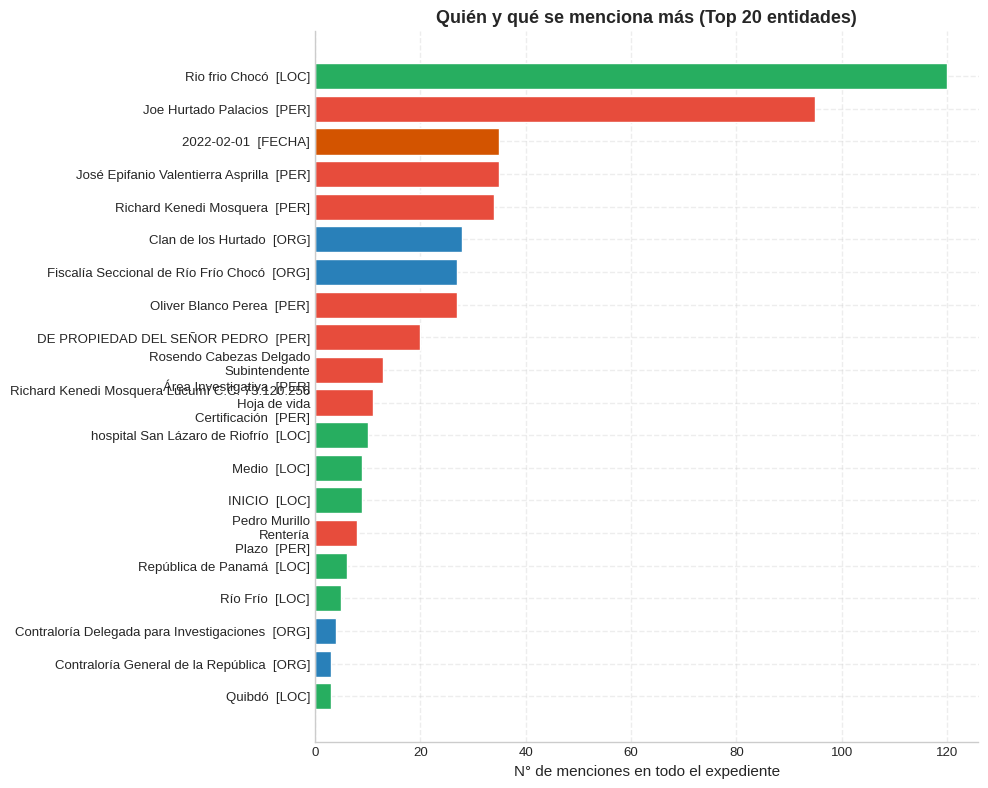

Tabla completa — quién/qué se menciona y cuántas veces:


Tipo,Entidad,Menciones
LOC,Rio frio Chocó,120
PER,Joe Hurtado Palacios,95
FECHA,2022-02-01,35
PER,José Epifanio Valentierra Asprilla,35
PER,Richard Kenedi Mosquera,34
ORG,Clan de los Hurtado,28
ORG,Fiscalía Seccional de Río Frío Chocó,27
PER,Oliver Blanco Perea,27
PER,DE PROPIEDAD DEL SEÑOR PEDRO,20
PER,Rosendo Cabezas Delgado Subintendente Área Investigativa,13


In [ ]:
def entidades_top_por_documento(archivo, tipo, top_n=5):
    """Top entidades de un tipo (PER/ORG/LOC) para un documento, ya consolidadas (entidad_canonica),
    con el número de menciones de cada una."""
    if df_entidades.empty:
        return []
    sub = df_entidades[(df_entidades["archivo"] == archivo) & (df_entidades["tipo"] == tipo)]
    if sub.empty:
        return []
    conteo = sub["entidad_canonica"].value_counts().head(top_n)
    return [f"{nombre} ({n})" for nombre, n in conteo.items()]


filas_caracterizacion = []
for _, fila in df.iterrows():
    archivo = fila["archivo"]
    top_terminos = df_top_terminos.loc[df_top_terminos["Documento"] == archivo, "Términos clave (TF-IDF)"]
    filas_caracterizacion.append({
        "Documento": archivo,
        "N° páginas": fila.get("n_paginas", None),
        "N° palabras": fila.get("n_palabras_crudo", None),
        "N° oraciones": fila["n_oraciones"],
        "N° tokens": fila["n_tokens"],
        "Términos clave (TF-IDF)": top_terminos.iloc[0] if not top_terminos.empty else "",
        "Personas mencionadas": ", ".join(entidades_top_por_documento(archivo, "PER")),
        "Organizaciones mencionadas": ", ".join(entidades_top_por_documento(archivo, "ORG")),
        "Lugares mencionados": ", ".join(entidades_top_por_documento(archivo, "LOC")),
    })

df_caracterizacion_base = pd.DataFrame(filas_caracterizacion)

print("Ficha objetiva de cada documento (páginas, palabras, términos clave y entidades ya filtradas):")
mostrar_tabla(
    df_caracterizacion_base[["Documento", "N° páginas", "N° palabras", "N° oraciones", "N° tokens"]],
    titulo="Dimensiones de cada documento",
    columnas_barra=["N° palabras", "N° oraciones"],
)
mostrar_tabla(
    df_caracterizacion_base[
        ["Documento", "Términos clave (TF-IDF)", "Personas mencionadas",
         "Organizaciones mencionadas", "Lugares mencionados"]
    ],
    titulo="Contenido y entidades destacadas de cada documento",
)

# --- Gráfico: quién y qué se menciona, y cuántas veces (a nivel de todo el expediente) ---
if not df_entidades.empty:
    top_entidades_global = (
        df_entidades.groupby(["tipo", "entidad_canonica"]).size()
        .reset_index(name="Menciones")
        .sort_values("Menciones", ascending=False)
    )
    top_20 = top_entidades_global.head(20).iloc[::-1]  # invertido para que el barh quede de mayor a menor arriba
    colores_tipo_grafico = top_20["tipo"].map(
        {"PER": "#e74c3c", "ORG": "#2980b9", "LOC": "#27ae60", "FECHA": "#d35400"}
    ).fillna("#7f8c8d")  # respaldo por si aparece un tipo de entidad no contemplado en el mapa

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_20["entidad_canonica"] + "  [" + top_20["tipo"] + "]", top_20["Menciones"], color=colores_tipo_grafico)
    ax.set_xlabel("N° de menciones en todo el expediente")
    ax.set_title("Quién y qué se menciona más (Top 20 entidades)")
    fig.tight_layout()
    plt.show()

    print("Tabla completa — quién/qué se menciona y cuántas veces:")
    mostrar_tabla(
        top_entidades_global.rename(columns={"tipo": "Tipo", "entidad_canonica": "Entidad"}),
        titulo="Menciones por entidad (todo el expediente)",
        columnas_barra=["Menciones"],
    )


# PARTE II — ¿Qué se dice de cada persona?

## Paso 8 — ¿Qué se dice de cada persona? (evidencia textual)

Esta tabla es la base de todo el análisis por persona. **No se limita a contar menciones**: para
cada persona y documento se conserva la oración exacta y una ventana contextual (±1 oración).

La extracción automática **no afirma por sí sola que la persona realizó una conducta**: una
persona puede aparecer como víctima, denunciante, investigada, testigo, funcionaria, tercera o
simplemente ser mencionada — la categorización de ese rol se hace en el Paso 12, con evidencia,
no por la sola aparición del nombre.

In [ ]:
PERSONAS = df_entidades[df_entidades["tipo"] == "PER"].copy() if not df_entidades.empty else pd.DataFrame()

def contexto_ampliado(oraciones, indice, ventana=1):
    ini = max(0, indice - ventana)
    fin = min(len(oraciones), indice + ventana + 1)
    return " ".join(oraciones[ini:fin])

filas_que_se_dice = []
for _, e in PERSONAS.iterrows():
    fila_doc = df[df["archivo"] == e["archivo"]].iloc[0]
    oraciones = fila_doc["oraciones"]
    idx = max(0, int(e["n_oracion"]) - 1)
    filas_que_se_dice.append({
        "Documento": e["archivo"],
        "Persona": e["entidad_canonica"],
        "Mención original": e["texto"],
        "Oración exacta": e["oracion_contexto"],
        "Contexto ±1 oración": contexto_ampliado(oraciones, idx, ventana=1),
        "N° oración": e["n_oracion"],
        "Método agrupación": e["metodo_agrupacion"],
    })

df_que_se_dice_personas = pd.DataFrame(filas_que_se_dice).drop_duplicates(
    subset=["Documento", "Persona", "Oración exacta"]
)

print(f"Registros de contexto de personas: {len(df_que_se_dice_personas)}")
display(df_que_se_dice_personas.head(20))

# Resumen por persona/documento: cuántas evidencias distintas existen.
df_resumen_personas = (
    df_que_se_dice_personas.groupby(["Documento", "Persona"], as_index=False)
    .agg(Menciones=("Mención original", "count"), Evidencias_textuales=("Oración exacta", lambda s: " | ".join(pd.unique(s))))
)
display(df_resumen_personas.head(20))


Registros de contexto de personas: 68


,Documento,Persona,Mención original,Oración exacta,Contexto ±1 oración,N° oración,Método agrupación
0,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENAL...,José Epifanio Valentierra Asprilla,JOSE EPIFANIO,FICTICIO – USO ACADÉMICO\nSIN VALIDEZ LEGAL\nL...,CERTIFICACIÓN DE ANTECEDENTES PENALES\nDOCUMEN...,2,automático-persona
1,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Rosendo Cabezas Delgado\nSubintendente\nÁrea I...,Rosendo Cabezas Delgado\nFGN,Actividades a desarrollar:\nORDENES A POLICIA ...,PROGRAMA METODOLOGICO\nDepartamento: Chocó Mun...,2,automático-persona
2,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Rosa Mena Mora\n Intendente\nÁrea Investigativa,Rosa Mena Mora\n Intendente\nÁrea Investigativa,Actividades a desarrollar:\nORDENES A POLICIA ...,PROGRAMA METODOLOGICO\nDepartamento: Chocó Mun...,2,sin agrupar
4,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Richard Kenedi Mosquera,Richard Kenedi Mosquera Lucumí,Órgano de prueba\nElemento material probatorio...,Determinación de las actividades a realizar po...,5,manual
5,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Pedro Murillo\nRentería\nPlazo,Pedro Murillo Renteria,El contrato fue asignado a un consorcio repres...,Órgano de prueba\nElemento material probatorio...,6,automático-persona
6,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Joe Hurtado Palacios,Joe Hurtado Palacios,Dice que detrás de esta situación esta el “Cla...,"Indica que, a mediados de marzo de 2022, apare...",9,sin agrupar
7,D. Anexo 4. PROGRAMA METODOLOGICO.docx,José Epifanio Valentierra Asprilla,José Epifanio Valentierra Asprilla,En cuanto al dinero menciona que un porcentaje...,Dice que detrás de esta situación esta el “Cla...,10,sin agrupar
8,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Joe Hurtado Palacios,Joe Hurtado Palacios,En cuanto al dinero menciona que un porcentaje...,Dice que detrás de esta situación esta el “Cla...,10,sin agrupar
9,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Richard Kenedi Mosquera Lucumí C.C. 73.120.256...,Mosquera Lucumí,Plantea hechos de corrupción en la administrac...,Que para comunicarse con ellos lo hace a travé...,13,automático-persona
10,D. Anexo 4. PROGRAMA METODOLOGICO.docx,Justo Honrado Caballero\n Ejecutivo,Justo Honrado Caballero\n Ejecutivo,Contraloría delegada sector focalizado\nJusto ...,Plantea hechos de corrupción en la administrac...,14,sin agrupar


,Documento,Persona,Menciones,Evidencias_textuales
0,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,Joe Hurtado Palacios,4,Por eso quiero por medio de este documento den...
1,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,José Epifanio Valentierra Asprilla,1,"De la plata del contrato, se dice que los inge..."
2,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,Pedro Murillo\nRentería\nPlazo,1,"Pero este año ha sido el descaro más grande, p..."
3,A. Anexo 1. Denuncia Oliver Blanco Perea - vee...,Richard Kenedi Mosquera,1,"El alcalde Richard Kenedi Mosquera Lucumi, tam..."
4,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Joe Hurtado Palacios,3,Igualmente manifiesta el denunciante de la pos...
5,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,José Epifanio Valentierra Asprilla,1,"Así mismo, en la denuncia se menciona que el a..."
6,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Oliver Blanco Perea,2,SÍNTESIS DE LOS HECHOS\nFecha de los hechos\nF...
7,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Richard Kenedi Mosquera,1,"Así mismo, en la denuncia se menciona que el a..."
8,C. Anexo 3. Informe hallazgos Contraloria.pdf,José Epifanio Valentierra Asprilla,1,RF-LP-1SUB/2022\nSI ES PERSONA NATURAL INDIQUE...
9,C. Anexo 3. Informe hallazgos Contraloria.pdf,Justo Honrado Caballero\n Ejecutivo,1,NOMBRE Y FIRMA\nRol en la actuación de vigilan...


Menciones totales por persona (todo el expediente):


,Menciones
Persona,
Joe Hurtado Palacios,13
José Epifanio Valentierra Asprilla,9
Rosendo Cabezas Delgado\nSubintendente\nÁrea Investigativa,8
Pedro Murillo\nRentería\nPlazo,8
Richard Kenedi Mosquera,8
Richard Kenedi Mosquera Lucumí C.C. 73.120.256\nHoja de vida\nCertificación,6
SECRETARIO DE,3
Oliver Blanco Perea,2
Justo Honrado Caballero\n Ejecutivo,2


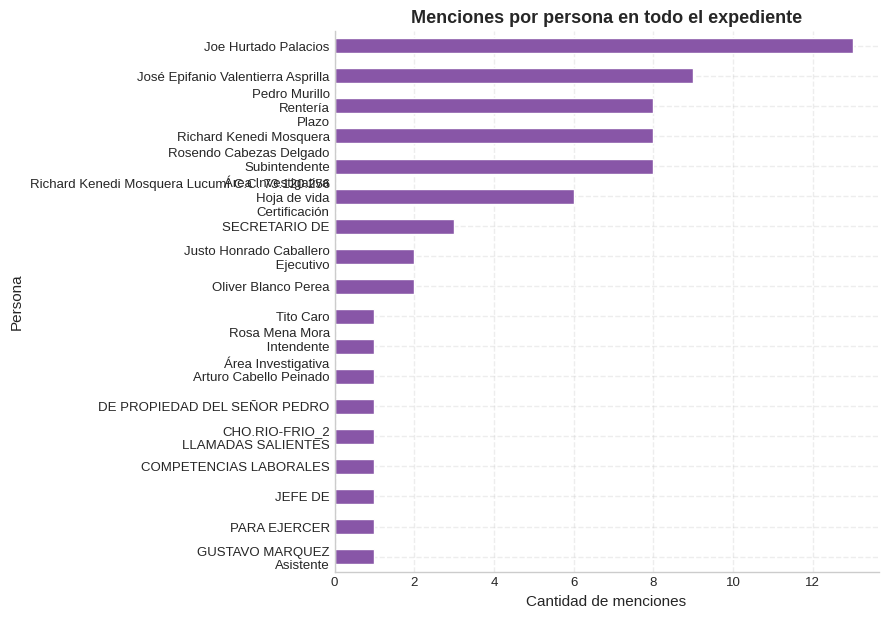


Menciones por persona y documento:


Documento,A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,C. Anexo 3. Informe hallazgos Contraloria.pdf,D. Anexo 4. PROGRAMA METODOLOGICO.docx,F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,M. Anexo 13. Estudio previo y de necesidad.pdf,Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx
Persona,,,,,,,,,,,,
Arturo Cabello Peinado,0,0,0,0,0,0,0,0,1,0,0,0
CHO.RIO-FRIO_2\nLLAMADAS SALIENTES,0,0,0,0,0,0,0,0,1,0,0,0
COMPETENCIAS LABORALES,0,0,0,0,0,1,0,0,0,0,0,0
DE PROPIEDAD DEL SEÑOR PEDRO,0,0,0,0,0,0,0,0,1,0,0,0
GUSTAVO MARQUEZ\nAsistente,0,0,0,0,0,0,0,0,1,0,0,0
JEFE DE,0,0,0,0,0,0,0,1,0,0,0,0
Joe Hurtado Palacios,4,3,0,4,0,0,0,0,1,1,0,0
José Epifanio Valentierra Asprilla,1,1,1,3,1,0,0,0,1,0,0,1
Justo Honrado Caballero\n Ejecutivo,0,0,1,1,0,0,0,0,0,0,0,0


In [ ]:
if not df_que_se_dice_personas.empty:
    conteo_menciones = df_que_se_dice_personas.groupby("Persona").size().sort_values(ascending=False)
    print("Menciones totales por persona (todo el expediente):")
    display(conteo_menciones.to_frame("Menciones"))

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(conteo_menciones))))
    conteo_menciones.sort_values().plot(kind="barh", ax=ax, color="#8856a7")
    ax.set_title("Menciones por persona en todo el expediente")
    ax.set_xlabel("Cantidad de menciones")
    fig.tight_layout()
    plt.show()

    tabla_persona_doc = df_que_se_dice_personas.groupby(["Persona", "Documento"]).size().unstack(fill_value=0)
    print("\nMenciones por persona y documento:")
    display(tabla_persona_doc)
else:
    print("No se detectaron menciones de personas.")


## Paso 8b — Cargo o calidad de cada persona (detección automática por patrones)

Antes esta celda agrupaba las menciones con K-Means sobre embeddings, sin nombres reales
("Grupo 1", "Grupo 2"...). Se reemplaza por algo más útil para un expediente: identificar, para
cada persona y cada documento, **qué cargo o calidad se menciona cerca de su nombre** (alcalde,
secretario de despacho, representante legal, fiscal, investigador, particular, veedor
ciudadano...).

**Es reutilizable, no está armado a mano para este caso puntual.** El método busca, en un radio de
texto alrededor de cada mención de la persona, coincidencias contra un diccionario **genérico** de
cargos y calidades típicas de documentos administrativos, judiciales y de investigación en
español (`PATRONES_CARGO`, abajo). Ese diccionario no menciona a "Río Frío", "Hurtado" ni ningún
nombre propio del caso — sirve igual para cualquier otro expediente. Si en un caso nuevo aparece un
cargo que no está en la lista, basta con agregar una línea al diccionario; no hay que tocar el
resto del código.

Si en un documento puntual no se menciona ningún cargo cerca del nombre de la persona, esa
combinación persona-documento queda como **"Tercero / colateral"** — no se excluye a nadie, pero
tampoco se le inventa un cargo que el texto no respalda. La categoría de una misma persona puede
variar de un documento a otro (por ejemplo: figura como "Secretario de despacho" en el acta donde
toma posesión, pero como "Tercero / colateral" en un documento que solo la nombra de pasada) — es
evidencia real de cada documento, no una etiqueta fija por persona.

El resultado (`df_categoria_personas`, a nivel persona-documento, y `df_persona_categoria`,
agregado por persona) es la base tanto de la tabla del Paso 12 como del diagrama de Sankey del
dashboard (Paso 15).

**Limitación conocida:** en bloques de firma con diseño de columnas (dos personas y sus cargos
lado a lado, como en un acta de posesión), la extracción de texto de un PDF a veces intercala las
columnas y la cercanía en caracteres deja de reflejar la posición visual real. Cuando un documento
tiene varias oraciones de evidencia para la misma persona, el resto suele corregirlo por mayoría —
aun así, conviene revisar la columna `Evidencia_cargo` antes de dar una categoría por buena.


In [ ]:
import re
from collections import Counter

# ----------------------------------------------------------------------------------------------
# Diccionario GENERAL de cargos/calidades típicas en documentos administrativos, judiciales y de
# investigación en español. No menciona nombres propios ni entidades de ningún caso puntual, así
# que sirve igual para un expediente distinto. Para ampliarlo, basta con agregar una tupla más.
# ----------------------------------------------------------------------------------------------
PATRONES_CARGO = [
    ("Alcalde/Alcaldesa",               r"alcalde(?:sa)?(?:\s+municipal)?"),
    ("Gobernador/Gobernadora",          r"gobernador(?:a)?"),
    ("Concejal",                        r"concejal(?:es)?"),
    ("Secretario/a de despacho",        r"secretari[oa]\s+de\s+[a-záéíóúñ]+(?:\s+[a-záéíóúñ]+){0,2}"),
    ("Representante legal",             r"representante\s+legal(?:\s+de\s+[a-záéíóúñ0-9.,\s]{0,40})?|representad[oa]\s+legalmente(?:\s+por)?"),
    ("Contratista",                     r"contratista"),
    ("Interventor/Supervisor",          r"interventor(?:a)?(?:\s+(?:interno|t[eé]cnico)\b(?:\s+de\s+la\s+obra)?)?|supervisor(?:a)?(?:\s+del?\s+[a-záéíóúñ]+(?:\s+[a-záéíóúñ]+){0,2})?"),
    ("Fiscal",                          r"fiscal(?:\s+\d+)?(?:\s+seccional)?(?:\s+de\s+conocimiento)?"),
    ("Juez/Magistrado",                 r"juez|jueza|magistrad[oa]"),
    ("Procurador/Personero",            r"procurador(?:a)?|personer[oa]"),
    ("Defensor del Pueblo",             r"defensor(?:a)?\s+del\s+pueblo"),
    ("Contralor/Auditor",               r"contralor(?:a)?|auditor(?:a)?(?:\s+l[ií]der)?(?:\s+de\s+auditor[ií]a)?|ejecutivo\s+de\s+auditor[ií]a"),
    ("Investigador (Policía Judicial)", r"investigador(?:a)?(?:\s+(?:l[ií]der|de\s+apoyo))?|intendente|subintendente"),
    ("Policía/Agente",                  r"polic[ií]a(?:\s+nacional)?|agente"),
    ("Notario/a",                       r"notari[oa]"),
    ("Veedor/a ciudadano/a",            r"veedor(?:a)?\s+ciudadan[oa]"),
    ("Asesor/a jurídico/a",             r"asesor(?:a)?\s+jur[ií]dic[oa]"),
    ("Gerente",                         r"gerente(?:\s+de\s+[a-záéíóúñ]+(?:\s+[a-záéíóúñ]+){0,1})?"),
    ("Director/a - Coordinador/a",      r"director(?:a)?(?:\s+de\s+[a-záéíóúñ]+(?:\s+[a-záéíóúñ]+){0,2})?|coordinador(?:a)?"),
    ("Asistente/Auxiliar",              r"asistente(?:\s+de\s+[a-záéíóúñ]+(?:\s+[a-záéíóúñ]+){0,2})?|auxiliar"),
    ("Perito",                          r"perito"),
    ("Testigo",                         r"testigo"),
    ("Funcionario/a público/a",         r"funcionari[oa]\s+p[uú]blic[oa]|servidor(?:a)?\s+p[uú]blic[oa]"),
    ("Particular",                      r"particular"),
]

# Cuando ninguna evidencia de una persona, en un documento dado, menciona un cargo cercano.
CATEGORIA_SIN_EVIDENCIA = "Tercero / colateral"

# "el señor alcalde, el señor Fulano..." — el cargo que aparece justo antes de la coma introduce a
# OTRA persona (la que sigue), no es el cargo de quien se está buscando. Sin esta exclusión, frases
# como esa le atribuirían "alcalde" a cualquier nombre que venga inmediatamente después.
_PATRON_INTRODUCE_OTRA_PERSONA = re.compile(
    r"^\s*,\s*(?:el|la)\s+(?:se[nñ]or(?:a)?|doctor(?:a)?|don|do[nñ]a)\b", re.IGNORECASE
)

# Para que la búsqueda del nombre tolere que el texto tenga o no tildes (frecuente: el mismo nombre
# aparece "José" en un documento y "JOSE" sin tilde en otro, p. ej. copiado de un sistema distinto).
_MAPA_VOCALES_TILDE = {"a": "aá", "e": "eé", "i": "ií", "o": "oó", "u": "uúü", "n": "nñ"}


def _patron_nombre(palabra):
    return "".join(
        f"[{_MAPA_VOCALES_TILDE[c.lower()]}]" if c.lower() in _MAPA_VOCALES_TILDE else re.escape(c)
        for c in palabra
    )


def _limpiar_cargo(texto):
    texto = re.sub(r"\s+", " ", texto).strip(" ,.;:")
    return (texto[:1].upper() + texto[1:]) if texto else texto


def extraer_cargo_cercano(persona, texto, distancia_maxima=140):
    """Busca, dentro de 'texto', un cargo/calidad conocido cerca de alguna mención del nombre de
    'persona'. Compara la distancia en caracteres entre cada coincidencia de cargo y la mención de
    nombre más próxima, y se queda con la más cercana (así, si el texto menciona a más de una
    persona, el cargo se atribuye a quien esté objetivamente más cerca). Devuelve
    (etiqueta_categoria, fragmento_encontrado) o (None, None) si no encuentra nada suficientemente
    cerca. Es reutilizable: no depende de ningún nombre propio de un caso en particular, solo del
    vocabulario administrativo/judicial genérico de PATRONES_CARGO.

    Limitación conocida: en bloques de firma con diseño de columnas (dos personas y sus cargos
    lado a lado), la extracción de texto de un PDF a veces intercala las columnas y la distancia en
    caracteres deja de reflejar la posición visual real. Cuando eso ocurre, conviene revisar la
    evidencia ('Evidencia_regla') antes de dar por buena la categoría — el resto de las oraciones
    de un documento (que no tienen ese problema de diseño) suelen corregirlo por mayoría."""
    if not texto:
        return None, None
    palabras_nombre = [p for p in re.split(r"\s+", persona) if len(p) > 2]
    if not palabras_nombre:
        return None, None

    posiciones_nombre = []
    for palabra in palabras_nombre:
        for m in re.finditer(_patron_nombre(palabra), texto, flags=re.IGNORECASE):
            posiciones_nombre.append((m.start(), m.end()))
    if not posiciones_nombre:
        return None, None

    mejor = None  # (distancia, etiqueta, fragmento)
    for etiqueta, patron in PATRONES_CARGO:
        for m in re.finditer(patron, texto, flags=re.IGNORECASE):
            if _PATRON_INTRODUCE_OTRA_PERSONA.match(texto[m.end():m.end() + 40]):
                continue  # el cargo introduce a alguien más, no a la persona que se está buscando
            distancia = min(max(m.start() - fin, ini - m.end(), 0) for ini, fin in posiciones_nombre)
            if distancia <= distancia_maxima and (mejor is None or distancia < mejor[0]):
                mejor = (distancia, etiqueta, m.group(0))
    if mejor is None:
        return None, None
    return mejor[1], _limpiar_cargo(mejor[2])


def categoria_persona_documento(persona, evidencias):
    """Aplica extraer_cargo_cercano a cada evidencia de una persona en UN documento y devuelve la
    categoría más frecuente encontrada, junto con un fragmento de ejemplo. Si ninguna evidencia
    menciona un cargo conocido cerca del nombre, la persona queda como CATEGORIA_SIN_EVIDENCIA EN
    ESE DOCUMENTO (puede tener otra categoría en otro documento donde sí se mencione su cargo)."""
    encontrados = []
    for ev in evidencias:
        etiqueta, fragmento = extraer_cargo_cercano(persona, ev)
        if etiqueta:
            encontrados.append((etiqueta, fragmento))
    if not encontrados:
        return CATEGORIA_SIN_EVIDENCIA, ""
    conteo = Counter(etq for etq, _ in encontrados)
    etiqueta_mas_frecuente = conteo.most_common(1)[0][0]
    fragmento_ejemplo = next(frag for etq, frag in encontrados if etq == etiqueta_mas_frecuente)
    return etiqueta_mas_frecuente, fragmento_ejemplo


# ----------------------------------------------------------------------------------------------
# Aplicación a cada combinación persona-documento (mismas evidencias del Paso 8: "Contexto ±1
# oración", nunca el documento completo).
# ----------------------------------------------------------------------------------------------
filas_categoria = []
if not df_que_se_dice_personas.empty:
    for (documento, persona), grupo in df_que_se_dice_personas.groupby(["Documento", "Persona"]):
        evidencias = grupo["Contexto ±1 oración"].dropna().drop_duplicates().tolist()
        categoria, fragmento = categoria_persona_documento(persona, evidencias)
        filas_categoria.append({
            "Documento": documento, "Persona": persona, "Categoría (cargo)": categoria,
            "Evidencia_cargo": fragmento, "N° evidencias": len(evidencias),
        })

df_categoria_personas = pd.DataFrame(filas_categoria)

if not df_categoria_personas.empty:
    print(f"Categoría/cargo detectado para {len(df_categoria_personas)} combinación(es) persona-documento.")
    mostrar_tabla(df_categoria_personas, titulo="Cargo o calidad de cada persona, por documento")

    df_persona_categoria = (
        df_categoria_personas.groupby(["Persona", "Categoría (cargo)"], as_index=False)
        .agg(Frecuencia=("N° evidencias", "sum"))
    )
    print("\nPersona × categoría (cargo/calidad) — base del diagrama de Sankey:")
    mostrar_tabla(df_persona_categoria.sort_values("Frecuencia", ascending=False), titulo="Persona × Categoría")
else:
    print("No hay evidencias de personas para categorizar.")
    df_persona_categoria = pd.DataFrame(columns=["Persona", "Categoría (cargo)", "Frecuencia"])


Categoría/cargo detectado para 41 combinación(es) persona-documento.


Documento,Persona,Categoría (cargo),Evidencia_cargo,N° evidencias
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Joe Hurtado Palacios,Secretario/a de despacho,Secretario de infraestructura José Epifanio,4
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,Secretario de infraestructura José Epifanio,1
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Pedro Murillo Rentería Plazo,Representante legal,Representante legal,1
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Richard Kenedi Mosquera,Alcalde/Alcaldesa,Alcalde,1
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Joe Hurtado Palacios,Alcalde/Alcaldesa,Alcalde,3
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,José Epifanio Valentierra Asprilla,Secretario/a de despacho,Secretario de infraestructura José Epifanio,1
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Oliver Blanco Perea,Veedor/a ciudadano/a,Veedor ciudadano,2
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Richard Kenedi Mosquera,Alcalde/Alcaldesa,Alcalde municipal,1
C. Anexo 3. Informe hallazgos Contraloria.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,Secretario de Infraestructura,1
C. Anexo 3. Informe hallazgos Contraloria.pdf,Justo Honrado Caballero Ejecutivo,Contralor/Auditor,Ejecutivo de auditoría,1



Persona × categoría (cargo/calidad) — base del diagrama de Sankey:


Persona,Categoría (cargo),Frecuencia
Joe Hurtado Palacios,Secretario/a de despacho,8
Rosendo Cabezas Delgado Subintendente Área Investigativa,Secretario/a de despacho,8
José Epifanio Valentierra Asprilla,Secretario/a de despacho,7
Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación,Alcalde/Alcaldesa,6
Richard Kenedi Mosquera,Alcalde/Alcaldesa,6
Pedro Murillo Rentería Plazo,Representante legal,5
Joe Hurtado Palacios,Alcalde/Alcaldesa,3
SECRETARIO DE,Secretario/a de despacho,3
Justo Honrado Caballero Ejecutivo,Contralor/Auditor,2
Richard Kenedi Mosquera,Tercero / colateral,2


## Paso 9 — Exportar avance parcial (sin LLM)

Esto ya es un resultado completo y utilizable por sí solo: caracterización de documentos +
evidencia por persona, sin depender de ningún servicio externo. Los pasos 10 a 14 (LLM) enriquecen
esto, pero no son indispensables para tener una salida útil.

In [ ]:
NOMBRE_EXCEL_V2 = "analisis_forense_expediente_v2.xlsx"

with pd.ExcelWriter(NOMBRE_EXCEL_V2, engine="openpyxl") as writer:
    df.drop(columns=["oraciones", "tokens"], errors="ignore").to_excel(
        writer, sheet_name="Documentos_Procesados", index=False)
    (df_entidades if not df_entidades.empty else pd.DataFrame()).to_excel(
        writer, sheet_name="Entidades_Detectadas", index=False)
    (df_caracterizacion_base if not df_caracterizacion_base.empty else pd.DataFrame()).to_excel(
        writer, sheet_name="Caracterizacion_Documentos", index=False)
    (df_resumen_personas if not df_resumen_personas.empty else pd.DataFrame()).to_excel(
        writer, sheet_name="Resumen_Personas", index=False)
    (df_que_se_dice_personas if not df_que_se_dice_personas.empty else pd.DataFrame()).to_excel(
        writer, sheet_name="Que_se_dice_Personas", index=False)
    (df_explicacion_similitud if not df_explicacion_similitud.empty else pd.DataFrame()).to_excel(
        writer, sheet_name="Explicacion_Similitud", index=False)

print(f"Resultados exportados a: {NOMBRE_EXCEL_V2}")


Resultados exportados a: analisis_forense_expediente_v2.xlsx


## Paso 10 — Utilidades por reglas (tipo de documento y síntesis de evidencia)

Ya no hay ningún modelo generativo en este notebook (ni local ni por API): todo el análisis de
personas se resuelve con el detector de cargos del Paso 8b, que es instantáneo. Esta celda solo
deja definidas dos utilidades sencillas, basadas en palabras clave sobre datos ya extraídos, que
usan los pasos siguientes:

- **Tipo de documento y tema central** (para el Paso 11): busca palabras clave sobre los términos
  TF-IDF ya calculados en el Paso 3.1.
- **Síntesis de evidencia** (para el Paso 12): resume, en una frase, la evidencia textual más corta
  y clara encontrada sobre una persona — no interpreta ni clasifica, solo cita.


In [ ]:
def sintesis_por_reglas(evidencias):
    """Resume la evidencia textual de una persona citando la oración más corta y clara
    encontrada, sin interpretarla ni clasificarla."""
    if not evidencias:
        return "El documento menciona a la persona, pero no se recuperó evidencia textual adicional."
    candidatas = [e for e in evidencias if e and len(e.strip()) > 15]
    mejor = (min(candidatas, key=len) if candidatas else evidencias[0]).strip()
    if len(mejor) > 240:
        mejor = mejor[:237] + "..."
    return f'Según el documento: "{mejor}"'


PALABRAS_TIPO_DOC_POR_REGLA = [
    ("denuncia", ["denuncia", "denunciante", "puesta en conocimiento"]),
    ("certificación", ["certificacion", "certifica", "certificado"]),
    ("acta", ["acta", "posesion"]),
    ("contrato / documento contractual", ["contrato", "estudio previo", "contratista", "obra"]),
    ("informe / hallazgos", ["informe", "hallazgo", "auditoria"]),
    ("hoja de vida", ["hoja de vida", "experiencia laboral"]),
    ("manual / normativo", ["manual", "funciones", "competencias"]),
    ("reporte / oficio policial", ["reporte", "fpj", "policia judicial"]),
]


def clasificar_tipo_documento_por_reglas(terminos_tfidf_texto):
    """Devuelve (tipo_documento, palabra_clave_disparadora), para trazabilidad."""
    texto = sin_tildes(str(terminos_tfidf_texto).lower())
    for etiqueta, claves in PALABRAS_TIPO_DOC_POR_REGLA:
        for clave in claves:
            if clave in texto:
                return etiqueta, clave
    return "documento (tipo no determinado por reglas)", None


def tema_central_por_reglas(fila):
    base = f"Documento cuyos términos más frecuentes son: {fila['Términos clave (TF-IDF)']}."
    detalles = []
    if fila.get("Personas mencionadas"):
        detalles.append(f"menciona a {fila['Personas mencionadas'].split(',')[0].split('(')[0].strip()}")
    if fila.get("Lugares mencionados"):
        detalles.append(f"en relación con {fila['Lugares mencionados'].split(',')[0].split('(')[0].strip()}")
    if detalles:
        base += " (" + "; ".join(detalles) + ")"
    return base


def caracterizacion_por_reglas(fila):
    tipo_doc, palabra_clave = clasificar_tipo_documento_por_reglas(fila["Términos clave (TF-IDF)"])
    return {
        "Documento": fila["Documento"],
        "Tipo de documento (LLM)": tipo_doc,
        "Tema central (LLM)": tema_central_por_reglas(fila),
        "Observación (LLM)": "",
        "Evidencia_regla": f'palabra clave: "{palabra_clave}"' if palabra_clave else "",
        "Estado": "OK (regla, sin LLM)",
    }


print("Utilidades listas: caracterizacion_por_reglas (Paso 11) y sintesis_por_reglas (Paso 12).")


Utilidades listas: caracterizacion_por_reglas (Paso 11) y sintesis_por_reglas (Paso 12).


## Paso 11 — Caracterización de cada documento (LLM o respaldo por reglas)

El modelo recibe **solo los datos ya extraídos** en el Paso 7.1 (términos clave, entidades) — no el
texto completo — y debe devolver un JSON con su hipótesis de tipo de documento y tema central. Si
no hay LLM disponible, se usa el respaldo por reglas definido en el Paso 10 (columna `Estado`
indica cuál se usó).

In [ ]:
# ============================================================================
# Paso 11 — Caracterización de cada documento (por reglas, instantáneo)
# ----------------------------------------------------------------------------
# Usa directamente el respaldo por reglas del Paso 10: solo busca palabras clave sobre datos que
# YA se extrajeron en el Paso 7.1 (términos TF-IDF y entidades). No hay ningún modelo de por medio.
# ============================================================================

df_caracterizacion_llm = pd.DataFrame([
    caracterizacion_por_reglas(fila) for _, fila in df_caracterizacion_base.iterrows()
])
df_caracterizacion_documentos = df_caracterizacion_base.merge(df_caracterizacion_llm, on="Documento", how="left")

print("Caracterización final de cada documento:")
mostrar_tabla(
    df_caracterizacion_documentos[
        ["Documento", "Tipo de documento (LLM)", "Tema central (LLM)", "Evidencia_regla", "N° oraciones", "N° tokens", "Estado"]
    ],
    titulo="Caracterización de cada documento",
)
if not df_caracterizacion_llm.empty:
    print("\nResumen de estados:")
    display(df_caracterizacion_llm["Estado"].value_counts().to_frame("Cantidad"))


Caracterización final de cada documento:


Documento,Tipo de documento (LLM),Tema central (LLM),Evidencia_regla,N° oraciones,N° tokens,Estado
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,certificación,"Documento cuyos términos más frecuentes son: certificación (0.42), sistema (0.34), fecha (0.31), documento (0.27), identidad (0.24), jose (0.21), funcionario (0.21), policia (0.19). (menciona a José Epifanio Valentierra Asprilla; en relación con Sistema Académico)","palabra clave: ""certificacion""",5,118,"OK (regla, sin LLM)"
D. Anexo 4. PROGRAMA METODOLOGICO.docx,documento (tipo no determinado por reglas),"Documento cuyos términos más frecuentes son: delgado (0.35), cabezas (0.30), rosendo (0.30), lucumí (0.26), cabo (0.23), mena (0.23), rosa (0.23), mora (0.23). (menciona a Rosendo Cabezas Delgado Subintendente Área Investigativa; en relación con hospital San Lázaro de Riofrío)",,36,1326,"OK (regla, sin LLM)"
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,documento (tipo no determinado por reglas),"Documento cuyos términos más frecuentes son: número (0.55), nit (0.30), república (0.30), empresa (0.30), palacios (0.27), joe (0.27), colombia (0.25), hurtado (0.25). (menciona a Joe Hurtado Palacios; en relación con República de Panamá)",,4,93,"OK (regla, sin LLM)"
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,contrato / documento contractual,"Documento cuyos términos más frecuentes son: verificar (0.39), contrato (0.35), ejecución (0.34), servicio (0.27), cumplimiento (0.27), profesional (0.22), bien (0.22), obra (0.21). (menciona a COMPETENCIAS LABORALES; en relación con hospital San Lázaro de Riofrío)","palabra clave: ""contrato""",39,949,"OK (regla, sin LLM)"
M. Anexo 13. Estudio previo y de necesidad.pdf,contrato / documento contractual,"Documento cuyos términos más frecuentes son: contrato (0.38), obra (0.37), municipio (0.24), valor (0.23), técnico (0.23), ciento (0.21), cuantificación (0.18), contado (0.18). (menciona a Richard Kenedi Mosquera Lucumí C.C. 73.120.256 Hoja de vida Certificación; en relación con Rio frio Chocó)","palabra clave: ""contrato""",72,2451,"OK (regla, sin LLM)"
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,documento (tipo no determinado por reglas),"Documento cuyos términos más frecuentes son: llamado (0.55), propiedad (0.46), celular (0.38), señor (0.28), saliente (0.27), entrante (0.22), peinado (0.13), cabello (0.13). (menciona a DE PROPIEDAD DEL SEÑOR PEDRO; en relación con INICIO)",,60,2732,"OK (regla, sin LLM)"
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,certificación,"Documento cuyos términos más frecuentes son: número (0.57), consorcio (0.35), nit (0.32), pedro (0.29), murillo (0.26), mes (0.26), choco (0.24), certificado (0.24). (menciona a Pedro Murillo Rentería Plazo; en relación con Rio frio Chocó)","palabra clave: ""certifica""",4,94,"OK (regla, sin LLM)"
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,contrato / documento contractual,"Documento cuyos términos más frecuentes son: año (0.32), fecha (0.32), país (0.30), mes (0.29), contrato (0.25), experiencia (0.23), rio (0.21), frio (0.21). (menciona a Richard Kenedi Mosquera; en relación con Rio frio Chocó)","palabra clave: ""contrato""",42,940,"OK (regla, sin LLM)"
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,acta,"Documento cuyos términos más frecuentes son: secretario (0.28), infraestructura (0.28), alcalde (0.28), ley (0.23), cargo (0.23), acta (0.23), río (0.21), presentar (0.21). (menciona a SECRETARIO DE; en relación con Rio frio Chocó)","palabra clave: ""acta""",10,256,"OK (regla, sin LLM)"
C. Anexo 3. Informe hallazgos Contraloria.pdf,acta,"Documento cuyos términos más frecuentes son: obra (0.34), hallazgo (0.25), auditoría (0.24), cgr (0.24), general (0.20), acta (0.18), fundamentos (0.17), valor (0.17). (menciona a Pedro Murillo Rentería Plazo; en relación con Rio frio Chocó)","pa


Resumen de estados:


,Cantidad
Estado,
"OK (regla, sin LLM)",12


## Paso 11b — Persona principal / declarante de cada documento

Problema real: en documentos como una denuncia, el autor a veces se identifica una sola vez ("Yo,
Fulano de Tal...") y luego habla en primera persona ("quiero denunciar...") sin repetir su nombre,
por lo que el Paso 8 no le atribuye esa evidencia.

**Heurística rápida (sin LLM):** se buscan marcadores de primera persona ("yo,", "el suscrito",
"manifiesto", "pongo en conocimiento", "declaro bajo la gravedad del juramento", etc.) en las
primeras oraciones del documento. Si aparecen, se asume que esa voz corresponde a la **primera
persona detectada** en el documento (la de menor número de oración) entre las ya identificadas en
el Paso 6 — que es, en la inmensa mayoría de denuncias y declaraciones, quien se presenta o firma
al inicio. Es una heurística de posición + señal léxica, no una inferencia profunda: revisa igual
la columna "Justificación" antes de citarla.

In [ ]:
import re as _re

PATRON_PRIMERA_PERSONA = _re.compile(
    r"\byo\b|el\s+suscrit[oa]|la\s+suscrit[oa]|quien\s+suscribe|abajo\s+firmante|"
    r"formulo\s+la\s+(?:presente\s+)?denuncia|pongo\s+en\s+conocimiento|"
    r"manifiesto\s+lo\s+siguiente|declaro\s+bajo\s+la\s+gravedad\s+del\s+juramento|comparezco",
    flags=_re.IGNORECASE,
)

resultados_persona_principal = []
for _, fila in df_caracterizacion_base.iterrows():
    documento = fila["Documento"]

    personas_doc_df = (
        df_entidades[(df_entidades["archivo"] == documento) & (df_entidades["tipo"] == "PER")]
        if not df_entidades.empty else pd.DataFrame()
    )
    if personas_doc_df.empty:
        resultados_persona_principal.append(
            {"Documento": documento, "Persona principal / declarante (LLM)": "", "Justificación": ""})
        continue

    fila_doc_texto = df[df["archivo"] == documento]
    oraciones_doc = fila_doc_texto["oraciones"].iloc[0] if not fila_doc_texto.empty else []
    fragmento = " ".join(oraciones_doc[:15])[:1500]

    if PATRON_PRIMERA_PERSONA.search(sin_tildes(fragmento).lower()):
        primera_fila = personas_doc_df.sort_values("n_oracion").iloc[0]
        primera_persona = primera_fila["entidad_canonica"]
        resultados_persona_principal.append({
            "Documento": documento,
            "Persona principal / declarante (LLM)": primera_persona,
            "Justificación": (
                "Heurística: el documento habla en primera persona en su fragmento inicial y "
                f"'{primera_persona}' es la primera persona detectada en el texto (oración "
                f"{int(primera_fila['n_oracion'])})."
            ),
        })
    else:
        resultados_persona_principal.append(
            {"Documento": documento, "Persona principal / declarante (LLM)": "no determinado", "Justificación": ""})

df_persona_principal = pd.DataFrame(resultados_persona_principal)
if not df_persona_principal.empty:
    # Idempotente: si esta celda ya se corrió antes, se quitan las columnas previas antes de
    # volver a fusionar, para no duplicarlas.
    df_caracterizacion_documentos = df_caracterizacion_documentos.drop(
        columns=["Persona principal / declarante (LLM)", "Justificación"], errors="ignore"
    ).merge(df_persona_principal, on="Documento", how="left")
    print("\nPersona principal / declarante por documento (heurística por reglas, revisar antes de citar):")
    mostrar_tabla(
        df_caracterizacion_documentos[
            ["Documento", "Persona principal / declarante (LLM)", "Justificación"]
        ],
        titulo="Persona principal / declarante por documento",
    )



Persona principal / declarante por documento (heurística por reglas, revisar antes de citar):


Documento,Persona principal / declarante (LLM),Justificación
Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx,no determinado,
D. Anexo 4. PROGRAMA METODOLOGICO.docx,no determinado,
Z38. Anexo 64. CERTIFICADO CUENTA BANCARIA JOE HURTADO PALACIOS.docx,no determinado,
I. Anexo 9. Manual especifico de funciones y competencias laborales Secretario de infraestructura Rio Frio.pdf,no determinado,
M. Anexo 13. Estudio previo y de necesidad.pdf,no determinado,
Z21. Anexo 47. Respuesta celulares CLICK S.A .docx,no determinado,
Z39. Anexo 65. CERTIFICADO CUENTA BANCARIA BANCO LA FELICIDAD.docx,no determinado,
Z2. Anexo 28. Hoja de vida Richard Kenedi Mosquera (Alcalde).pdf,no determinado,
F. Anexo 6. Acta de posesion del secretario de infraestructura.pdf,no determinado,
C. Anexo 3. Informe hallazgos Contraloria.pdf,no determinado,


## Paso 12 — Cargo/calidad y síntesis de cada persona, por documento

Reutiliza la categoría (cargo/calidad) que ya detectó el Paso 8b para cada combinación
persona-documento, y le agrega una síntesis breve de la evidencia textual (Paso 8) con
`sintesis_por_reglas` del Paso 10 — una cita corta y clara, sin interpretar ni atribuir conductas.
Nada de esto usa un modelo generativo, así que corre en segundos incluso con expedientes grandes.


In [ ]:
if df_resumen_personas.empty:
    print("No hay personas para categorizar.")
    df_sintesis_personas = pd.DataFrame(columns=[
        "Documento", "Persona", "N° evidencias", "Categoría (cargo)", "Síntesis", "Evidencia_regla", "Estado",
    ])
else:
    filas_sintesis = []
    for _, fila in df_resumen_personas.iterrows():
        persona, documento = fila["Persona"], fila["Documento"]
        evidencias = (
            df_que_se_dice_personas[
                (df_que_se_dice_personas["Persona"] == persona)
                & (df_que_se_dice_personas["Documento"] == documento)
            ]["Contexto ±1 oración"].dropna().drop_duplicates().tolist()
        )

        fila_categoria = df_categoria_personas[
            (df_categoria_personas["Documento"] == documento) & (df_categoria_personas["Persona"] == persona)
        ]
        if not fila_categoria.empty:
            categoria = fila_categoria.iloc[0]["Categoría (cargo)"]
            evidencia_cargo = fila_categoria.iloc[0]["Evidencia_cargo"]
        else:
            categoria, evidencia_cargo = CATEGORIA_SIN_EVIDENCIA, ""

        filas_sintesis.append({
            "Documento": documento, "Persona": persona, "N° evidencias": len(evidencias),
            "Categoría (cargo)": categoria,
            "Síntesis": sintesis_por_reglas(evidencias),
            "Evidencia_regla": f'texto: "{evidencia_cargo}"' if evidencia_cargo else "sin cargo detectado cerca del nombre",
            "Estado": "OK (patrón detectado, Paso 8b)" if evidencia_cargo else "OK (sin cargo en este documento)",
        })

    df_sintesis_personas = pd.DataFrame(filas_sintesis)
    print("Resumen de estados:")
    display(df_sintesis_personas["Estado"].value_counts().to_frame("Cantidad"))
    mostrar_tabla(
        df_sintesis_personas[["Documento", "Persona", "Categoría (cargo)", "Evidencia_regla", "Síntesis", "Estado"]],
        titulo="Cargo/calidad y síntesis de cada persona, por documento",
    )


Resumen de estados:


,Cantidad
Estado,
"OK (patrón detectado, Paso 8b)",31
OK (sin cargo en este documento),10


Documento,Persona,Categoría (cargo),Evidencia_regla,Síntesis,Estado
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Joe Hurtado Palacios,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""De la plata del contrato, se dice que los ingenieros se quedaron con un porcentaje pequeño por dar las firmas y poner el nombre, y que el resto lo dividieron entre el alcalde, el secretario de infraestructura José Epifanio Valentierra As...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""Además, es bueno mencionar que después de iniciada la obra, como en marzo del año pasado, apareció un señor diciendo que allí no podían construir el hospital porque ese terreno era de su propiedad y no del municipio. De la plata del cont...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Pedro Murillo Rentería Plazo,Representante legal,"texto: ""Representante legal""","Según el documento: ""Todo esto para asegurarse que él, su familia y algunos amigos igual de bandidos que él, sean quienes se ganen todos los contratos grandes que da la alcaldía, especialmente los relacionados con obras públicas, salud y alimentación de los ...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Richard Kenedi Mosquera,Alcalde/Alcaldesa,"texto: ""Alcalde""","Según el documento: ""Revisen bien no solo este contrato sino los que se han entregado en los últimos 20 años en este municipio y se darán cuenta que el bandido de Joe Hurtado Palacios es quien maneja todo aquí, pone y quita los empleados de la alcaldía a su ...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Joe Hurtado Palacios,Alcalde/Alcaldesa,"texto: ""Alcalde""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Oliver Blanco Perea,Veedor/a ciudadano/a,"texto: ""Veedor ciudadano""","Según el documento: ""También señala el veedor de la forma que emplea tanto el alcalde como el señor Joe Hurtado para manejar sus riquezas producto de la corrupción. El día de hoy en las instalaciones de la Fiscalía Seccional de Río Frío Chocó se recibe media...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Richard Kenedi Mosquera,Alcalde/Alcaldesa,"texto: ""Alcalde municipal""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
C. Anexo 3. Informe hallazgos Contraloria.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de Infraestructura""","Según el documento: ""Correo Dirección: electrónico: oblaeconmica@gmail.com PRINCIPIOS, FUNDAMENTOS Y ASPECTOS GENERALES PARA LAS AUDITORÍAS EN LA CGR Forma de Vinculación Contrato de obra pública Nro. RF-LP-1SUB/2022 SI ES PERSONA NATURAL INDI

## Paso 13 — Tabla final y visualización de la categorización

Tabla final: qué se dice de cada persona, por documento, con categoría de rol procesal:


Documento,Persona,Categoría (cargo),Evidencia_regla,Síntesis,Estado
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Joe Hurtado Palacios,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""De la plata del contrato, se dice que los ingenieros se quedaron con un porcentaje pequeño por dar las firmas y poner el nombre, y que el resto lo dividieron entre el alcalde, el secretario de infraestructura José Epifanio Valentierra As...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""Además, es bueno mencionar que después de iniciada la obra, como en marzo del año pasado, apareció un señor diciendo que allí no podían construir el hospital porque ese terreno era de su propiedad y no del municipio. De la plata del cont...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Pedro Murillo Rentería Plazo,Representante legal,"texto: ""Representante legal""","Según el documento: ""Todo esto para asegurarse que él, su familia y algunos amigos igual de bandidos que él, sean quienes se ganen todos los contratos grandes que da la alcaldía, especialmente los relacionados con obras públicas, salud y alimentación de los ...""","OK (patrón detectado, Paso 8b)"
A. Anexo 1. Denuncia Oliver Blanco Perea - veedor ciudadano.pdf,Richard Kenedi Mosquera,Alcalde/Alcaldesa,"texto: ""Alcalde""","Según el documento: ""Revisen bien no solo este contrato sino los que se han entregado en los últimos 20 años en este municipio y se darán cuenta que el bandido de Joe Hurtado Palacios es quien maneja todo aquí, pone y quita los empleados de la alcaldía a su ...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Joe Hurtado Palacios,Alcalde/Alcaldesa,"texto: ""Alcalde""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de infraestructura José Epifanio""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Oliver Blanco Perea,Veedor/a ciudadano/a,"texto: ""Veedor ciudadano""","Según el documento: ""También señala el veedor de la forma que emplea tanto el alcalde como el señor Joe Hurtado para manejar sus riquezas producto de la corrupción. El día de hoy en las instalaciones de la Fiscalía Seccional de Río Frío Chocó se recibe media...""","OK (patrón detectado, Paso 8b)"
B. Anexo 2. FPJ-1-REPORTE-DE-INICIACIONdocx.docx,Richard Kenedi Mosquera,Alcalde/Alcaldesa,"texto: ""Alcalde municipal""","Según el documento: ""Dicho ciudadano tendría vínculos con los grupos de autodefensas que tienen presencia en la jurisdicción del municipio de Río Frío. Así mismo, en la denuncia se menciona que el actual alcalde municipal Richard Kenedi Mosquera Lucumi, el s...""","OK (patrón detectado, Paso 8b)"
C. Anexo 3. Informe hallazgos Contraloria.pdf,José Epifanio Valentierra Asprilla,Secretario/a de despacho,"texto: ""Secretario de Infraestructura""","Según el documento: ""Correo Dirección: electrónico: oblaeconmica@gmail.com PRINCIPIOS, FUNDAMENTOS Y ASPECTOS GENERALES PARA LAS AUDITORÍAS EN LA CGR Forma de Vinculación Contrato de obra pública Nro. RF-LP-1SUB/2022 SI ES PERSONA NATURAL INDI


Distribución de roles detectados en todo el expediente:


,Cantidad
Categoría (cargo),
Secretario/a de despacho,11
Tercero / colateral,10
Alcalde/Alcaldesa,8
Representante legal,4
Contratista,2
Contralor/Auditor,2
Veedor/a ciudadano/a,1
Investigador (Policía Judicial),1
Perito,1


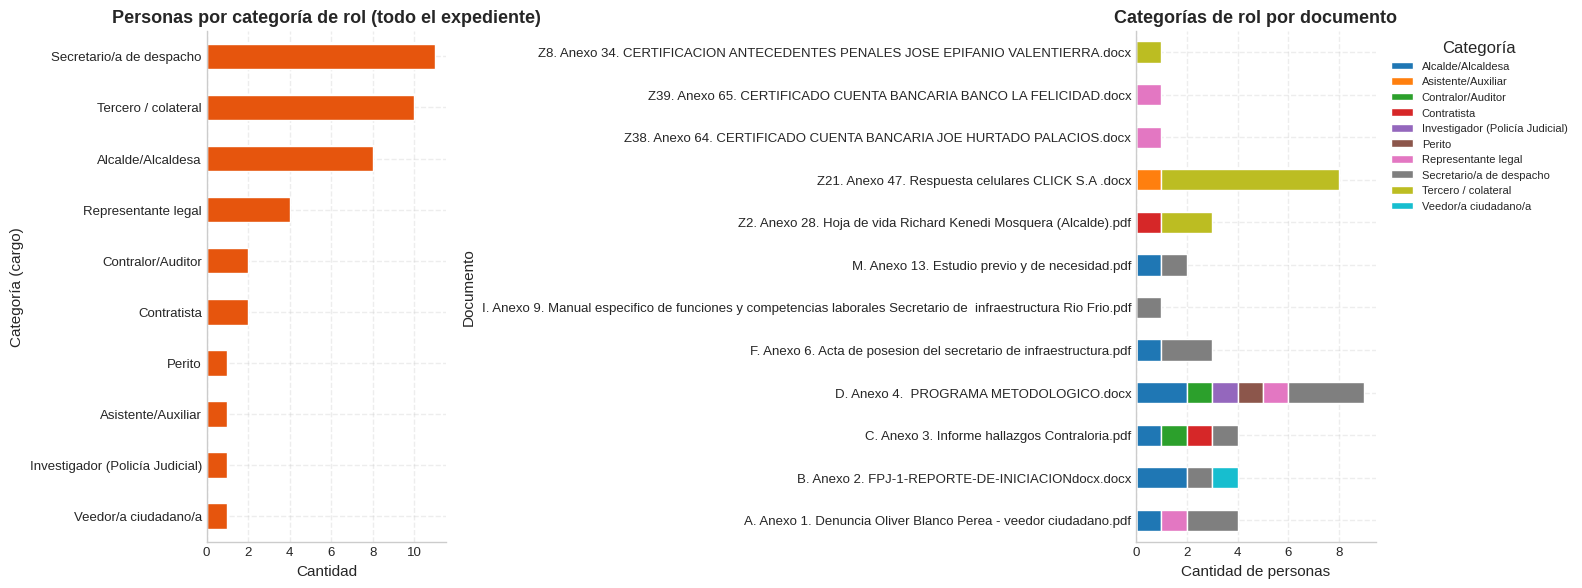

In [ ]:
if not df_sintesis_personas.empty:
    df_resumen_personas_final = df_resumen_personas.merge(
        df_sintesis_personas[["Documento", "Persona", "Categoría (cargo)", "Evidencia_regla", "Síntesis", "Estado"]],
        on=["Documento", "Persona"], how="left",
    )
else:
    df_resumen_personas_final = df_resumen_personas.copy()

print("Tabla final: qué se dice de cada persona, por documento, con categoría de rol procesal:")
mostrar_tabla(
    df_resumen_personas_final[["Documento", "Persona", "Categoría (cargo)", "Evidencia_regla", "Síntesis", "Estado"]],
    titulo="Qué se dice de cada persona (final)",
)

if not df_sintesis_personas.empty:
    conteo_categorias = df_sintesis_personas["Categoría (cargo)"].value_counts()
    print("\nDistribución de roles detectados en todo el expediente:")
    display(conteo_categorias.to_frame("Cantidad"))

    fig, ejes = plt.subplots(1, 2, figsize=(16, 6))

    conteo_categorias.sort_values().plot(kind="barh", ax=ejes[0], color="#e6550d")
    ejes[0].set_title("Personas por categoría de rol (todo el expediente)")
    ejes[0].set_xlabel("Cantidad")

    tabla_cat_doc = df_sintesis_personas.groupby(["Documento", "Categoría (cargo)"]).size().unstack(fill_value=0)
    tabla_cat_doc.plot(kind="barh", stacked=True, ax=ejes[1], colormap="tab10")
    ejes[1].set_title("Categorías de rol por documento")
    ejes[1].set_xlabel("Cantidad de personas")
    ejes[1].legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

    fig.tight_layout()
    plt.show()


## Paso 13.1 — Ficha narrativa por documento (lectura rápida)

Esta es la forma "profesional" de leer el resultado: por cada documento, qué persona aparece y
qué se dice de ella — en prosa, no en una tabla ancha. Si el LLM alcanzó a procesar ese
documento/persona, se usa su categoría + síntesis; si no (por ejemplo, si se acabaron los
créditos), se muestra la evidencia textual cruda como respaldo, para que ningún documento quede
sin lectura.

In [ ]:
print("=" * 90)
print("FICHA NARRATIVA POR DOCUMENTO")
print("=" * 90)

info_doc = {}
if "df_caracterizacion_documentos" in globals() and not df_caracterizacion_documentos.empty:
    info_doc = df_caracterizacion_documentos.set_index("Documento").to_dict("index")

for documento in df["archivo"]:
    print(f"\n📄 {documento}")

    datos_doc = info_doc.get(documento, {})
    tema = datos_doc.get("Tema central (LLM)", "")
    tipo_doc = datos_doc.get("Tipo de documento (LLM)", "")
    if tema:
        etiqueta_tipo = f" [{tipo_doc}]" if tipo_doc else ""
        print(f"   Tema central{etiqueta_tipo}: {tema}")
    elif not datos_doc.get("Términos clave (TF-IDF)", ""):
        pass
    else:
        print(f"   Términos clave: {datos_doc.get('Términos clave (TF-IDF)', '')}")

    personas_doc = (
        df_resumen_personas_final[df_resumen_personas_final["Documento"] == documento]
        if not df_resumen_personas_final.empty else pd.DataFrame()
    )

    if personas_doc.empty:
        print("   (No se detectaron personas en este documento.)")
        continue

    for _, fila in personas_doc.iterrows():
        categoria = fila.get("Categoría (cargo)", "") if "Categoría (cargo)" in fila else ""
        sintesis = fila.get("Síntesis", "") if "Síntesis" in fila else ""
        if sintesis:
            etiqueta = f" [{categoria}]" if categoria and categoria != "no determinado" else ""
            print(f"   • {fila['Persona']}{etiqueta}: {sintesis}")
        else:
            # Sin síntesis de LLM disponible todavía: se muestra la evidencia cruda como respaldo,
            # para que la tabla siga siendo útil aunque no hayas corrido (o se hayan agotado) los
            # pasos de LLM.
            evidencia = fila.get("Evidencias_textuales", "") if "Evidencias_textuales" in fila else ""
            primera_evidencia = evidencia.split(" | ")[0] if evidencia else "(sin evidencia registrada)"
            menciones = fila.get("Menciones", "?")
            print(f'   • {fila["Persona"]} — {menciones} mención(es). Ej.: "{primera_evidencia}"')


FICHA NARRATIVA POR DOCUMENTO

📄 Z8. Anexo 34. CERTIFICACION ANTECEDENTES PENALES JOSE EPIFANIO VALENTIERRA.docx
   Tema central [certificación]: Documento cuyos términos más frecuentes son: certificación (0.42), sistema (0.34), fecha (0.31), documento (0.27), identidad (0.24), jose (0.21), funcionario (0.21), policia (0.19). (menciona a José Epifanio Valentierra Asprilla; en relación con Sistema Académico)
   • José Epifanio Valentierra Asprilla [Tercero / colateral]: Según el documento: "CERTIFICACIÓN DE ANTECEDENTES PENALES
DOCUMENTO FICTICIO – USO ACADÉMICO
SIN VALIDEZ LEGAL
La POLICIA NACIONAL certifica que, revisados los registros penales, la persona identificada a continuación presenta la información que se relacion..."

📄 D. Anexo 4.  PROGRAMA METODOLOGICO.docx
   Tema central [documento (tipo no determinado por reglas)]: Documento cuyos términos más frecuentes son: delgado (0.35), cabezas (0.30), rosendo (0.30), lucumí (0.26), cabo (0.23), mena (0.23), rosa (0.23), mora (0.23)

## Paso 14 — Exportación final a Excel

In [ ]:
NOMBRE_EXCEL_FINAL = "analisis_forense_con_sintesis_HF.xlsx"

with pd.ExcelWriter(NOMBRE_EXCEL_FINAL, engine="openpyxl") as writer:
    df.drop(columns=["oraciones", "tokens"], errors="ignore").to_excel(
        writer, sheet_name="Documentos_Procesados", index=False)
    if not df_entidades.empty:
        df_entidades.to_excel(writer, sheet_name="Entidades_Detectadas", index=False)
    if not df_caracterizacion_documentos.empty:
        df_caracterizacion_documentos.to_excel(writer, sheet_name="Caracterizacion_Documentos", index=False)
    if not df_resumen_personas_final.empty:
        df_resumen_personas_final.to_excel(writer, sheet_name="Resumen_Personas", index=False)
    if not df_que_se_dice_personas.empty:
        df_que_se_dice_personas.to_excel(writer, sheet_name="Que_se_dice_Personas", index=False)
    if not df_sintesis_personas.empty:
        df_sintesis_personas.to_excel(writer, sheet_name="Sintesis_LLM_Personas", index=False)
    if "df_categoria_personas" in globals() and not df_categoria_personas.empty:
        df_categoria_personas.to_excel(writer, sheet_name="Cargo_Personas_x_Documento", index=False)
    if not df_explicacion_similitud.empty:
        df_explicacion_similitud.to_excel(writer, sheet_name="Explicacion_Similitud", index=False)

print("=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)
print("Archivo generado:", NOMBRE_EXCEL_FINAL)
if not df_sintesis_personas.empty:
    print("\nPersonas categorizadas:", len(df_sintesis_personas))
    print("Correctos:", (df_sintesis_personas["Estado"] == "OK").sum())
    print("Errores:", (df_sintesis_personas["Estado"] != "OK").sum())


PROCESO FINALIZADO
Archivo generado: analisis_forense_con_sintesis_HF.xlsx

Personas categorizadas: 41
Correctos: 0
Errores: 41


## Paso 15 — Dashboard HTML interactivo (para revisión no técnica)

Genera un único archivo `dashboard_analisis_forense.html`, autocontenido (sin dependencias
externas), con pestañas para navegar: fichas de documento desplegables al hacer clic, tabla de
personas y entidades con buscador y columnas ordenables al hacer clic en el encabezado, y los
gráficos principales incrustados como imágenes. Pensado para que un funcionario sin conocimientos
técnicos pueda abrirlo directamente en el navegador y explorar los resultados sin usar el
notebook.

In [ ]:
import io
import base64
import json as _json
import html as _html

def generar_sankey_svg(df_flujos, col_izq, col_der, col_valor, alto_base=560, top_n_izq=15,
                        max_chars_izq=34, max_chars_der=40):
    """Diagrama de Sankey de dos columnas (col_izq -> col_der), en SVG puro (sin librerías
    externas). Los márgenes y el ancho se calculan a partir del largo de las etiquetas (truncadas
    con '…' si son muy largas) para que el texto NUNCA quede cortado por el borde del SVG.
    Devuelve el string SVG listo para incrustar en HTML. Si no hay datos, devuelve un aviso."""
    if df_flujos is None or df_flujos.empty:
        return "<p><em>Sin datos suficientes para el diagrama de Sankey.</em></p>"

    def _truncar(texto, n):
        texto = str(texto)
        return texto if len(texto) <= n else texto[: n - 1].rstrip() + "…"

    df_f = df_flujos.copy()
    df_f[col_izq] = df_f[col_izq].astype(str).map(lambda t: _truncar(t, max_chars_izq))
    df_f[col_der] = df_f[col_der].astype(str).map(lambda t: _truncar(t, max_chars_der))
    df_f = df_f.groupby([col_izq, col_der], as_index=False)[col_valor].sum()

    totales_izq_completo = df_f.groupby(col_izq)[col_valor].sum().sort_values(ascending=False)
    izq_top = totales_izq_completo.head(top_n_izq).index.tolist()
    df_f = df_f[df_f[col_izq].isin(izq_top)]
    if df_f.empty:
        return "<p><em>Sin datos suficientes para el diagrama de Sankey.</em></p>"

    valores_izq = df_f.groupby(col_izq)[col_valor].sum().to_dict()
    valores_der = df_f.groupby(col_der)[col_valor].sum().to_dict()
    nodos_izq = sorted(valores_izq, key=lambda n: -valores_izq[n])
    nodos_der = sorted(valores_der, key=lambda n: -valores_der[n])

    # Márgenes calculados a partir del largo máximo de etiqueta en cada lado (≈6.2px por carácter
    # a font-size 11), con piso y techo razonables — así el texto nunca se sale del SVG.
    px_por_caracter = 6.2
    margen_izq = int(min(260, max(80, max((len(n) for n in nodos_izq), default=10) * px_por_caracter + 24)))
    margen_der = int(min(300, max(100, max((len(n) for n in nodos_der), default=10) * px_por_caracter + 34)))

    gap, ancho_nodo, margen_sup = 7, 14, 28
    alto = max(alto_base, 22 * max(len(nodos_izq), len(nodos_der)) + 2 * margen_sup)
    ancho = margen_izq + margen_der + 280
    alto_util = alto - 2 * margen_sup
    x_izq, x_der = margen_izq, ancho - margen_der - ancho_nodo

    def calcular_posiciones(nodos, valores):
        total = sum(valores[n] for n in nodos)
        alto_disponible = max(1, alto_util - gap * (len(nodos) - 1))
        y, posiciones = margen_sup, {}
        for n in nodos:
            h = max(5, alto_disponible * valores[n] / total) if total else 5
            posiciones[n] = (y, h)
            y += h + gap
        return posiciones

    pos_izq = calcular_posiciones(nodos_izq, valores_izq)
    pos_der = calcular_posiciones(nodos_der, valores_der)

    paleta = ["#2c3e50", "#2980b9", "#c0392b", "#27ae60", "#8e44ad", "#d35400", "#16a085", "#7f8c8d",
              "#c2185b", "#00838f", "#f39c12", "#5d4037", "#3949ab", "#00695c", "#ad1457", "#455a64"]
    color_grupo = {g: paleta[i % len(paleta)] for i, g in enumerate(nodos_der)}

    svg = [f'<svg viewBox="0 0 {ancho} {alto}" xmlns="http://www.w3.org/2000/svg" '
           f'style="width:100%;height:auto;font-family:-apple-system,Segoe UI,Roboto,Arial,sans-serif;">']

    cursor_izq = {n: pos_izq[n][0] for n in nodos_izq}
    cursor_der = {n: pos_der[n][0] for n in nodos_der}

    for _, fila in df_f.sort_values([col_izq, col_der]).iterrows():
        n_izq, n_der, valor = fila[col_izq], fila[col_der], fila[col_valor]
        h_izq_flujo = pos_izq[n_izq][1] * (valor / valores_izq[n_izq])
        h_der_flujo = pos_der[n_der][1] * (valor / valores_der[n_der])
        y0, y1 = cursor_izq[n_izq], cursor_der[n_der]
        cursor_izq[n_izq] += h_izq_flujo
        cursor_der[n_der] += h_der_flujo

        x0, x1 = x_izq + ancho_nodo, x_der
        xm = (x0 + x1) / 2
        color = color_grupo.get(n_der, "#95a5a6")
        d = (
            f"M {x0},{y0} C {xm},{y0} {xm},{y1} {x1},{y1} "
            f"L {x1},{y1 + h_der_flujo} C {xm},{y1 + h_der_flujo} {xm},{y0 + h_izq_flujo} {x0},{y0 + h_izq_flujo} Z"
        )
        svg.append(f'<path d="{d}" fill="{color}" opacity="0.42">'
                    f'<title>{n_izq} → {n_der}: {int(valor)}</title></path>')

    for n in nodos_izq:
        y, h = pos_izq[n]
        svg.append(f'<rect x="{x_izq}" y="{y:.1f}" width="{ancho_nodo}" height="{h:.1f}" fill="#34495e">'
                    f'<title>{n}: {int(valores_izq[n])}</title></rect>')
        svg.append(f'<text x="{x_izq - 6}" y="{y + h/2:.1f}" text-anchor="end" dominant-baseline="middle" '
                    f'font-size="11" fill="#1b2631">{n}</text>')

    for n in nodos_der:
        y, h = pos_der[n]
        color = color_grupo.get(n, "#95a5a6")
        svg.append(f'<rect x="{x_der}" y="{y:.1f}" width="{ancho_nodo}" height="{h:.1f}" fill="{color}">'
                    f'<title>{n}: {int(valores_der[n])}</title></rect>')
        svg.append(f'<text x="{x_der + ancho_nodo + 6}" y="{y + h/2:.1f}" text-anchor="start" '
                    f'dominant-baseline="middle" font-size="11" font-weight="700" fill="{color}">{n}</text>')

    svg.append("</svg>")
    return "\n".join(svg)


def _fig_a_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=115)
    buf.seek(0)
    codificado = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return codificado

def _escapar(valor):
    return _html.escape(str(valor)) if pd.notna(valor) else ""

def _tabla_html(df_tabla, id_tabla):
    if df_tabla is None or df_tabla.empty:
        return "<p><em>(sin datos disponibles)</em></p>"
    encabezados = "".join(
        f'<th onclick="ordenarTabla(\'{id_tabla}\', {i})">{_escapar(c)} ⇅</th>'
        for i, c in enumerate(df_tabla.columns)
    )
    filas = "".join(
        "<tr>" + "".join(f"<td>{_escapar(v)}</td>" for v in fila) + "</tr>"
        for fila in df_tabla.itertuples(index=False)
    )
    return f'''<input class="buscador" onkeyup="filtrarTabla(this, '{id_tabla}')" placeholder=" Buscar en esta tabla...">
<div class="tabla-scroll"><table id="{id_tabla}" class="tabla-datos"><thead><tr>{encabezados}</tr></thead><tbody>{filas}</tbody></table></div>'''

def _tarjeta(numero, etiqueta):
    return f'<div class="tarjeta"><div class="tarjeta-numero">{numero}</div><div class="tarjeta-etiqueta">{etiqueta}</div></div>'

COLOR_TIPO_ENTIDAD = {"PER": "#e74c3c", "ORG": "#2980b9", "LOC": "#27ae60", "FECHA": "#d35400"}

# --- Recolectar resultados ya calculados en el notebook (con respaldo si algún paso no se corrió) ---
_df_docs = globals().get("df_caracterizacion_documentos", globals().get("df_caracterizacion_base", pd.DataFrame()))
_df_gram = globals().get("df_perfil_gramatical", pd.DataFrame())
_df_top_ent = globals().get("top_entidades_global", pd.DataFrame())
_df_personas = globals().get("df_resumen_personas_final", globals().get("df_resumen_personas", pd.DataFrame()))
_df_sint = globals().get("df_sintesis_personas", pd.DataFrame())
_df_entidades = globals().get("df_entidades", pd.DataFrame())
_df_cronologia = globals().get("df_cronologia", pd.DataFrame())
_df_topicos_palabras = globals().get("df_topicos_palabras", pd.DataFrame())
_df_topico_dominante = globals().get("df_topico_dominante", pd.DataFrame())
_df_dist_topicos = globals().get("df_distribucion_topicos", pd.DataFrame())
_sim_embeddings = globals().get("sim_embeddings", None)
_df_base = globals().get("df", pd.DataFrame())
_df_categoria_personas = globals().get("df_categoria_personas", pd.DataFrame())
_df_persona_categoria = globals().get("df_persona_categoria", pd.DataFrame())
_sim_tfidf = globals().get("sim_tfidf", None)

def _construir_mapa_colores(categorias):
    """Asigna un color estable a cada categoría (orden alfabético, para que el mismo nombre de
    categoría siempre tenga el mismo color en todos los gráficos del dashboard)."""
    paleta = ["#2c3e50", "#2980b9", "#c0392b", "#27ae60", "#8e44ad", "#d35400", "#16a085",
              "#7f8c8d", "#c2185b", "#00838f", "#f39c12", "#5d4037", "#3949ab", "#00695c",
              "#ad1457", "#455a64", "#6d4c41", "#0277bd", "#558b2f", "#e64a19"]
    categorias_unicas = sorted(set(
        c for c in categorias if c not in (None, "", "Tercero / colateral", "no determinado")
    ))
    mapa = {c: paleta[i % len(paleta)] for i, c in enumerate(categorias_unicas)}
    mapa["Tercero / colateral"] = "#95a5a6"
    mapa["no determinado"] = "#95a5a6"
    return mapa

_categorias_para_colores = []
if not _df_sint.empty and "Categoría (cargo)" in _df_sint.columns:
    _categorias_para_colores += list(_df_sint["Categoría (cargo)"])
if not _df_persona_categoria.empty:
    _categorias_para_colores += list(_df_persona_categoria["Categoría (cargo)"])
COLOR_CATEGORIA = _construir_mapa_colores(_categorias_para_colores)

# ============================================================
# GRÁFICOS (se regeneran aquí para incrustarlos como imágenes)
# ============================================================
_graficos_generales_html = ""
_graficos_resumen_html = ""
_graficos_similitud_html = ""

if not _df_gram.empty:
    _cols_gram = [c for c in _df_gram.columns if c not in ("Documento", "Total palabras analizadas")]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(_df_gram))))
    _df_gram.set_index("Documento")[_cols_gram].plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
    ax.set_title("Composición gramatical por documento"); ax.set_xlabel("% de palabras")
    ax.legend(title="Categoría", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
    fig.tight_layout()
    _graficos_generales_html += f'<h3>Perfil gramatical</h3><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}">'

if not _df_top_ent.empty:
    _top20 = _df_top_ent.head(20).iloc[::-1]
    _colores = _top20["tipo"].map(COLOR_TIPO_ENTIDAD).fillna("#34495e")
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh(_top20["entidad_canonica"] + "  [" + _top20["tipo"] + "]", _top20["Menciones"], color=_colores)
    ax.set_title("Top 20 entidades más mencionadas"); ax.set_xlabel("N° de menciones")
    fig.tight_layout()
    _graficos_generales_html += f'<h3>Entidades más mencionadas</h3><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}">'

if not _df_sint.empty and "Categoría (cargo)" in _df_sint.columns:
    _conteo_cat = _df_sint["Categoría (cargo)"].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(_conteo_cat.index, _conteo_cat.values,
            color=[COLOR_CATEGORIA.get(c, "#34495e") for c in _conteo_cat.index])
    ax.set_title("Personas por cargo/calidad"); ax.set_xlabel("Cantidad")
    fig.tight_layout()
    _graficos_generales_html += f'<h3>Cargos / calidad de las personas</h3><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}">'

# Resumen general: entidades por tipo
if not _df_entidades.empty:
    _conteo_tipo = _df_entidades["tipo"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(_conteo_tipo.index, _conteo_tipo.values,
           color=[COLOR_TIPO_ENTIDAD.get(t, "#34495e") for t in _conteo_tipo.index])
    ax.set_title("Entidades detectadas por tipo"); ax.set_ylabel("Cantidad")
    fig.tight_layout()
    _graficos_resumen_html += f'<div class="col"><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}"></div>'

if not _df_sint.empty and "Categoría (cargo)" in _df_sint.columns:
    _conteo_cat2 = _df_sint["Categoría (cargo)"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.pie(_conteo_cat2.values, labels=_conteo_cat2.index, autopct="%1.0f%%", startangle=90,
           colors=[COLOR_CATEGORIA.get(c, "#34495e") for c in _conteo_cat2.index],
           textprops={"fontsize": 8})
    ax.set_title("Distribución de cargos/calidad")
    fig.tight_layout()
    _graficos_resumen_html += f'<div class="col"><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}"></div>'

# Similitud coseno entre documentos (heatmap) — TF-IDF y embeddings, una al lado de la otra
def _figura_similitud(matriz, titulo):
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    _nombres_cortos = [n[:24] + ("…" if len(n) > 24 else "") for n in _df_base["archivo"]]
    im = ax.imshow(matriz, cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_xticks(range(len(_nombres_cortos))); ax.set_xticklabels(_nombres_cortos, rotation=90, fontsize=7)
    ax.set_yticks(range(len(_nombres_cortos))); ax.set_yticklabels(_nombres_cortos, fontsize=7)
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if matriz[i, j] > 0.55 else "#2c3e50")
    ax.set_title(titulo, fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Similitud coseno")
    fig.tight_layout()
    return _fig_a_base64(fig)

if not _df_base.empty and (_sim_tfidf is not None or _sim_embeddings is not None):
    _graficos_similitud_html += '<h3>Matriz de similitud coseno entre documentos</h3><div class="fila-cols">'
    if _sim_tfidf is not None:
        _b64 = _figura_similitud(_sim_tfidf, "TF-IDF (coincidencia léxica)")
        _graficos_similitud_html += f'<div class="col"><img class="grafico" src="data:image/png;base64,{_b64}"></div>'
    else:
        _graficos_similitud_html += '<div class="col"><p><em>Similitud TF-IDF (Paso 5) no disponible.</em></p></div>'
    if _sim_embeddings is not None:
        _b64 = _figura_similitud(_sim_embeddings, "Embeddings (significado)")
        _graficos_similitud_html += f'<div class="col"><img class="grafico" src="data:image/png;base64,{_b64}"></div>'
    else:
        _graficos_similitud_html += '<div class="col"><p><em>Similitud por embeddings (Paso 5) no disponible.</em></p></div>'
    _graficos_similitud_html += '</div>'
else:
    _graficos_similitud_html += "<p><em>La matriz de similitud (Paso 5) no está disponible; corre esa celda antes de generar el dashboard.</em></p>"

# LDA: distribución de tópicos
if not _df_dist_topicos.empty:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(_df_dist_topicos))))
    _df_dist_topicos.plot(kind="barh", stacked=True, ax=ax,
                           color=["#2c3e50", "#2980b9", "#c0392b", "#27ae60", "#8e44ad"][:_df_dist_topicos.shape[1]])
    ax.set_title("Distribución de tópicos (LDA) por documento"); ax.set_xlabel("Peso del tópico")
    ax.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
    fig.tight_layout()
    _graficos_similitud_html += f'<h3>Distribución de tópicos (LDA)</h3><img class="grafico" src="data:image/png;base64,{_fig_a_base64(fig)}">'

# pyLDAvis: panel interactivo de tópicos (si el modelo LDA del Paso 3.2 está disponible)
_modelo_lda = globals().get("modelo_lda", None)
_matriz_conteo_lda = globals().get("matriz_conteo_lda", None)
_vectorizador_lda = globals().get("vectorizador_lda", None)

if _modelo_lda is not None and _matriz_conteo_lda is not None and _vectorizador_lda is not None:
    try:
        try:
            import pyLDAvis
            import pyLDAvis.lda_model
        except ImportError:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyLDAvis"], check=False)
            import pyLDAvis
            import pyLDAvis.lda_model
        # n_jobs=1: evita errores de multiprocessing (BrokenProcessPool) típicos en Colab.
        # sort_topics=False: conserva la misma numeración "Tópico 1, 2..." que el resto del dashboard.
        _panel_ldavis = pyLDAvis.lda_model.prepare(
            _modelo_lda, _matriz_conteo_lda, _vectorizador_lda, mds="pcoa", n_jobs=1, sort_topics=False,
        )
        _html_ldavis = pyLDAvis.prepared_data_to_html(_panel_ldavis).replace('"', "&quot;")
        _graficos_similitud_html += (
            '<h3>Panel interactivo de tópicos (pyLDAvis)</h3>'
            '<p style="font-size:12px;color:#566573;">Cada burbuja es un tópico (tamaño = prevalencia '
            'en el corpus); la distancia entre burbujas refleja qué tan distintos son entre sí. El '
            'control λ (abajo a la derecha del panel) ajusta si las palabras de la lista se ordenan por '
            'frecuencia global o por qué tan exclusivas son de ese tópico.</p>'
            f'<iframe class="ldavis-frame" srcdoc="{_html_ldavis}"></iframe>'
        )
    except Exception as _e_ldavis:
        _graficos_similitud_html += (
            f"<p><em>No se pudo generar el panel interactivo de pyLDAvis ({_e_ldavis}); "
            f"se conserva el gráfico estático de tópicos de arriba.</em></p>"
        )

# --- Fichas de documento (clic para expandir), con mini-gráfico de roles por documento ---
_fichas_html = ""
for _, _fila_doc in _df_docs.iterrows():
    _doc = _fila_doc.get("Documento", "")
    _tema = _fila_doc.get("Tema central (LLM)", "") or _fila_doc.get("Términos clave (TF-IDF)", "")
    _tipo = _fila_doc.get("Tipo de documento (LLM)", "")
    _personas_doc = _df_personas[_df_personas.get("Documento", pd.Series(dtype=str)) == _doc] \
        if not _df_personas.empty else pd.DataFrame()

    _mini_grafico = ""
    if not _personas_doc.empty and "Categoría (cargo)" in _personas_doc.columns:
        _conteo_roles_doc = _personas_doc["Categoría (cargo)"].fillna("no determinado").value_counts()
        if not _conteo_roles_doc.empty:
            fig, ax = plt.subplots(figsize=(4.2, max(1.6, 0.35 * len(_conteo_roles_doc))))
            ax.barh(_conteo_roles_doc.index, _conteo_roles_doc.values,
                    color=[COLOR_CATEGORIA.get(c, "#34495e") for c in _conteo_roles_doc.index])
            ax.set_title("Cargo/calidad en este documento", fontsize=10)
            fig.tight_layout()
            _mini_grafico = f'<img class="grafico-mini" src="data:image/png;base64,{_fig_a_base64(fig)}">'

    _badges_personas = ""
    for _, _fp in _personas_doc.iterrows():
        _cat = _fp.get("Categoría (cargo)", "") or ""
        _sint = _fp.get("Síntesis", "") or (_fp.get("Evidencias_textuales", "").split(" | ")[0] if _fp.get("Evidencias_textuales", "") else "")
        _color = COLOR_CATEGORIA.get(_cat, "#34495e")
        _badges_personas += f'''<div class="persona-item">
            <span class="badge" style="background:{_color}">{_escapar(_cat) or "sin categoría"}</span>
            <strong>{_escapar(_fp.get("Persona", ""))}</strong>
            <p>{_escapar(_sint)}</p></div>'''
    if not _badges_personas:
        _badges_personas = "<p><em>No se detectaron personas en este documento.</em></p>"

    _etiqueta_tipo = f' <span class="tipo-doc">{_escapar(_tipo)}</span>' if _tipo else ""
    _fichas_html += f'''<details class="ficha-doc">
        <summary>📄 {_escapar(_doc)}{_etiqueta_tipo}</summary>
        <div class="ficha-contenido">
            <div class="ficha-cols">
              <div class="ficha-texto">
                <p class="tema">{_escapar(_tema)}</p>
                <div class="stats-doc">
                    N° páginas: <strong>{_escapar(_fila_doc.get("N° páginas", "N/A"))}</strong> ·
                    N° palabras: <strong>{_escapar(_fila_doc.get("N° palabras", "N/A"))}</strong> ·
                    N° oraciones: <strong>{_escapar(_fila_doc.get("N° oraciones", "N/A"))}</strong>
                </div>
                <h4>Personas mencionadas</h4>
                {_badges_personas}
              </div>
              <div class="ficha-grafico">{_mini_grafico}</div>
            </div>
        </div></details>'''

# --- Cronología (clic para expandir cada hecho, ya viene ordenada) ---
_cronologia_html = ""
if not _df_cronologia.empty:
    for _, _fh in _df_cronologia.iterrows():
        _fecha_mostrar = _fh.get("Fecha (texto)", "") or _fh.get("Fecha (ISO)", "")
        _cronologia_html += f'''<div class="evento-cronologia">
            <div class="evento-fecha">{_escapar(_fecha_mostrar)}</div>
            <div class="evento-cuerpo"><strong>{_escapar(_fh.get("Documento", ""))}</strong>
            <p>{_escapar(_fh.get("Hecho", ""))}</p></div></div>'''
else:
    _cronologia_html = "<p><em>No se identificaron fechas explícitas en los documentos.</em></p>"

# --- Datos para el gráfico interactivo de Personas (JS, con botones) ---
_datos_personas_js = []
if not _df_personas.empty:
    for _, _fp in _df_personas.iterrows():
        _datos_personas_js.append({
            "persona": str(_fp.get("Persona", "")),
            "documento": str(_fp.get("Documento", "")),
            "categoria": str(_fp.get("Categoría (cargo)", "") or "no determinado"),
            "menciones": int(_fp.get("Menciones", 1) or 1),
        })
_DATOS_PERSONAS_JSON = _json.dumps(_datos_personas_js, ensure_ascii=False)
_COLOR_CATEGORIA_JSON = _json.dumps(COLOR_CATEGORIA, ensure_ascii=False)

# --- Tarjetas del resumen general ---
_n_docs = len(_df_docs)
_n_personas_unicas = _df_personas["Persona"].nunique() if not _df_personas.empty and "Persona" in _df_personas.columns else 0
_n_entidades_total = len(_df_entidades) if not _df_entidades.empty else 0
_n_hechos_fecha = len(_df_cronologia) if not _df_cronologia.empty else 0
_n_topicos = _df_topico_dominante["Tópico dominante"].nunique() if not _df_topico_dominante.empty else 0
_tarjetas_html = (
    _tarjeta(_n_docs, "Documentos analizados") + _tarjeta(_n_personas_unicas, "Personas identificadas") +
    _tarjeta(_n_entidades_total, "Entidades detectadas") + _tarjeta(_n_hechos_fecha, "Hechos con fecha") +
    (_tarjeta(_n_topicos, "Tópicos (LDA)") if _n_topicos else "")
)

# --- Diagrama de Sankey: persona -> cargo/calidad (Paso 8b) ---
_svg_sankey = generar_sankey_svg(_df_persona_categoria, "Persona", "Categoría (cargo)", "Frecuencia") \
    if not _df_persona_categoria.empty else "<p><em>No se detectaron categorías de personas (Paso 8b) todavía.</em></p>"

if not _df_persona_categoria.empty:
    _df_categorias_resumen = (
        _df_persona_categoria.groupby("Categoría (cargo)")
        .agg(**{"N° personas": ("Persona", "nunique"), "N° evidencias": ("Frecuencia", "sum")})
        .reset_index().sort_values("N° evidencias", ascending=False)
    )
else:
    _df_categorias_resumen = pd.DataFrame()

# ============================================================
# ENSAMBLADO DEL HTML FINAL
# ============================================================
_html_dashboard = f'''<!DOCTYPE html>
<html lang="es"><head><meta charset="UTF-8">
<title>Dashboard — Análisis forense lingüístico</title>
<style>
  body {{ font-family: -apple-system, Segoe UI, Roboto, Arial, sans-serif; margin: 0; background: #f4f6f7; color: #1b2631; }}
  header {{ background: #1b2631; color: white; padding: 20px 28px; }}
  header h1 {{ margin: 0; font-size: 22px; }}
  header p {{ margin: 4px 0 0; color: #bdc3c7; font-size: 13px; }}
  .tabs {{ display: flex; gap: 6px; padding: 14px 28px 0; background: #f4f6f7; position: sticky; top: 0; z-index: 5; flex-wrap: wrap; }}
  .tab-btn {{ border: none; background: #dfe4e6; padding: 10px 16px; border-radius: 8px 8px 0 0; cursor: pointer; font-size: 13px; font-weight: 600; color: #1b2631; }}
  .tab-btn.active {{ background: white; box-shadow: 0 -2px 6px rgba(0,0,0,0.06); }}
  .tab-content {{ display: none; background: white; padding: 22px 28px; margin: 0 20px 24px; border-radius: 0 8px 8px 8px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
  .tab-content.active {{ display: block; }}
  .buscador {{ width: 100%; max-width: 420px; padding: 8px 12px; margin-bottom: 12px; border: 1px solid #ccc; border-radius: 6px; font-size: 13px; }}
  .tabla-scroll {{ overflow-x: auto; }}
  .ldavis-frame {{ width: 100%; height: 800px; border: 1px solid #eee; border-radius: 8px; margin: 10px 0 26px; }}
  table.tabla-datos {{ border-collapse: collapse; width: 100%; font-size: 12.5px; }}
  table.tabla-datos th {{ background: #1b2631; color: white; padding: 8px 10px; text-align: left; cursor: pointer; white-space: nowrap; }}
  table.tabla-datos td {{ padding: 6px 10px; border-bottom: 1px solid #eee; vertical-align: top; }}
  table.tabla-datos tr:nth-child(even) {{ background: #f8f9f9; }}
  table.tabla-datos tr:hover {{ background: #eaf2f8; }}
  .ficha-doc {{ border: 1px solid #e0e0e0; border-radius: 8px; margin-bottom: 10px; padding: 10px 14px; }}
  .ficha-doc summary {{ cursor: pointer; font-weight: 700; font-size: 14.5px; }}
  .ficha-doc .tipo-doc {{ background: #eaf2f8; color: #2980b9; border-radius: 5px; padding: 2px 8px; font-size: 11.5px; margin-left: 8px; }}
  .ficha-contenido {{ margin-top: 10px; }}
  .ficha-cols {{ display: flex; gap: 18px; flex-wrap: wrap; }}
  .ficha-texto {{ flex: 2; min-width: 280px; }}
  .ficha-grafico {{ flex: 1; min-width: 200px; }}
  .grafico-mini {{ max-width: 100%; border: 1px solid #eee; border-radius: 6px; }}
  .tema {{ color: #34495e; font-style: italic; }}
  .stats-doc {{ font-size: 12.5px; color: #566573; margin: 8px 0 14px; }}
  .persona-item {{ border-left: 3px solid #ddd; padding: 6px 0 6px 12px; margin-bottom: 8px; }}
  .persona-item p {{ margin: 3px 0 0; font-size: 12.5px; color: #333; }}
  .badge {{ color: white; border-radius: 5px; padding: 2px 8px; font-size: 11px; font-weight: 600; margin-right: 8px; }}
  .grafico {{ max-width: 100%; display: block; margin: 10px 0 26px; border: 1px solid #eee; border-radius: 8px; }}
  .fila-cols {{ display: flex; gap: 18px; flex-wrap: wrap; }}
  .fila-cols .col {{ flex: 1; min-width: 280px; }}
  .tarjetas {{ display: flex; gap: 14px; flex-wrap: wrap; margin: 4px 0 24px; }}
  .tarjeta {{ background: #1b2631; color: white; border-radius: 10px; padding: 16px 22px; min-width: 140px; text-align: center; }}
  .tarjeta-numero {{ font-size: 26px; font-weight: 800; }}
  .tarjeta-etiqueta {{ font-size: 11.5px; color: #bdc3c7; margin-top: 4px; }}
  .evento-cronologia {{ display: flex; gap: 14px; border-left: 3px solid #d35400; padding: 6px 0 12px 14px; margin-bottom: 6px; }}
  .evento-fecha {{ min-width: 130px; font-weight: 700; color: #d35400; font-size: 12.5px; }}
  .evento-cuerpo p {{ margin: 3px 0 0; font-size: 12.5px; color: #333; }}
  .selector-dim {{ display: flex; gap: 8px; margin-bottom: 14px; }}
  .btn-dim {{ border: 1px solid #ccc; background: #f4f6f7; padding: 7px 14px; border-radius: 20px; cursor: pointer; font-size: 12.5px; font-weight: 600; }}
  .btn-dim.active {{ background: #1b2631; color: white; border-color: #1b2631; }}
  .barra-fila {{ display: flex; align-items: center; gap: 10px; margin-bottom: 7px; }}
  .barra-etiqueta {{ width: 220px; font-size: 12px; text-align: right; flex-shrink: 0; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; }}
  .barra-pista {{ flex: 1; background: #eee; border-radius: 4px; overflow: hidden; height: 20px; }}
  .barra-valor {{ background: #2980b9; color: white; font-size: 11px; padding: 2px 6px; height: 100%; box-sizing: border-box; white-space: nowrap; }}
</style></head>
<body>
<header>
  <h1>📊 Dashboard — Análisis forense lingüístico</h1>
  <p>Generado automáticamente a partir del notebook</p>
</header>
<div class="tabs">
  <button class="tab-btn active" onclick="mostrarTab(event, 'tab-resumen')"> Resumen</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-docs')"> Documentos</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-personas')"> Personas</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-entidades')"> Entidades</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-cronologia')"> Cronología</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-similitud')"> Similitud &amp; Tópicos</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-sankey')"> Sankey</button>
  <button class="tab-btn" onclick="mostrarTab(event, 'tab-graficos')"> Gráficos</button>
</div>

<div id="tab-resumen" class="tab-content active">
  <h2>Resumen general del expediente</h2>
  <div class="tarjetas">{_tarjetas_html}</div>
  <div class="fila-cols">{_graficos_resumen_html or "<p><em>Sin datos suficientes todavía.</em></p>"}</div>
</div>

<div id="tab-docs" class="tab-content">
  <h2>Ficha por documento (clic para expandir)</h2>
  {_fichas_html or "<p><em>Sin documentos procesados todavía.</em></p>"}
</div>

<div id="tab-personas" class="tab-content">
  <h2>Frecuencia de menciones — por persona, documento o categoría</h2>
  <div class="selector-dim">
    <button class="btn-dim active" data-campo="persona" onclick="cambiarDimension(this)">Por persona</button>
    <button class="btn-dim" data-campo="documento" onclick="cambiarDimension(this)">Por documento</button>
    <button class="btn-dim" data-campo="categoria" onclick="cambiarDimension(this)">Por categoría</button>
  </div>
  <div id="grafico-personas-interactivo"></div>
  <h3 style="margin-top:28px;">Tabla detallada</h3>
  {_tabla_html(_df_personas, "tabla-personas")}
</div>

<div id="tab-entidades" class="tab-content">
  <h2>Menciones por entidad (todo el expediente, tras el filtro de calidad)</h2>
  {_tabla_html(_df_top_ent.rename(columns={"tipo": "Tipo", "entidad_canonica": "Entidad"}) if not _df_top_ent.empty else _df_top_ent, "tabla-entidades")}
</div>

<div id="tab-cronologia" class="tab-content">
  <h2>Cronología de hechos</h2>
  <p style="font-size:12.5px;color:#566573;">Fechas detectadas en el texto, asociadas a la oración (hecho) donde aparecen, ordenadas cronológicamente.</p>
  {_cronologia_html}
</div>

<div id="tab-similitud" class="tab-content">
  <h2>Similitud entre documentos y tópicos semánticos</h2>
  {_graficos_similitud_html}
  {_tabla_html(_df_topicos_palabras, "tabla-topicos") if not _df_topicos_palabras.empty else ""}
</div>

<div id="tab-sankey" class="tab-content">
  <h2>De persona a cargo / calidad</h2>
  <p style="font-size:12.5px;color:#566573;">
    Categorías detectadas automáticamente por patrones de texto (Paso 8b): cargos y calidades
    mencionados cerca del nombre de cada persona en los documentos — no se eligieron a mano para
    este caso; el diccionario de patrones es genérico y sirve igual para cualquier expediente. Si
    una persona no tiene ningún cargo mencionado cerca de su nombre en un documento, queda como
    "Tercero / colateral" en ese documento (no se le inventa un rol). Pasa el mouse sobre el
    diagrama para ver los valores exactos de cada flujo.
  </p>
  <div class="fila-cols">
    <div class="col" style="flex:2;min-width:420px;">{_svg_sankey}</div>
    <div class="col" style="flex:1;min-width:260px;">{_tabla_html(_df_categorias_resumen, "tabla-categorias-cargo")}</div>
  </div>
</div>

<div id="tab-graficos" class="tab-content">
  <h2>Gráficos del análisis</h2>
  {_graficos_generales_html or "<p><em>Sin gráficos disponibles todavía.</em></p>"}
</div>

<script>
const datosPersonas = {_DATOS_PERSONAS_JSON};
const colorCategoria = {_COLOR_CATEGORIA_JSON};

function mostrarTab(evento, idTab) {{
  document.querySelectorAll('.tab-content').forEach(el => el.classList.remove('active'));
  document.querySelectorAll('.tab-btn').forEach(el => el.classList.remove('active'));
  document.getElementById(idTab).classList.add('active');
  evento.currentTarget.classList.add('active');
}}
function filtrarTabla(input, idTabla) {{
  const filtro = input.value.toLowerCase();
  document.querySelectorAll('#' + idTabla + ' tbody tr').forEach(fila => {{
    fila.style.display = fila.textContent.toLowerCase().includes(filtro) ? '' : 'none';
  }});
}}
function ordenarTabla(idTabla, indiceCol) {{
  const tabla = document.getElementById(idTabla);
  const tbody = tabla.querySelector('tbody');
  const filas = Array.from(tbody.querySelectorAll('tr'));
  const asc = tabla.getAttribute('data-orden-col') != indiceCol || tabla.getAttribute('data-orden-dir') !== 'asc';
  filas.sort((a, b) => {{
    const va = a.children[indiceCol].textContent.trim();
    const vb = b.children[indiceCol].textContent.trim();
    const na = parseFloat(va.replace(',', '.')), nb = parseFloat(vb.replace(',', '.'));
    const cmp = (!isNaN(na) && !isNaN(nb)) ? na - nb : va.localeCompare(vb, 'es');
    return asc ? cmp : -cmp;
  }});
  filas.forEach(f => tbody.appendChild(f));
  tabla.setAttribute('data-orden-col', indiceCol);
  tabla.setAttribute('data-orden-dir', asc ? 'asc' : 'desc');
}}

// --- Gráfico interactivo de Personas (con botones: persona / documento / categoría) ---
function agregarPersonas(campo) {{
  const mapa = {{}};
  const categoriaPredominante = {{}};
  datosPersonas.forEach(d => {{
    const clave = d[campo];
    mapa[clave] = (mapa[clave] || 0) + d.menciones;
    categoriaPredominante[clave] = categoriaPredominante[clave] || d.categoria;
  }});
  return Object.entries(mapa).sort((a, b) => b[1] - a[1]).slice(0, 15)
    .map(([nombre, valor]) => ({{ nombre, valor, categoria: categoriaPredominante[nombre] }}));
}}
function dibujarBarrasPersonas(campo) {{
  const datos = agregarPersonas(campo);
  const maximo = Math.max(...datos.map(d => d.valor), 1);
  const contenedor = document.getElementById('grafico-personas-interactivo');
  if (datos.length === 0) {{ contenedor.innerHTML = '<p><em>Sin datos disponibles.</em></p>'; return; }}
  contenedor.innerHTML = datos.map(d => {{
    const color = campo === 'categoria' ? (colorCategoria[d.nombre] || '#2980b9') : (colorCategoria[d.categoria] || '#2980b9');
    return `<div class="barra-fila">
      <span class="barra-etiqueta" title="${{d.nombre}}">${{d.nombre}}</span>
      <div class="barra-pista"><div class="barra-valor" style="width:${{(d.valor / maximo * 100)}}%; background:${{color}}">${{d.valor}}</div></div>
    </div>`;
  }}).join('');
}}
function cambiarDimension(boton) {{
  document.querySelectorAll('.btn-dim').forEach(b => b.classList.remove('active'));
  boton.classList.add('active');
  dibujarBarrasPersonas(boton.dataset.campo);
}}
dibujarBarrasPersonas('persona');
</script>
</body></html>'''

RUTA_DASHBOARD = "dashboard_analisis_forense.html"
with open(RUTA_DASHBOARD, "w", encoding="utf-8") as _f:
    _f.write(_html_dashboard)

print(f"Dashboard generado: {RUTA_DASHBOARD}")
print("Ábrelo con doble clic (o descárgalo desde el panel de archivos de Colab) para navegarlo en el navegador.")

try:
    from google.colab import files as _colab_files
    _colab_files.download(RUTA_DASHBOARD)
except Exception:
    pass


Dashboard generado: dashboard_analisis_forense.html
Ábrelo con doble clic (o descárgalo desde el panel de archivos de Colab) para navegarlo en el navegador.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag